In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [234]:
df = pd.read_csv('Ball_By_Ball_Match_Data.csv')

In [235]:
df_details = pd.read_csv('player_details_final.csv')

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   ID                278205 non-null  int64 
 1   Innings           278205 non-null  int64 
 2   Overs             278205 non-null  int64 
 3   BallNumber        278205 non-null  int64 
 4   Batter            278205 non-null  object
 5   Bowler            278205 non-null  object
 6   NonStriker        278205 non-null  object
 7   ExtraType         15133 non-null   object
 8   BatsmanRun        278205 non-null  int64 
 9   ExtrasRun         278205 non-null  int64 
 10  TotalRun          278205 non-null  int64 
 11  IsWicketDelivery  278205 non-null  int64 
 12  PlayerOut         13823 non-null   object
 13  Kind              13823 non-null   object
 14  FieldersInvolved  10013 non-null   object
 15  BattingTeam       278205 non-null  object
dtypes: int64(8), object(8)
memory usage: 3

In [237]:
df_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_name  767 non-null    object
 1   name         767 non-null    object
 2   bat_style    767 non-null    object
 3   bowl_style   762 non-null    object
dtypes: object(4)
memory usage: 24.1+ KB


In [238]:
num_cols = [
    'ID', 'Innings', 'Overs', 'BallNumber',
    'BatsmanRun', 'ExtrasRun', 'TotalRun',
    'IsWicketDelivery'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['IsWicketDelivery'] = df['IsWicketDelivery'].fillna(0).astype(int)


In [239]:
required_cols = ['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler', 'BattingTeam']
df = df.dropna(subset=required_cols).reset_index(drop=True)


In [240]:
df = df.sort_values(
    by=['ID', 'Innings', 'Overs', 'BallNumber']
).reset_index(drop=True)


In [241]:
# Normalize extra type
df['ExtraType_norm'] = df['ExtraType'].astype(str).str.lower()

# Legal ball = NOT wide and NOT no-ball
df['is_legal_ball'] = ~df['ExtraType_norm'].isin(
    ['wides', 'wide', 'noballs', 'no balls', 'no-ball', 'no ball']
)


In [242]:
df['balls_completed'] = (
    df.groupby(['ID', 'Innings'])['is_legal_ball']
      .cumsum()
)


In [243]:
df['balls_remaining'] = 120 - df['balls_completed']
df['balls_remaining'] = df['balls_remaining'].clip(lower=0)

df['overs_completed'] = df['balls_completed'] / 6
df['overs_remaining'] = df['balls_remaining'] / 6


In [244]:
df['current_score'] = (
    df.groupby(['ID', 'Innings'])['TotalRun']
      .cumsum()
)

df['wickets_fallen'] = (
    df.groupby(['ID', 'Innings'])['IsWicketDelivery']
      .cumsum()
).clip(upper=10)


In [245]:
df['current_run_rate'] = (
    df['current_score'] / df['overs_completed']
).replace([np.inf, -np.inf], 0).fillna(0)


In [246]:
# Get first innings final score
first_innings_target = (
    df[df['Innings'] == 1]
    .groupby('ID')['current_score']
    .max()
    .reset_index()
    .rename(columns={'current_score': 'target'})
)

df = df.merge(first_innings_target, on='ID', how='left')

df['runs_needed'] = np.where(
    df['Innings'] == 2,
    df['target'] - df['current_score'],
    0
)

df['required_run_rate'] = np.where(
    df['Innings'] == 2,
    df['runs_needed'] / df['overs_remaining'].replace(0, np.nan),
    0
)

df['required_run_rate'] = df['required_run_rate'].fillna(0)


In [247]:
# ══════════════════════════════════════════════
# GLOBAL CONSTANTS (single source of truth)
# ══════════════════════════════════════════════
POWERPLAY_END = 6      # overs 0-5
MIDDLE_END    = 15     # overs 6-14
TOTAL_OVERS   = 20
MAX_BOWLER_OVERS = 4
TOTAL_BALLS   = TOTAL_OVERS * 6  # 120
PAR_RR        = 8.0    # typical T20 par run rate
BAYESIAN_PRIOR_K = 30  # Bayesian smoothing prior weight (balls)
BOWL_SR_SENTINEL = 999 # sentinel for "no wickets" bowling SR/avg
BOWL_SR_CAP      = 200 # cap bowling SR to avoid inf domination
ENSEMBLE_WEIGHTS = (0.50, 0.30, 0.20)  # matchup, extended, full


def get_phase(over):
    if over < POWERPLAY_END:
        return 'powerplay'
    elif over < MIDDLE_END:
        return 'middle'
    else:
        return 'death'

df['phase'] = df['Overs'].apply(get_phase)


In [248]:
# PAR_RR defined in constants cell above

df['pressure_index'] = np.where(
    df['Innings'] == 2,
    (df['required_run_rate'] / df['current_run_rate'].replace(0, 1)) * (df['wickets_fallen'] + 1),
    (PAR_RR / df['current_run_rate'].replace(0, 1)) * (df['wickets_fallen'] + 1)
)

df['pressure_index'] = df['pressure_index'].replace([np.inf, -np.inf], 0)

In [249]:
def pressure_bucket(p):
    if p < 1:
        return 'low'
    elif p < 2:
        return 'medium'
    else:
        return 'high'

df['pressure_bucket'] = df['pressure_index'].apply(pressure_bucket)


In [250]:
df[
    (df['ID'] == df['ID'].iloc[0]) &
    (df['Innings'] == 1)
][['Overs', 'BallNumber', 'ExtraType', 'is_legal_ball', 'balls_completed']].head(20)


,Overs,BallNumber,ExtraType,is_legal_ball,balls_completed
0,0,1,legbyes,True,1
1,0,2,NaN,True,2
2,0,3,wides,False,2
3,0,4,NaN,True,3
4,0,5,NaN,True,4
5,0,6,NaN,True,5
6,0,7,legbyes,True,6
7,1,1,NaN,True,7
8,1,2,NaN,True,8
9,1,3,NaN,True,9


In [251]:
# First legal ball of every over
over_start_events = df[
    (df['is_legal_ball']) &
    (df.groupby(['ID', 'Innings', 'Overs'])['balls_completed']
       .transform('min') == df['balls_completed'])
].copy()


In [252]:
# Compute bowler overs used correctly (legal balls only)
df_legal = df[df['is_legal_ball']].copy()

bowler_over_counts = (
    df_legal.groupby(['ID', 'Innings', 'Bowler', 'Overs'])
    .size()
    .reset_index(name='balls_in_over')
)

bowler_over_counts['bowler_overs_used'] = (
    bowler_over_counts
    .groupby(['ID', 'Innings', 'Bowler'])
    .cumcount()
)

over_start_events = over_start_events.merge(
    bowler_over_counts[['ID', 'Innings', 'Bowler', 'Overs', 'bowler_overs_used']],
    on=['ID', 'Innings', 'Bowler', 'Overs'],
    how='left'
)

over_start_events['bowler_overs_used'] = (
    over_start_events['bowler_overs_used']
    .fillna(0)
    .astype(int)
)


In [253]:
over_start_events[['Bowler', 'Overs', 'bowler_overs_used']].head(10)


,Bowler,Overs,bowler_overs_used
0,P Kumar,0,0
1,Z Khan,1,0
2,P Kumar,2,1
3,P Kumar,4,2
4,Z Khan,5,1
5,AA Noffke,6,1
6,Z Khan,7,2
7,JH Kallis,8,0
8,SB Joshi,9,0
9,JH Kallis,10,1


In [254]:
over_start_events['bowler_overs_used'] = (
    over_start_events['bowler_overs_used'].fillna(0).astype(int)
)


In [255]:
def normalize_name(x):
    if isinstance(x, str):
        return x.strip().lower()
    return x

df['batter_norm'] = df['Batter'].apply(normalize_name)
df['bowler_norm'] = df['Bowler'].apply(normalize_name)

df_details['unique_name_norm'] = df_details['unique_name'].apply(normalize_name)
df_details['name_norm'] = df_details['name'].apply(normalize_name)


In [256]:
# Batting handedness
df_details['bat_hand'] = df_details['bat_style'].str.lower().map(
    lambda x: 'left' if isinstance(x, str) and 'left' in x else
              'right' if isinstance(x, str) else 'unknown'
)

# Bowler type (spin / pace)
df_details['bowl_type'] = df_details['bowl_style'].str.lower().map(
    lambda x: 'spin' if isinstance(x, str) and 'spin' in x else
              'pace' if isinstance(x, str) else 'unknown'
)

# Bowler handedness
df_details['bowl_hand'] = df_details['bowl_style'].str.lower().map(
    lambda x: 'left' if isinstance(x, str) and 'left' in x else
              'right' if isinstance(x, str) else 'unknown'
)


In [257]:
df_details[['bat_style', 'bat_hand', 'bowl_style', 'bowl_type', 'bowl_hand']].head()


,bat_style,bat_hand,bowl_style,bowl_type,bowl_hand
0,Left hand Bat,left,Right arm Medium,pace,right
1,Right hand Bat,right,Right arm Fast medium,pace,right
2,Right hand Bat,right,Left arm Medium,pace,left
3,Right hand Bat,right,Right arm Medium,pace,right
4,Right hand Bat,right,Right arm Medium,pace,right


In [258]:
df = df.merge(
    df_details[['unique_name_norm', 'bat_hand']],
    left_on='batter_norm',
    right_on='unique_name_norm',
    how='left'
).drop(columns=['unique_name_norm'])


In [259]:
df = df.merge(
    df_details[['unique_name_norm', 'bowl_type', 'bowl_hand']],
    left_on='bowler_norm',
    right_on='unique_name_norm',
    how='left'
).drop(columns=['unique_name_norm'])


In [260]:
df[['bat_hand', 'bowl_type', 'bowl_hand']] = df[
    ['bat_hand', 'bowl_type', 'bowl_hand']
].fillna('unknown')


In [261]:
print(df.columns)


Index(['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler',
       'NonStriker', 'ExtraType', 'BatsmanRun', 'ExtrasRun', 'TotalRun',
       'IsWicketDelivery', 'PlayerOut', 'Kind', 'FieldersInvolved',
       'BattingTeam', 'ExtraType_norm', 'is_legal_ball', 'balls_completed',
       'balls_remaining', 'overs_completed', 'overs_remaining',
       'current_score', 'wickets_fallen', 'current_run_rate', 'target',
       'runs_needed', 'required_run_rate', 'phase', 'pressure_index',
       'pressure_bucket', 'batter_norm', 'bowler_norm', 'bat_hand',
       'bowl_type', 'bowl_hand'],
      dtype='object')


In [262]:
# rebuild over_start_events AFTER player attributes are merged

over_start_events = df[
    (df['is_legal_ball']) &
    (
        df.groupby(['ID', 'Innings', 'Overs'])['balls_completed']
          .transform('min') == df['balls_completed']
    )
].copy()

required_cols = ['bat_hand', 'bowl_type', 'bowl_hand']
print("Missing columns:",
      [c for c in required_cols if c not in over_start_events.columns])

over_start_events.head()


Missing columns: []


,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,...,runs_needed,required_run_rate,phase,pressure_index,pressure_bucket,batter_norm,bowler_norm,bat_hand,bowl_type,bowl_hand
0,335982,1,0,1,SC Ganguly,P Kumar,BB McCullum,legbyes,0,1,...,0,0.0,powerplay,1.333333,medium,sc ganguly,p kumar,left,pace,right
7,335982,1,1,1,BB McCullum,Z Khan,SC Ganguly,NaN,0,0,...,0,0.0,powerplay,3.111111,high,bb mccullum,z khan,right,pace,left
13,335982,1,2,1,SC Ganguly,P Kumar,BB McCullum,NaN,0,0,...,0,0.0,powerplay,0.825397,low,sc ganguly,p kumar,left,pace,right
26,335982,1,4,1,SC Ganguly,P Kumar,BB McCullum,NaN,4,0,...,0,0.0,powerplay,0.617284,low,sc ganguly,p kumar,left,pace,right
32,335982,1,5,1,BB McCullum,Z Khan,SC Ganguly,NaN,1,0,...,0,0.0,powerplay,0.677596,low,bb mccullum,z khan,right,pace,left


In [263]:
# merge: bowler_overs_used into over_start_events

df_legal = df[df['is_legal_ball']].copy()

bowler_over_counts = (
    df_legal
    .groupby(['ID', 'Innings', 'Bowler', 'Overs'])
    .size()
    .reset_index(name='balls_in_over')
)

bowler_over_counts['bowler_overs_used'] = (
    bowler_over_counts
    .groupby(['ID', 'Innings', 'Bowler'])
    .cumcount()
)

over_start_events = over_start_events.merge(
    bowler_over_counts[['ID', 'Innings', 'Bowler', 'Overs', 'bowler_overs_used']],
    on=['ID', 'Innings', 'Bowler', 'Overs'],
    how='left'
)

over_start_events['bowler_overs_used'] = (
    over_start_events['bowler_overs_used']
    .fillna(0)
    .astype(int)
)

assert 'bowler_overs_used' in over_start_events.columns

over_start_events[['Bowler', 'Overs', 'bowler_overs_used']].head()


,Bowler,Overs,bowler_overs_used
0,P Kumar,0,0
1,Z Khan,1,0
2,P Kumar,2,1
3,P Kumar,4,2
4,Z Khan,5,1


In [264]:
# Build bowling decision events table

bowling_events = over_start_events[[
    'ID',
    'Innings',
    'Overs',

    # Action (historical captain choice)
    'Bowler',

    # Constraint info (for action masking later)
    'bowler_overs_used',

    # Match situation
    'current_score',
    'wickets_fallen',
    'balls_remaining',
    'overs_remaining',
    'current_run_rate',
    'runs_needed',
    'required_run_rate',

    # Context
    'phase',
    'pressure_index',

    # Current batting pair (matchup context)
    'Batter',
    'NonStriker',

    # Player attributes
    'bat_hand',
    'bowl_type',
    'bowl_hand'
]].reset_index(drop=True)

print("Total bowling decision events:", len(bowling_events))
bowling_events.head()


Total bowling decision events: 43170


,ID,Innings,Overs,Bowler,bowler_overs_used,current_score,wickets_fallen,balls_remaining,overs_remaining,current_run_rate,runs_needed,required_run_rate,phase,pressure_index,Batter,NonStriker,bat_hand,bowl_type,bowl_hand
0,335982,1,0,P Kumar,0,1,0,119,19.833333,6.000000,0,0.0,powerplay,1.333333,SC Ganguly,BB McCullum,left,pace,right
1,335982,1,1,Z Khan,0,3,0,113,18.833333,2.571429,0,0.0,powerplay,3.111111,BB McCullum,SC Ganguly,right,pace,left
2,335982,1,2,P Kumar,1,21,0,107,17.833333,9.692308,0,0.0,powerplay,0.825397,SC Ganguly,BB McCullum,left,pace,right
3,335982,1,4,P Kumar,2,54,0,95,15.833333,12.960000,0,0.0,powerplay,0.617284,SC Ganguly,BB McCullum,left,pace,right
4,335982,1,5,Z Khan,1,61,0,89,14.833333,11.806452,0,0.0,powerplay,0.677596,BB McCullum,SC Ganguly,right,pace,left


In [265]:
# DEFINE batting_xi

batting_xi = (
    df.groupby(['ID', 'Innings'])[['Batter', 'NonStriker']]
      .agg(lambda x: set(x))
      .reset_index()
)

batting_xi['batting_xi'] = batting_xi.apply(
    lambda r: set(r['Batter']).union(set(r['NonStriker'])),
    axis=1
)

batting_xi.head()


,ID,Innings,Batter,NonStriker,batting_xi
0,335982,1,"{RT Ponting, Mohammad Hafeez, BB McCullum, SC ...","{RT Ponting, Mohammad Hafeez, BB McCullum, SC ...","{RT Ponting, Mohammad Hafeez, BB McCullum, SC ..."
1,335982,2,"{CL White, V Kohli, B Akhil, R Dravid, P Kumar...","{CL White, V Kohli, B Akhil, R Dravid, P Kumar...","{R Dravid, P Kumar, MV Boucher, W Jaffer, SB J..."
2,335983,1,"{JDP Oram, PA Patel, MEK Hussey, ML Hayden, SK...","{JDP Oram, PA Patel, MEK Hussey, ML Hayden, SK...","{JDP Oram, MEK Hussey, PA Patel, ML Hayden, SK..."
3,335983,2,"{Yuvraj Singh, IK Pathan, JR Hopes, SM Katich,...","{Yuvraj Singh, IK Pathan, JR Hopes, SM Katich,...","{Yuvraj Singh, IK Pathan, JR Hopes, SM Katich,..."
4,335984,1,"{T Kohli, M Rawat, RA Jadeja, M Kaif, YK Patha...","{T Kohli, M Rawat, RA Jadeja, M Kaif, YK Patha...","{T Kohli, M Rawat, RA Jadeja, M Kaif, YK Patha..."


In [266]:
# CREATE wicket_events

wicket_events = df[df['IsWicketDelivery'] == 1].copy()

print("wicket_events created:", wicket_events.shape)


wicket_events created: (13823, 36)


In [267]:
# add remaining_batters to current wicket_events

def get_remaining_batters(row):
    match_id = row['ID']
    innings = row['Innings']
    row_idx = row.name

    # Batting XI for this innings
    xi = batting_xi[
        (batting_xi['ID'] == match_id) &
        (batting_xi['Innings'] == innings)
    ]['batting_xi'].values[0]

    # Players already out BEFORE this ball
    out_so_far = set(
        df.loc[:row_idx]
          .query('ID == @match_id and Innings == @innings and IsWicketDelivery == 1')
          ['PlayerOut']
          .dropna()
          .values
    )

    # Players currently batting
    currently_in = {row['Batter'], row['NonStriker']}

    # Remaining available batters
    return list(xi - out_so_far - currently_in)

wicket_events['remaining_batters'] = wicket_events.apply(
    get_remaining_batters, axis=1
)

print("remaining_batters exists:",
      'remaining_batters' in wicket_events.columns)

wicket_events[['PlayerOut', 'remaining_batters']].head()


remaining_batters exists: True


,PlayerOut,remaining_batters
33,SC Ganguly,"[RT Ponting, Mohammad Hafeez, DJ Hussey]"
74,RT Ponting,"[Mohammad Hafeez, DJ Hussey]"
106,DJ Hussey,[Mohammad Hafeez]
131,R Dravid,"[CL White, V Kohli, B Akhil, P Kumar, AA Noffk..."
138,V Kohli,"[CL White, B Akhil, P Kumar, AA Noffke, MV Bou..."


In [268]:
# CREATE next_batter for each wicket event

def find_next_batter(row):
    match_id = row['ID']
    innings = row['Innings']
    over = row['Overs']
    ball = row['BallNumber']

    future = df[
        (df['ID'] == match_id) &
        (df['Innings'] == innings) &
        (
            (df['Overs'] > over) |
            ((df['Overs'] == over) & (df['BallNumber'] > ball))
        )
    ]

    for _, r in future.iterrows():
        # first NEW batter who appears
        if r['Batter'] not in {row['Batter'], row['NonStriker']}:
            return r['Batter']

    return None

wicket_events['next_batter'] = wicket_events.apply(find_next_batter, axis=1)

# Drop end-of-innings cases
wicket_events = wicket_events[wicket_events['next_batter'].notna()].reset_index(drop=True)

print("next_batter created:", wicket_events['next_batter'].notna().sum())
wicket_events[['PlayerOut', 'next_batter']].head()


next_batter created: 13067


,PlayerOut,next_batter
0,SC Ganguly,RT Ponting
1,RT Ponting,DJ Hussey
2,DJ Hussey,Mohammad Hafeez
3,R Dravid,V Kohli
4,V Kohli,JH Kallis


In [269]:
# Build batting decision events table

batting_events = wicket_events[[
    'ID',
    'Innings',
    'Overs',
    'BallNumber',

    # Action (historical captain choice)
    'next_batter',

    # Legal action space
    'remaining_batters',

    # Match situation
    'current_score',
    'wickets_fallen',
    'balls_remaining',
    'overs_remaining',
    'current_run_rate',
    'runs_needed',
    'required_run_rate',

    # Context
    'phase',
    'pressure_index'
]].reset_index(drop=True)

print("Total batting decision events:", len(batting_events))
batting_events.head()


Total batting decision events: 13067


,ID,Innings,Overs,BallNumber,next_batter,remaining_batters,current_score,wickets_fallen,balls_remaining,overs_remaining,current_run_rate,runs_needed,required_run_rate,phase,pressure_index
0,335982,1,5,2,RT Ponting,"[RT Ponting, Mohammad Hafeez, DJ Hussey]",61,1,88,14.666667,11.437500,0,0.000000,powerplay,1.398907
1,335982,1,12,1,DJ Hussey,"[Mohammad Hafeez, DJ Hussey]",112,2,47,7.833333,9.205479,0,0.000000,middle,2.607143
2,335982,1,17,1,Mohammad Hafeez,[Mohammad Hafeez],172,3,17,2.833333,10.019417,0,0.000000,death,3.193798
3,335982,2,1,1,V Kohli,"[CL White, V Kohli, B Akhil, P Kumar, AA Noffk...",4,1,113,18.833333,3.428571,218,11.575221,powerplay,6.752212
4,335982,2,2,2,JH Kallis,"[CL White, B Akhil, P Kumar, AA Noffke, MV Bou...",9,2,106,17.666667,3.857143,213,12.056604,powerplay,9.377358


In [270]:
# STEP 2: D.1: Rolling batter stats (leakage-safe)

# Consider only legal balls for batting stats
batting_df = df[df['is_legal_ball']].copy()

# Indicator columns
batting_df['ball_faced'] = 1
batting_df['run_scored'] = batting_df['BatsmanRun']
batting_df['is_boundary'] = batting_df['BatsmanRun'].isin([4, 6]).astype(int)

# Rolling aggregates PER BATTER, PER INNINGS
batting_df['bat_balls_faced'] = (
    batting_df.groupby(['ID', 'Innings', 'Batter'])['ball_faced']
              .cumsum()
)

batting_df['bat_runs'] = (
    batting_df.groupby(['ID', 'Innings', 'Batter'])['run_scored']
              .cumsum()
)

batting_df['bat_boundaries'] = (
    batting_df.groupby(['ID', 'Innings', 'Batter'])['is_boundary']
              .cumsum()
)

# Derived metrics
batting_df['bat_strike_rate'] = (
    (batting_df['bat_runs'] / batting_df['bat_balls_faced']) * 100
)

batting_df['bat_boundary_rate'] = (
    batting_df['bat_boundaries'] / batting_df['bat_balls_faced']
)

# Merge BACK into main df
df = df.merge(
    batting_df[[
        'ID', 'Innings', 'Overs', 'BallNumber', 'Batter',
        'bat_balls_faced', 'bat_runs',
        'bat_strike_rate', 'bat_boundary_rate'
    ]],
    on=['ID', 'Innings', 'Overs', 'BallNumber', 'Batter'],
    how='left'
)

# Fill early NaNs (before first legal ball faced)
df[['bat_balls_faced', 'bat_runs',
    'bat_strike_rate', 'bat_boundary_rate']] = df[[
        'bat_balls_faced', 'bat_runs',
        'bat_strike_rate', 'bat_boundary_rate'
    ]].fillna(0)

df[['Batter', 'bat_balls_faced', 'bat_runs',
    'bat_strike_rate', 'bat_boundary_rate']].head(10)


,Batter,bat_balls_faced,bat_runs,bat_strike_rate,bat_boundary_rate
0,SC Ganguly,1.0,0.0,0.000000,0.000000
1,BB McCullum,1.0,0.0,0.000000,0.000000
2,BB McCullum,0.0,0.0,0.000000,0.000000
3,BB McCullum,2.0,0.0,0.000000,0.000000
4,BB McCullum,3.0,0.0,0.000000,0.000000
5,BB McCullum,4.0,0.0,0.000000,0.000000
6,BB McCullum,5.0,0.0,0.000000,0.000000
7,BB McCullum,6.0,0.0,0.000000,0.000000
8,BB McCullum,7.0,4.0,57.142857,0.142857
9,BB McCullum,8.0,8.0,100.000000,0.250000


In [271]:
# STEP 2: D.2: Rolling bowler stats (leakage-safe)

# Consider only legal balls for bowling stats
bowling_df = df[df['is_legal_ball']].copy()

# Indicator columns
bowling_df['ball_bowled'] = 1
bowling_df['runs_conceded'] = bowling_df['TotalRun']
bowling_df['wicket_taken'] = bowling_df['IsWicketDelivery']

# Rolling aggregates PER BOWLER, PER INNINGS
bowling_df['bowl_balls'] = (
    bowling_df.groupby(['ID', 'Innings', 'Bowler'])['ball_bowled']
              .cumsum()
)

bowling_df['bowl_runs'] = (
    bowling_df.groupby(['ID', 'Innings', 'Bowler'])['runs_conceded']
              .cumsum()
)

bowling_df['bowl_wickets'] = (
    bowling_df.groupby(['ID', 'Innings', 'Bowler'])['wicket_taken']
              .cumsum()
)

# Derived metrics
bowling_df['bowl_economy'] = (
    (bowling_df['bowl_runs'] / bowling_df['bowl_balls']) * 6
)

# Merge BACK into main df
df = df.merge(
    bowling_df[[
        'ID', 'Innings', 'Overs', 'BallNumber', 'Bowler',
        'bowl_balls', 'bowl_runs',
        'bowl_wickets', 'bowl_economy'
    ]],
    on=['ID', 'Innings', 'Overs', 'BallNumber', 'Bowler'],
    how='left'
)

# Fill early NaNs (before first legal ball bowled)
df[['bowl_balls', 'bowl_runs',
    'bowl_wickets', 'bowl_economy']] = df[[
        'bowl_balls', 'bowl_runs',
        'bowl_wickets', 'bowl_economy'
    ]].fillna(0)

df[['Bowler', 'bowl_balls', 'bowl_runs',
    'bowl_wickets', 'bowl_economy']].head(10)


,Bowler,bowl_balls,bowl_runs,bowl_wickets,bowl_economy
0,P Kumar,1.0,1.0,0.0,6.0
1,P Kumar,2.0,1.0,0.0,3.0
2,P Kumar,0.0,0.0,0.0,0.0
3,P Kumar,3.0,1.0,0.0,2.0
4,P Kumar,4.0,1.0,0.0,1.5
5,P Kumar,5.0,1.0,0.0,1.2
6,P Kumar,6.0,2.0,0.0,2.0
7,Z Khan,1.0,0.0,0.0,0.0
8,Z Khan,2.0,4.0,0.0,12.0
9,Z Khan,3.0,8.0,0.0,16.0


In [272]:
# STEP 2: D.3: Batter vs Bowler matchup stats (leakage-safe)

# Use only legal balls
matchup_df = df[df['is_legal_ball']].copy()

# Indicator columns
matchup_df['matchup_ball'] = 1
matchup_df['matchup_runs'] = matchup_df['BatsmanRun']
matchup_df['matchup_wicket'] = matchup_df['IsWicketDelivery']

# Rolling aggregates PER MATCHUP, PER INNINGS
matchup_df['bb_balls'] = (
    matchup_df.groupby(['ID', 'Innings', 'Batter', 'Bowler'])['matchup_ball']
              .cumsum()
)

matchup_df['bb_runs'] = (
    matchup_df.groupby(['ID', 'Innings', 'Batter', 'Bowler'])['matchup_runs']
              .cumsum()
)

matchup_df['bb_wickets'] = (
    matchup_df.groupby(['ID', 'Innings', 'Batter', 'Bowler'])['matchup_wicket']
              .cumsum()
)

# Derived metric
matchup_df['bb_runs_per_ball'] = (
    matchup_df['bb_runs'] / matchup_df['bb_balls']
)

# Merge BACK into main df
df = df.merge(
    matchup_df[[
        'ID', 'Innings', 'Overs', 'BallNumber',
        'Batter', 'Bowler',
        'bb_balls', 'bb_runs',
        'bb_wickets', 'bb_runs_per_ball'
    ]],
    on=['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler'],
    how='left'
)

# Fill early NaNs
df[['bb_balls', 'bb_runs',
    'bb_wickets', 'bb_runs_per_ball']] = df[[
        'bb_balls', 'bb_runs',
        'bb_wickets', 'bb_runs_per_ball'
    ]].fillna(0)

df[['Batter', 'Bowler', 'bb_balls',
    'bb_runs', 'bb_wickets', 'bb_runs_per_ball']].head(10)


,Batter,Bowler,bb_balls,bb_runs,bb_wickets,bb_runs_per_ball
0,SC Ganguly,P Kumar,1.0,0.0,0.0,0.000000
1,BB McCullum,P Kumar,1.0,0.0,0.0,0.000000
2,BB McCullum,P Kumar,0.0,0.0,0.0,0.000000
3,BB McCullum,P Kumar,2.0,0.0,0.0,0.000000
4,BB McCullum,P Kumar,3.0,0.0,0.0,0.000000
5,BB McCullum,P Kumar,4.0,0.0,0.0,0.000000
6,BB McCullum,P Kumar,5.0,0.0,0.0,0.000000
7,BB McCullum,Z Khan,1.0,0.0,0.0,0.000000
8,BB McCullum,Z Khan,2.0,4.0,0.0,2.000000
9,BB McCullum,Z Khan,3.0,8.0,0.0,2.666667


In [273]:
# STEP 2: D.4: Style-based fallback stats (leakage-safe)

style_df = df[df['is_legal_ball']].copy()

# Batter vs Bowl TYPE
style_df['style_ball'] = 1
style_df['style_runs'] = style_df['BatsmanRun']
style_df['style_wicket'] = style_df['IsWicketDelivery']

# Batter performance vs bowl_type
style_df['bat_vs_type_balls'] = (
    style_df.groupby(['ID', 'Innings', 'Batter', 'bowl_type'])['style_ball']
            .cumsum()
)

style_df['bat_vs_type_runs'] = (
    style_df.groupby(['ID', 'Innings', 'Batter', 'bowl_type'])['style_runs']
            .cumsum()
)

style_df['bat_vs_type_wkts'] = (
    style_df.groupby(['ID', 'Innings', 'Batter', 'bowl_type'])['style_wicket']
            .cumsum()
)

style_df['bat_vs_type_rpb'] = (
    style_df['bat_vs_type_runs'] / style_df['bat_vs_type_balls']
)

# Bowler vs Bat HAND
style_df['bowl_vs_hand_balls'] = (
    style_df.groupby(['ID', 'Innings', 'Bowler', 'bat_hand'])['style_ball']
            .cumsum()
)

style_df['bowl_vs_hand_runs'] = (
    style_df.groupby(['ID', 'Innings', 'Bowler', 'bat_hand'])['style_runs']
            .cumsum()
)

style_df['bowl_vs_hand_wkts'] = (
    style_df.groupby(['ID', 'Innings', 'Bowler', 'bat_hand'])['style_wicket']
            .cumsum()
)

style_df['bowl_vs_hand_econ'] = (
    (style_df['bowl_vs_hand_runs'] / style_df['bowl_vs_hand_balls']) * 6
)

# Merge BACK
df = df.merge(
    style_df[[
        'ID', 'Innings', 'Overs', 'BallNumber',
        'Batter', 'Bowler',
        'bat_vs_type_balls', 'bat_vs_type_runs',
        'bat_vs_type_wkts', 'bat_vs_type_rpb',
        'bowl_vs_hand_balls', 'bowl_vs_hand_runs',
        'bowl_vs_hand_wkts', 'bowl_vs_hand_econ'
    ]],
    on=['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler'],
    how='left'
)

# Fill NaNs safely (true debutant fallback)
fallback_cols = [
    'bat_vs_type_balls', 'bat_vs_type_runs',
    'bat_vs_type_wkts', 'bat_vs_type_rpb',
    'bowl_vs_hand_balls', 'bowl_vs_hand_runs',
    'bowl_vs_hand_wkts', 'bowl_vs_hand_econ'
]

df[fallback_cols] = df[fallback_cols].fillna(0)

df[['Batter', 'bowl_type', 'bat_vs_type_balls', 'bat_vs_type_rpb',
    'Bowler', 'bat_hand', 'bowl_vs_hand_balls', 'bowl_vs_hand_econ']].head(10)


,Batter,bowl_type,bat_vs_type_balls,bat_vs_type_rpb,Bowler,bat_hand,bowl_vs_hand_balls,bowl_vs_hand_econ
0,SC Ganguly,pace,1.0,0.000000,P Kumar,left,1.0,0.0
1,BB McCullum,pace,1.0,0.000000,P Kumar,right,1.0,0.0
2,BB McCullum,pace,0.0,0.000000,P Kumar,right,0.0,0.0
3,BB McCullum,pace,2.0,0.000000,P Kumar,right,2.0,0.0
4,BB McCullum,pace,3.0,0.000000,P Kumar,right,3.0,0.0
5,BB McCullum,pace,4.0,0.000000,P Kumar,right,4.0,0.0
6,BB McCullum,pace,5.0,0.000000,P Kumar,right,5.0,0.0
7,BB McCullum,pace,6.0,0.000000,Z Khan,right,1.0,0.0
8,BB McCullum,pace,7.0,0.571429,Z Khan,right,2.0,12.0
9,BB McCullum,pace,8.0,1.000000,Z Khan,right,3.0,16.0


In [274]:
# STEP 3.1: Player encoding (name -> ID)

# Collect all players appearing anywhere
all_players = pd.unique(
    pd.concat([
        df['Batter'],
        df['NonStriker'],
        df['Bowler'],
        df['PlayerOut'].dropna()
    ])
)

# Create mappings
player_to_id = {player: idx for idx, player in enumerate(sorted(all_players))}
id_to_player = {idx: player for player, idx in player_to_id.items()}

print("Total unique players:", len(player_to_id))

# Encode players in main df
df['batter_id'] = df['Batter'].map(player_to_id)
df['non_striker_id'] = df['NonStriker'].map(player_to_id)
df['bowler_id'] = df['Bowler'].map(player_to_id)

# Encode in decision tables
bowling_events['bowler_id'] = bowling_events['Bowler'].map(player_to_id)
bowling_events['batter_id'] = bowling_events['Batter'].map(player_to_id)
bowling_events['non_striker_id'] = bowling_events['NonStriker'].map(player_to_id)

batting_events['next_batter_id'] = batting_events['next_batter'].map(player_to_id)
batting_events['remaining_batter_ids'] = batting_events['remaining_batters'].apply(
    lambda xs: [player_to_id[x] for x in xs]
)

print("Sample encoded bowling event:")
bowling_events[['Bowler', 'bowler_id']].head()

print("\nSample encoded batting event:")
batting_events[['next_batter', 'next_batter_id', 'remaining_batter_ids']].head()


Total unique players: 767
Sample encoded bowling event:

Sample encoded batting event:


,next_batter,next_batter_id,remaining_batter_ids
0,RT Ponting,567,"[567, 432, 173]"
1,DJ Hussey,173,"[432, 173]"
2,Mohammad Hafeez,432,[432]
3,V Kohli,718,"[147, 718, 98, 477, 28, 424, 607, 277, 765]"
4,JH Kallis,277,"[147, 98, 477, 28, 424, 607, 277, 765]"


In [275]:
# STEP 4.1: Candidate expansion for BATTING decisions

batting_candidate_rows = []

for idx, row in batting_events.iterrows():
    state_features = {
        'ID': row['ID'],
        'Innings': row['Innings'],
        'Overs': row['Overs'],
        'BallNumber': row['BallNumber'],
        'current_score': row['current_score'],
        'wickets_fallen': row['wickets_fallen'],
        'balls_remaining': row['balls_remaining'],
        'overs_remaining': row['overs_remaining'],
        'current_run_rate': row['current_run_rate'],
        'runs_needed': row['runs_needed'],
        'required_run_rate': row['required_run_rate'],
        'phase': row['phase'],
        'pressure_index': row['pressure_index'],
    }

    for batter_id in row['remaining_batter_ids']:
        candidate = state_features.copy()
        candidate['candidate_batter_id'] = batter_id

        # Historical signal (NOT a label)
        candidate['was_chosen'] = int(batter_id == row['next_batter_id'])

        batting_candidate_rows.append(candidate)

batting_candidates = pd.DataFrame(batting_candidate_rows)

print("Total candidate rows:", len(batting_candidates))
batting_candidates.head()


Total candidate rows: 50835


,ID,Innings,Overs,BallNumber,current_score,wickets_fallen,balls_remaining,overs_remaining,current_run_rate,runs_needed,required_run_rate,phase,pressure_index,candidate_batter_id,was_chosen
0,335982,1,5,2,61,1,88,14.666667,11.437500,0,0.0,powerplay,1.398907,567,1
1,335982,1,5,2,61,1,88,14.666667,11.437500,0,0.0,powerplay,1.398907,432,0
2,335982,1,5,2,61,1,88,14.666667,11.437500,0,0.0,powerplay,1.398907,173,0
3,335982,1,12,1,112,2,47,7.833333,9.205479,0,0.0,middle,2.607143,432,0
4,335982,1,12,1,112,2,47,7.833333,9.205479,0,0.0,middle,2.607143,173,1


In [276]:
# STEP 4.2: Attach batter features using career MEDIAN
#   cumulative stats at ONE random innings' last ball → inconsistent with
#   inference which uses per-innings median across all innings.
#   Now: compute per-innings totals, then take median → matches inference exactly.

batter_feature_cols = [
    'bat_runs',
    'bat_balls_faced',
    'bat_strike_rate',
    'bat_boundary_rate'
]

# 1. Per-innings totals for each batter (from legal balls only)
batter_innings = (
    df[df['is_legal_ball']]
    .groupby(['ID', 'Innings', 'Batter'])
    .agg(
        bat_runs=('BatsmanRun', 'sum'),
        bat_balls_faced=('BatsmanRun', 'count'),
        bat_boundaries=('BatsmanRun', lambda x: (x >= 4).sum())
    )
    .reset_index()
)

batter_innings['bat_strike_rate'] = (
    batter_innings['bat_runs'] / batter_innings['bat_balls_faced'] * 100
)
batter_innings['bat_boundary_rate'] = (
    batter_innings['bat_boundaries'] / batter_innings['bat_balls_faced']
)

# 2. Career median across all innings
batter_career = (
    batter_innings
    .groupby('Batter')[batter_feature_cols]
    .median()
    .reset_index()
)

# 3. Map Batter name → candidate_batter_id
batter_career['candidate_batter_id'] = batter_career['Batter'].map(player_to_id)
batter_career = batter_career.dropna(subset=['candidate_batter_id'])
batter_career['candidate_batter_id'] = batter_career['candidate_batter_id'].astype(int)
batter_career = batter_career[['candidate_batter_id'] + batter_feature_cols]

# 4. Merge into candidates
batting_candidates = batting_candidates.merge(
    batter_career,
    on='candidate_batter_id',
    how='left'
)

# Fill missing (debutants)
batting_candidates[batter_feature_cols] = (
    batting_candidates[batter_feature_cols].fillna(0)
)

assert all(col in batting_candidates.columns for col in batter_feature_cols)
print("Batter career median features attached.")
print(batting_candidates[batter_feature_cols].describe().loc[['mean','min','max']])

# ========== INNINGS-SPLIT BATTER FEATURES ==========
# Compute batter career stats separately for innings 1 (setting) and innings 2 (chasing)
innings_split_bat_cols = ['bat_sr_innings', 'bat_avg_innings']

batter_innings_split = (
    batter_innings
    .groupby(['Batter', 'Innings'])
    .agg(
        _total_runs=('bat_runs', 'sum'),
        _total_balls=('bat_balls_faced', 'sum'),
        _innings_count=('bat_runs', 'count')
    )
    .reset_index()
)
batter_innings_split['bat_sr_innings'] = (
    batter_innings_split['_total_runs'] / batter_innings_split['_total_balls'] * 100
).fillna(0)
batter_innings_split['bat_avg_innings'] = (
    batter_innings_split['_total_runs'] / batter_innings_split['_innings_count']
).fillna(0)

batter_innings_split['candidate_batter_id'] = batter_innings_split['Batter'].map(player_to_id)
batter_innings_split = batter_innings_split.dropna(subset=['candidate_batter_id'])
batter_innings_split['candidate_batter_id'] = batter_innings_split['candidate_batter_id'].astype(int)
batter_innings_split = batter_innings_split[['candidate_batter_id', 'Innings'] + innings_split_bat_cols]

# Merge innings-split stats (use the Innings column from batting_candidates)
batting_candidates = batting_candidates.merge(
    batter_innings_split,
    left_on=['candidate_batter_id', 'Innings'],
    right_on=['candidate_batter_id', 'Innings'],
    how='left'
)
batting_candidates[innings_split_bat_cols] = batting_candidates[innings_split_bat_cols].fillna(0)

print(f"Innings-split batting features attached: {innings_split_bat_cols}")
print(batting_candidates[innings_split_bat_cols].describe().loc[['mean', 'min', 'max']])

# ========== BAYESIAN-SMOOTHED PHASE BATTER FEATURES ==========
PRIOR_K_BAT = BAYESIAN_PRIOR_K

legal_bat = df[df['is_legal_ball']].copy()
legal_bat['_phase'] = legal_bat['Overs'].apply(
    get_phase
)

batter_phase_raw = (
    legal_bat.groupby(['Batter', '_phase'])
    .agg(_phase_runs=('BatsmanRun', 'sum'),
         _phase_balls=('BatsmanRun', 'count'),
         _phase_dismissals=('IsWicketDelivery', 'sum'))
    .reset_index()
)
batter_phase_raw['_phase_sr'] = (
    batter_phase_raw['_phase_runs'] / batter_phase_raw['_phase_balls'] * 100
).fillna(0)
batter_phase_raw['_phase_avg'] = (
    batter_phase_raw['_phase_runs'] /
    batter_phase_raw['_phase_dismissals'].replace(0, float('nan'))
).fillna(batter_phase_raw['_phase_runs'])

# Career SR/Avg for Bayesian prior
_bat_career = (
    legal_bat.groupby('Batter')
    .agg(_c_runs=('BatsmanRun', 'sum'), _c_balls=('BatsmanRun', 'count'),
         _c_dism=('IsWicketDelivery', 'sum'))
    .reset_index()
)
_bat_career['_career_sr'] = (_bat_career['_c_runs'] / _bat_career['_c_balls'] * 100).fillna(0)
_bat_career['_career_avg'] = (
    _bat_career['_c_runs'] / _bat_career['_c_dism'].replace(0, float('nan'))
).fillna(_bat_career['_c_runs'])

batter_phase_raw = batter_phase_raw.merge(
    _bat_career[['Batter', '_career_sr', '_career_avg']], on='Batter', how='left'
)

# Bayesian smoothing: smoothed = (n*raw + K*career) / (n + K)
batter_phase_raw['bat_phase_sr'] = (
    (batter_phase_raw['_phase_balls'] * batter_phase_raw['_phase_sr'] +
     PRIOR_K_BAT * batter_phase_raw['_career_sr']) /
    (batter_phase_raw['_phase_balls'] + PRIOR_K_BAT)
)
batter_phase_raw['bat_phase_avg'] = (
    (batter_phase_raw['_phase_balls'] * batter_phase_raw['_phase_avg'] +
     PRIOR_K_BAT * batter_phase_raw['_career_avg']) /
    (batter_phase_raw['_phase_balls'] + PRIOR_K_BAT)
)
batter_phase_raw['bat_phase_balls'] = batter_phase_raw['_phase_balls']

batter_phase_raw['candidate_batter_id'] = batter_phase_raw['Batter'].map(player_to_id)
batter_phase_raw = batter_phase_raw.dropna(subset=['candidate_batter_id'])
batter_phase_raw['candidate_batter_id'] = batter_phase_raw['candidate_batter_id'].astype(int)

phase_bat_cols = ['bat_phase_sr', 'bat_phase_avg', 'bat_phase_balls']
batter_phase_table = batter_phase_raw[['candidate_batter_id', '_phase'] + phase_bat_cols].copy()
batter_phase_table = batter_phase_table.rename(columns={'_phase': 'phase'})

batting_candidates = batting_candidates.merge(
    batter_phase_table, on=['candidate_batter_id', 'phase'], how='left'
)
batting_candidates[phase_bat_cols] = batting_candidates[phase_bat_cols].fillna(0)

print(f"\nBayesian phase batting features attached: {phase_bat_cols}")
print(batting_candidates[phase_bat_cols].describe().loc[['mean', 'min', 'max']])


Batter career median features attached.
       bat_runs  bat_balls_faced  bat_strike_rate  bat_boundary_rate
mean  10.181774         8.688276       102.007981           0.087707
min    0.000000         0.000000         0.000000           0.000000
max   41.000000        35.000000       400.000000           1.000000
Innings-split batting features attached: ['bat_sr_innings', 'bat_avg_innings']
      bat_sr_innings  bat_avg_innings
mean       118.61201        17.840694
min          0.00000         0.000000
max        400.00000      4780.887097


In [277]:
# STEP 4.3: Attach batter vs bowler matchup + STYLE features
#   - bat_vs_type_rpb: candidate batter's career RPB vs current bowler's type
#   - bowl_vs_hand_econ: current bowler's career economy vs candidate batter's hand
# These provide useful signal even when direct matchup history is missing.

matchup_feature_cols = [
    'bb_balls',
    'bb_runs',
    'bb_wickets',
    'bb_runs_per_ball'
]

style_feature_cols = [
    'bat_vs_type_rpb',   # batter career RPB vs bowler's type (pace/spin)
    'bowl_vs_hand_econ'  # bowler career econ vs batter's hand (L/R)
]

# ========== 1. DIRECT MATCHUP TABLE ==========
bb_matchups = (
    df
    .dropna(subset=['Batter', 'Bowler'])
    .groupby(['Batter', 'Bowler'])
    .agg(
        bb_balls=('TotalRun', 'count'),
        bb_runs=('TotalRun', 'sum'),
        bb_wickets=('IsWicketDelivery', 'sum')
    )
    .reset_index()
)

bb_matchups['bb_runs_per_ball'] = (
    bb_matchups['bb_runs'] / bb_matchups['bb_balls']
)

bb_matchups['candidate_batter_id'] = bb_matchups['Batter'].map(player_to_id)
bb_matchups['current_bowler_id'] = bb_matchups['Bowler'].map(player_to_id)

bb_matchups = bb_matchups.dropna(subset=['candidate_batter_id', 'current_bowler_id'])
bb_matchups['candidate_batter_id'] = bb_matchups['candidate_batter_id'].astype(int)
bb_matchups['current_bowler_id'] = bb_matchups['current_bowler_id'].astype(int)

bb_matchups = bb_matchups[[
    'candidate_batter_id',
    'current_bowler_id'
] + matchup_feature_cols]

# ========== 2. CAREER STYLE TABLES (shared by batting & bowling) ==========

legal = df[df['is_legal_ball']].copy()

# 2a. Batter career RPB vs bowl_type (pace/spin)
career_bat_vs_type = (
    legal.dropna(subset=['Batter', 'bowl_type'])
    .groupby(['Batter', 'bowl_type'])
    .agg(
        _total_runs=('BatsmanRun', 'sum'),
        _total_balls=('BatsmanRun', 'count')
    )
    .reset_index()
)
career_bat_vs_type['bat_vs_type_rpb'] = (
    career_bat_vs_type['_total_runs'] / career_bat_vs_type['_total_balls']
)
career_bat_vs_type['candidate_batter_id'] = career_bat_vs_type['Batter'].map(player_to_id)
career_bat_vs_type = career_bat_vs_type.dropna(subset=['candidate_batter_id'])
career_bat_vs_type['candidate_batter_id'] = career_bat_vs_type['candidate_batter_id'].astype(int)
career_bat_vs_type = career_bat_vs_type[['candidate_batter_id', 'bowl_type', 'bat_vs_type_rpb']]

# 2b. Bowler career economy vs bat_hand (left/right)
career_bowl_vs_hand = (
    legal.dropna(subset=['Bowler', 'bat_hand'])
    .groupby(['Bowler', 'bat_hand'])
    .agg(
        _total_runs=('TotalRun', 'sum'),
        _total_balls=('TotalRun', 'count')
    )
    .reset_index()
)
career_bowl_vs_hand['bowl_vs_hand_econ'] = (
    career_bowl_vs_hand['_total_runs'] / (career_bowl_vs_hand['_total_balls'] / 6)
)
career_bowl_vs_hand['current_bowler_id'] = career_bowl_vs_hand['Bowler'].map(player_to_id)
career_bowl_vs_hand = career_bowl_vs_hand.dropna(subset=['current_bowler_id'])
career_bowl_vs_hand['current_bowler_id'] = career_bowl_vs_hand['current_bowler_id'].astype(int)
career_bowl_vs_hand = career_bowl_vs_hand[['current_bowler_id', 'bat_hand', 'bowl_vs_hand_econ']]

# Also build bowler-keyed version for bowling model (keyed by candidate_bowler)
career_bowl_vs_hand_for_bowling = career_bowl_vs_hand.copy()
career_bowl_vs_hand_for_bowling = career_bowl_vs_hand_for_bowling.rename(
    columns={'current_bowler_id': 'candidate_bowler_id'}
)

# And batter-keyed version for bowling model (keyed by current_batter)
career_bat_vs_type_for_bowling = career_bat_vs_type.copy()
career_bat_vs_type_for_bowling = career_bat_vs_type_for_bowling.rename(
    columns={'candidate_batter_id': 'current_batter_id'}
)

# Build batter hand lookup table (used by both models)
batter_hand_lookup = (
    df[['Batter', 'bat_hand']]
    .drop_duplicates()
)
batter_hand_lookup['batter_id'] = batter_hand_lookup['Batter'].map(player_to_id)
batter_hand_lookup = batter_hand_lookup.dropna(subset=['batter_id'])
batter_hand_lookup['batter_id'] = batter_hand_lookup['batter_id'].astype(int)
batter_hand_lookup = batter_hand_lookup[['batter_id', 'bat_hand']].drop_duplicates()

# Build bowler type lookup table (used by bowling model)
bowler_type_lookup = (
    df[['Bowler', 'bowl_type']]
    .drop_duplicates()
)
bowler_type_lookup['bowler_id'] = bowler_type_lookup['Bowler'].map(player_to_id)
bowler_type_lookup = bowler_type_lookup.dropna(subset=['bowler_id'])
bowler_type_lookup['bowler_id'] = bowler_type_lookup['bowler_id'].astype(int)
bowler_type_lookup = bowler_type_lookup[['bowler_id', 'bowl_type']].drop_duplicates()

print(f"Career bat_vs_type table: {len(career_bat_vs_type)} rows")
print(f"Career bowl_vs_hand table: {len(career_bowl_vs_hand)} rows")
print(f"Batter hand lookup: {len(batter_hand_lookup)} rows")
print(f"Bowler type lookup: {len(bowler_type_lookup)} rows")

# ========== 3. BUILD CONTEXT: bowler ID + types at each ball ==========

bowler_at_wicket = (
    df[['ID', 'Innings', 'Overs', 'BallNumber', 'Bowler', 'bowl_type']]
    .drop_duplicates()
    .copy()
)
bowler_at_wicket['current_bowler_id'] = bowler_at_wicket['Bowler'].map(player_to_id)

batting_candidates = batting_candidates.merge(
    bowler_at_wicket[['ID', 'Innings', 'Overs', 'BallNumber', 'current_bowler_id', 'bowl_type']].drop_duplicates(),
    on=['ID', 'Innings', 'Overs', 'BallNumber'],
    how='left'
)

# Candidate batter's bat_hand
batting_candidates = batting_candidates.merge(
    batter_hand_lookup.rename(columns={'batter_id': 'candidate_batter_id', 'bat_hand': 'cand_bat_hand'}),
    on='candidate_batter_id',
    how='left'
)

# ========== 4. MERGE DIRECT MATCHUP FEATURES ==========
batting_candidates = batting_candidates.merge(
    bb_matchups,
    on=['candidate_batter_id', 'current_bowler_id'],
    how='left'
)

# ========== 5. MERGE STYLE FEATURES ==========

# 5a. bat_vs_type_rpb: how this batter performs vs this bowler's type
batting_candidates = batting_candidates.merge(
    career_bat_vs_type,
    on=['candidate_batter_id', 'bowl_type'],
    how='left'
)

# 5b. bowl_vs_hand_econ: how this bowler performs vs this batter's hand
batting_candidates = batting_candidates.merge(
    career_bowl_vs_hand,
    left_on=['current_bowler_id', 'cand_bat_hand'],
    right_on=['current_bowler_id', 'bat_hand'],
    how='left'
)

# Drop merge key columns (not features)
batting_candidates = batting_candidates.drop(
    columns=['bowl_type', 'cand_bat_hand', 'bat_hand'],
    errors='ignore'
)

# ========== 6. FILL MISSING ==========
all_bat_matchup_cols = matchup_feature_cols + style_feature_cols
batting_candidates[all_bat_matchup_cols] = (
    batting_candidates[all_bat_matchup_cols].fillna(0)
)

print("\nMatchup + Style features attached to batting candidates.")
print(batting_candidates[all_bat_matchup_cols].describe().loc[['count', 'mean', 'min', 'max']])

Career bat_vs_type table: 931 rows
Career bowl_vs_hand table: 1054 rows
Batter hand lookup: 703 rows
Bowler type lookup: 550 rows

Matchup + Style features attached to batting candidates.
            bb_balls        bb_runs    bb_wickets  bb_runs_per_ball  \
count   51245.000000   51245.000000  51245.000000      51245.000000   
mean       19.113318      34.660591      0.484769          0.852544   
min         0.000000       0.000000      0.000000          0.000000   
max    131118.000000  295022.000000    257.000000          6.000000   

       bat_vs_type_rpb  bowl_vs_hand_econ  
count     51245.000000       51245.000000  
mean          1.191041           8.070219  
min           0.000000           0.000000  
max           4.000000          20.470588  


In [278]:
# STEP 5.1: Compute batting outcome / reward

LOOKAHEAD_BALLS = 12  # you can tune this later

def compute_batting_reward(row):
    match_id = row['ID']
    innings = row['Innings']
    over = row['Overs']
    ball = row['BallNumber']

    future = df[
        (df['ID'] == match_id) &
        (df['Innings'] == innings) &
        (
            (df['Overs'] > over) |
            ((df['Overs'] == over) & (df['BallNumber'] > ball))
        )
    ].sort_values(['Overs', 'BallNumber']).head(LOOKAHEAD_BALLS)

    runs = future['TotalRun'].sum()
    wickets = future['IsWicketDelivery'].sum()

    return runs - 6 * wickets


# Compute reward per decision moment
decision_rewards = (
    batting_events
    .assign(batting_reward=batting_events.apply(compute_batting_reward, axis=1))
    [['ID', 'Innings', 'Overs', 'BallNumber', 'batting_reward']]
)

# Merge reward into candidate table
batting_candidates = batting_candidates.merge(
    decision_rewards,
    on=['ID', 'Innings', 'Overs', 'BallNumber'],
    how='left'
)

print("Reward attached.")
batting_candidates['batting_reward'].describe()


Reward attached.


count    51552.000000
mean         9.584206
std          8.403015
min        -26.000000
25%          4.000000
50%         10.000000
75%         15.000000
max         44.000000
Name: batting_reward, dtype: float64

In [279]:
# STEP 6.1: Compute bowling outcome / reward

def compute_bowling_reward(row):
    match_id = row['ID']
    innings = row['Innings']
    over = row['Overs']
    bowler = row['Bowler']

    # EXACT over in THIS match & innings
    future = df[
        (df['ID'] == match_id) &
        (df['Innings'] == innings) &
        (df['Overs'] == over) &
        (df['Bowler'] == bowler) &
        (df['is_legal_ball'])
    ].sort_values(['BallNumber'])

    # Safety check: only take max 6 balls
    future = future.head(6)

    if len(future) == 0:
        return 0.0

    runs_conceded = future['TotalRun'].sum()
    wickets = future['IsWicketDelivery'].sum()

    return 10 * wickets - runs_conceded


# Apply reward
bowling_events['bowling_reward'] = bowling_events.apply(
    compute_bowling_reward, axis=1
)

print("Bowling reward attached (FIXED).")
bowling_events['bowling_reward'].describe()


Bowling reward attached (FIXED).


count    43170.000000
mean        -4.947811
std          7.830724
min        -32.000000
25%        -10.000000
50%         -6.000000
75%         -1.000000
max         40.000000
Name: bowling_reward, dtype: float64

In [280]:
# STEP 7.1: Candidate expansion for BOWLING decisions
# Now includes: batter at the crease + batter's bat_hand for style features.

bowling_candidate_rows = []

for _, row in bowling_events.iterrows():
    match_id = row['ID']
    innings = row['Innings']
    current_over = row['Overs']

    state_features = {
        'ID': match_id,
        'Innings': innings,
        'Overs': current_over,
        'current_score': row['current_score'],
        'wickets_fallen': row['wickets_fallen'],
        'balls_remaining': row['balls_remaining'],
        'overs_remaining': row['overs_remaining'],
        'current_run_rate': row['current_run_rate'],
        'runs_needed': row['runs_needed'],
        'required_run_rate': row['required_run_rate'],
        'phase': row['phase'],
        'pressure_index': row['pressure_index'],
        'bowling_reward': row['bowling_reward'],
        'current_batter': row['Batter'],       # NEW: who's batting
        'current_bat_hand': row['bat_hand'],    # NEW: batter's hand (L/R)
    }

    # All bowlers who bowled at any point in this innings
    innings_bowlers = bowling_events[
        (bowling_events['ID'] == match_id) &
        (bowling_events['Innings'] == innings)
    ]['Bowler'].unique()

    # Count overs each bowler completed BEFORE this over
    prior_overs = bowling_events[
        (bowling_events['ID'] == match_id) &
        (bowling_events['Innings'] == innings) &
        (bowling_events['Overs'] < current_over)
    ].groupby('Bowler').size()

    for bowler in innings_bowlers:
        overs_used = prior_overs.get(bowler, 0)

        # Skip bowlers who've maxed out their 4 overs
        if overs_used >= 4:
            continue

        candidate = state_features.copy()
        candidate['candidate_bowler'] = bowler
        candidate['bowler_overs_used'] = overs_used
        candidate['overs_left_for_bowler'] = 4 - overs_used
        candidate['was_chosen'] = int(bowler == row['Bowler'])

        bowling_candidate_rows.append(candidate)

bowling_candidates = pd.DataFrame(bowling_candidate_rows)

# Verify
print("Total bowling candidate rows:", len(bowling_candidates))
print("\nbowler_overs_used by was_chosen:")
for chosen in [0, 1]:
    s = bowling_candidates[bowling_candidates['was_chosen']==chosen]['bowler_overs_used']
    print(f"  was_chosen={chosen}: mean={s.mean():.3f}, max={s.max()}")
print(f"\nBatter info captured: {bowling_candidates['current_batter'].notna().sum()}/{len(bowling_candidates)} rows")
bowling_candidates.head()

Total bowling candidate rows: 238211

bowler_overs_used by was_chosen:
  was_chosen=0: mean=1.331, max=3
  was_chosen=1: mean=1.233, max=3

Batter info captured: 238211/238211 rows


,ID,Innings,Overs,current_score,wickets_fallen,balls_remaining,overs_remaining,current_run_rate,runs_needed,required_run_rate,phase,pressure_index,bowling_reward,current_batter,current_bat_hand,candidate_bowler,bowler_overs_used,overs_left_for_bowler,was_chosen
0,335982,1,0,1,0,119,19.833333,6.0,0,0.0,powerplay,1.333333,-2,SC Ganguly,left,P Kumar,0,4,1
1,335982,1,0,1,0,119,19.833333,6.0,0,0.0,powerplay,1.333333,-2,SC Ganguly,left,Z Khan,0,4,0
2,335982,1,0,1,0,119,19.833333,6.0,0,0.0,powerplay,1.333333,-2,SC Ganguly,left,AA Noffke,0,4,0
3,335982,1,0,1,0,119,19.833333,6.0,0,0.0,powerplay,1.333333,-2,SC Ganguly,left,JH Kallis,0,4,0
4,335982,1,0,1,0,119,19.833333,6.0,0,0.0,powerplay,1.333333,-2,SC Ganguly,left,SB Joshi,0,4,0


In [281]:
# 1. How many candidates per decision (roughly)?
bowling_candidates.groupby(
    ['ID', 'Innings', 'Overs']
).size().describe()


count    43170.000000
mean         5.517975
std          1.067186
min          1.000000
25%          5.000000
50%          6.000000
75%          6.000000
max          9.000000
dtype: float64

In [282]:
# 2. Was the historical bowler included?
bowling_candidates['was_chosen'].mean()


np.float64(0.18122588797326739)

In [283]:
# 3. Reward is attached correctly
bowling_candidates['bowling_reward'].describe()


count    238211.000000
mean         -5.031434
std           7.663140
min         -32.000000
25%         -10.000000
50%          -6.000000
75%          -1.000000
max          40.000000
Name: bowling_reward, dtype: float64

In [284]:
# (REMOVED) bowler_overs_used merge
# This cell previously did a broken merge that set bowler_overs_used=0
# for non-chosen candidates. Now computed correctly in candidate expansion.
print("bowler_overs_used already set correctly in candidate expansion.")
print("bowler_overs_used present:", 'bowler_overs_used' in bowling_candidates.columns)
print("Sample values:")
print(bowling_candidates[['candidate_bowler','bowler_overs_used','overs_left_for_bowler']].head(10))

bowler_overs_used already set correctly in candidate expansion.
bowler_overs_used present: True
Sample values:
  candidate_bowler  bowler_overs_used  overs_left_for_bowler
0          P Kumar                  0                      4
1           Z Khan                  0                      4
2        AA Noffke                  0                      4
3        JH Kallis                  0                      4
4         SB Joshi                  0                      4
5         CL White                  0                      4
6          P Kumar                  1                      3
7           Z Khan                  0                      4
8        AA Noffke                  0                      4
9        JH Kallis                  0                      4


In [285]:
# STEP 8: Bowler career stats + MATCHUP + STYLE features
#   - bb_balls_bvb, bb_runs_bvb, bb_wkts_bvb, bb_rpb_bvb: bowler's history vs current batter
#   - bat_vs_type_rpb_bvb: current batter's RPB vs this candidate bowler's type
#   - bowl_vs_hand_econ_bvb: candidate bowler's economy vs current batter's hand

# 1. Compute career bowling stats per bowler
career_bowl = (
    df[df['is_legal_ball']]
    .groupby('Bowler')
    .agg(
        career_bowl_balls=('TotalRun', 'count'),
        career_bowl_runs=('TotalRun', 'sum'),
        career_bowl_wickets=('IsWicketDelivery', 'sum')
    )
    .reset_index()
)

career_bowl['career_bowl_economy'] = (
    career_bowl['career_bowl_runs'] / (career_bowl['career_bowl_balls'] / 6)
).fillna(0)

career_bowl['career_bowl_avg'] = (
    career_bowl['career_bowl_runs'] / career_bowl['career_bowl_wickets'].replace(0, np.nan)
).fillna(BOWL_SR_SENTINEL)

career_bowl['career_bowl_sr'] = (
    career_bowl['career_bowl_balls'] / career_bowl['career_bowl_wickets'].replace(0, np.nan)
).fillna(BOWL_SR_SENTINEL)

# 2. Merge career stats into bowling_candidates
bowling_candidates = bowling_candidates.merge(
    career_bowl.rename(columns={'Bowler': 'candidate_bowler'}),
    on='candidate_bowler',
    how='left'
)

# 3. Fill career stat NaNs (debutants)
career_stat_cols = ['career_bowl_balls', 'career_bowl_runs', 'career_bowl_wickets',
                    'career_bowl_economy', 'career_bowl_avg', 'career_bowl_sr']
bowling_candidates[career_stat_cols] = bowling_candidates[career_stat_cols].fillna(0)

# Drop old broken columns if present
old_cols = ['bowl_overs_bowled', 'bowl_balls', 'runs_conceded_so_far',
            'wickets_so_far', 'bowl_economy']
bowling_candidates = bowling_candidates.drop(
    columns=[c for c in old_cols if c in bowling_candidates.columns],
    errors='ignore'
)

# ========== INNINGS-SPLIT BOWLER FEATURES ==========
# Compute bowler career stats separately for innings 1 (setting) and innings 2 (chasing)
innings_split_bowl_cols = ['bowl_econ_innings', 'bowl_sr_innings']

bowler_innings_split = (
    df[df['is_legal_ball']]
    .groupby(['Bowler', 'Innings'])
    .agg(
        _bowl_balls=('TotalRun', 'count'),
        _bowl_runs=('TotalRun', 'sum'),
        _bowl_wickets=('IsWicketDelivery', 'sum')
    )
    .reset_index()
)
bowler_innings_split['bowl_econ_innings'] = (
    bowler_innings_split['_bowl_runs'] / (bowler_innings_split['_bowl_balls'] / 6)
).fillna(0)
bowler_innings_split['bowl_sr_innings'] = (
    bowler_innings_split['_bowl_balls'] / bowler_innings_split['_bowl_wickets'].replace(0, np.nan)
).fillna(BOWL_SR_SENTINEL)

bowler_innings_split = bowler_innings_split[['Bowler', 'Innings'] + innings_split_bowl_cols]
bowler_innings_split = bowler_innings_split.rename(columns={'Bowler': 'candidate_bowler'})

# Merge innings-split stats (use the Innings column from bowling_candidates)
bowling_candidates = bowling_candidates.merge(
    bowler_innings_split,
    on=['candidate_bowler', 'Innings'],
    how='left'
)
bowling_candidates[innings_split_bowl_cols] = bowling_candidates[innings_split_bowl_cols].fillna(0)

print(f"Innings-split bowling features attached: {innings_split_bowl_cols}")
print(bowling_candidates[innings_split_bowl_cols].describe().loc[['mean', 'min', 'max']])


# ========== NEW: Bowler-vs-Batter matchup features ==========

# Build bowler-batter matchup table (from bowler's perspective)
bb_matchups_bowl = (
    df
    .dropna(subset=['Batter', 'Bowler'])
    .groupby(['Bowler', 'Batter'])
    .agg(
        bb_balls_bvb=('TotalRun', 'count'),
        bb_runs_bvb=('TotalRun', 'sum'),
        bb_wkts_bvb=('IsWicketDelivery', 'sum')
    )
    .reset_index()
)
bb_matchups_bowl['bb_rpb_bvb'] = (
    bb_matchups_bowl['bb_runs_bvb'] / bb_matchups_bowl['bb_balls_bvb']
)

# Merge: candidate_bowler vs current_batter
bowling_candidates = bowling_candidates.merge(
    bb_matchups_bowl.rename(columns={'Bowler': 'candidate_bowler', 'Batter': 'current_batter'}),
    on=['candidate_bowler', 'current_batter'],
    how='left'
)

bowl_matchup_cols = ['bb_balls_bvb', 'bb_runs_bvb', 'bb_wkts_bvb', 'bb_rpb_bvb']
bowling_candidates[bowl_matchup_cols] = bowling_candidates[bowl_matchup_cols].fillna(0)

# ========== NEW: Style features for bowling model ==========

# Map candidate_bowler → candidate_bowler_id for style lookups
bowling_candidates['candidate_bowler_id'] = bowling_candidates['candidate_bowler'].map(player_to_id)
bowling_candidates['current_batter_id'] = bowling_candidates['current_batter'].map(player_to_id)

# bowl_vs_hand_econ_bvb: candidate bowler's economy vs current batter's hand
bowling_candidates = bowling_candidates.merge(
    career_bowl_vs_hand_for_bowling,
    left_on=['candidate_bowler_id', 'current_bat_hand'],
    right_on=['candidate_bowler_id', 'bat_hand'],
    how='left'
)
bowling_candidates = bowling_candidates.rename(columns={'bowl_vs_hand_econ': 'bowl_vs_hand_econ_bvb'})
bowling_candidates = bowling_candidates.drop(columns=['bat_hand'], errors='ignore')

# bat_vs_type_rpb_bvb: current batter's RPB vs candidate bowler's type
# Need bowler's type
bowling_candidates = bowling_candidates.merge(
    bowler_type_lookup.rename(columns={'bowler_id': 'candidate_bowler_id'}),
    on='candidate_bowler_id',
    how='left'
)
bowling_candidates = bowling_candidates.merge(
    career_bat_vs_type_for_bowling,
    left_on=['current_batter_id', 'bowl_type'],
    right_on=['current_batter_id', 'bowl_type'],
    how='left'
)
bowling_candidates = bowling_candidates.rename(columns={'bat_vs_type_rpb': 'bat_vs_type_rpb_bvb'})

# Drop merge key columns
bowling_candidates = bowling_candidates.drop(
    columns=['candidate_bowler_id', 'current_batter_id', 'bowl_type'],
    errors='ignore'
)

bowl_style_cols = ['bowl_vs_hand_econ_bvb', 'bat_vs_type_rpb_bvb']
bowling_candidates[bowl_style_cols] = bowling_candidates[bowl_style_cols].fillna(0)

all_new_bowl_cols = bowl_matchup_cols + bowl_style_cols
print("Career + Matchup + Style stats attached to bowling candidates.")
check_cols = career_stat_cols + ['bowler_overs_used', 'overs_left_for_bowler'] + all_new_bowl_cols
print(bowling_candidates[check_cols].describe().loc[['mean','min','max']])
# ========== BAYESIAN-SMOOTHED PHASE BOWLER FEATURES ==========
PRIOR_K_BOWL = BAYESIAN_PRIOR_K

legal_bowl = df[df['is_legal_ball']].copy()
legal_bowl['_phase'] = legal_bowl['Overs'].apply(
    get_phase
)

bowler_phase_raw = (
    legal_bowl.groupby(['Bowler', '_phase'])
    .agg(_phase_balls=('TotalRun', 'count'),
         _phase_runs=('TotalRun', 'sum'),
         _phase_wkts=('IsWicketDelivery', 'sum'))
    .reset_index()
)
bowler_phase_raw['_phase_econ'] = (
    bowler_phase_raw['_phase_runs'] / (bowler_phase_raw['_phase_balls'] / 6)
).fillna(0)
bowler_phase_raw['_phase_sr'] = (
    bowler_phase_raw['_phase_balls'] /
    bowler_phase_raw['_phase_wkts'].replace(0, float('nan'))
).fillna(BOWL_SR_SENTINEL)

# Career econ/SR for Bayesian prior
_bowl_career = (
    legal_bowl.groupby('Bowler')
    .agg(_c_balls=('TotalRun', 'count'), _c_runs=('TotalRun', 'sum'),
         _c_wkts=('IsWicketDelivery', 'sum'))
    .reset_index()
)
_bowl_career['_career_econ'] = (_bowl_career['_c_runs'] / (_bowl_career['_c_balls'] / 6)).fillna(0)
_bowl_career['_career_sr'] = (
    _bowl_career['_c_balls'] / _bowl_career['_c_wkts'].replace(0, float('nan'))
).fillna(BOWL_SR_SENTINEL)

bowler_phase_raw = bowler_phase_raw.merge(
    _bowl_career[['Bowler', '_career_econ', '_career_sr']], on='Bowler', how='left'
)

# Bayesian smoothing (cap SR at 200 to avoid inf domination)
bowler_phase_raw['bowl_phase_econ'] = (
    (bowler_phase_raw['_phase_balls'] * bowler_phase_raw['_phase_econ'] +
     PRIOR_K_BOWL * bowler_phase_raw['_career_econ']) /
    (bowler_phase_raw['_phase_balls'] + PRIOR_K_BOWL)
)
bowler_phase_raw['_ps'] = bowler_phase_raw['_phase_sr'].clip(upper=BOWL_SR_CAP)
bowler_phase_raw['_cs'] = bowler_phase_raw['_career_sr'].clip(upper=BOWL_SR_CAP)
bowler_phase_raw['bowl_phase_sr'] = (
    (bowler_phase_raw['_phase_balls'] * bowler_phase_raw['_ps'] +
     PRIOR_K_BOWL * bowler_phase_raw['_cs']) /
    (bowler_phase_raw['_phase_balls'] + PRIOR_K_BOWL)
)
bowler_phase_raw['bowl_phase_balls'] = bowler_phase_raw['_phase_balls']

phase_bowl_cols = ['bowl_phase_econ', 'bowl_phase_sr', 'bowl_phase_balls']
bowler_phase_table = bowler_phase_raw[['Bowler', '_phase'] + phase_bowl_cols].copy()
bowler_phase_table = bowler_phase_table.rename(columns={'Bowler': 'candidate_bowler', '_phase': 'phase'})

bowling_candidates = bowling_candidates.merge(
    bowler_phase_table, on=['candidate_bowler', 'phase'], how='left'
)
bowling_candidates[phase_bowl_cols] = bowling_candidates[phase_bowl_cols].fillna(0)
bowling_candidates['bowl_phase_sr'] = bowling_candidates['bowl_phase_sr'].replace(0, BOWL_SR_SENTINEL)

print(f"\nBayesian phase bowling features attached: {phase_bowl_cols}")
print(bowling_candidates[phase_bowl_cols].describe().loc[['mean', 'min', 'max']])


Innings-split bowling features attached: ['bowl_econ_innings', 'bowl_sr_innings']
      bowl_econ_innings  bowl_sr_innings
mean           8.160066        46.796972
min            0.000000         1.000000
max           36.000000      1719.705128
Career + Matchup + Style stats attached to bowling candidates.
      career_bowl_balls  career_bowl_runs  career_bowl_wickets  \
mean         2745.30983       4664.947202            83.224885   
min             1.00000          0.000000             0.000000   
max        135415.00000     300686.000000           383.000000   

      career_bowl_economy  career_bowl_avg  career_bowl_sr  bowler_overs_used  \
mean             8.161758        54.929207       38.190352           1.313457   
min              0.000000         0.000000        1.000000           0.000000   
max             36.000000      1991.298013      999.000000           3.000000   

      overs_left_for_bowler   bb_balls_bvb    bb_runs_bvb  bb_wkts_bvb  \
mean               2.686543

In [286]:
# STEP 9.1: Prepare Batting training matrix

# 1. Target — CLASSIFICATION
y_bat = batting_candidates['was_chosen']

# 2. Drop non-feature / leakage columns (including current_bowler_id)
drop_cols = [
    'ID',
    'Innings',
    'Overs',
    'BallNumber',
    'candidate_batter_id',
    'current_bowler_id',     # raw ID leaks, no inference equivalent
    'was_chosen',
    'batting_reward'
]

X_bat = batting_candidates.drop(columns=[c for c in drop_cols if c in batting_candidates.columns])

# 3. Identify categorical columns
categorical_cols = ['phase']

# 4. One-hot encode categoricals
X_bat = pd.get_dummies(X_bat, columns=categorical_cols, drop_first=True)

# 5. Drop any remaining non-numeric columns
non_numeric = X_bat.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print("Dropping non-numeric columns:", non_numeric)
    X_bat = X_bat.drop(columns=non_numeric)

# 6. Sanity checks
print("Batting training matrix shape:", X_bat.shape)
print("Features:", sorted(list(X_bat.columns)))
print("current_bowler_id in features:", 'current_bowler_id' in X_bat.columns)
print("Style features present:", all(c in X_bat.columns for c in ['bat_vs_type_rpb', 'bowl_vs_hand_econ']))
print("Target distribution:\n", y_bat.value_counts())
print("NaNs in X:", X_bat.isna().sum().sum())

X_bat.head()

Batting training matrix shape: (51552, 22)
Features: ['balls_remaining', 'bat_avg_innings', 'bat_balls_faced', 'bat_boundary_rate', 'bat_runs', 'bat_sr_innings', 'bat_strike_rate', 'bat_vs_type_rpb', 'bb_balls', 'bb_runs', 'bb_runs_per_ball', 'bb_wickets', 'bowl_vs_hand_econ', 'current_run_rate', 'current_score', 'overs_remaining', 'phase_middle', 'phase_powerplay', 'pressure_index', 'required_run_rate', 'runs_needed', 'wickets_fallen']
current_bowler_id in features: False
Style features present: True
Target distribution:
 was_chosen
0    38428
1    13124
Name: count, dtype: int64
NaNs in X: 0


,current_score,wickets_fallen,balls_remaining,overs_remaining,current_run_rate,runs_needed,required_run_rate,pressure_index,bat_runs,bat_balls_faced,...,bat_sr_innings,bat_avg_innings,bb_balls,bb_runs,bb_wickets,bb_runs_per_ball,bat_vs_type_rpb,bowl_vs_hand_econ,phase_middle,phase_powerplay
0,61,1,88,14.666667,11.437500,0,0.0,1.398907,6.0,10.0,...,69.411765,9.833333,6.0,2.0,0.0,0.333333,0.710938,7.428571,False,True
1,61,1,88,14.666667,11.437500,0,0.0,1.398907,5.5,9.5,...,65.517241,6.333333,0.0,0.0,0.0,0.000000,0.771084,7.428571,False,True
2,61,1,88,14.666667,11.437500,0,0.0,1.398907,18.0,15.0,...,119.575856,20.361111,8.0,8.0,1.0,1.000000,1.229907,7.428571,False,True
3,112,2,47,7.833333,9.205479,0,0.0,2.607143,5.5,9.5,...,65.517241,6.333333,1.0,4.0,0.0,4.000000,0.771084,7.490583,True,False
4,112,2,47,7.833333,9.205479,0,0.0,2.607143,18.0,15.0,...,119.575856,20.361111,12.0,14.0,1.0,1.166667,1.229907,7.490583,True,False


In [287]:
# Handle remaining NaNs in batting features

# Identify columns with NaNs
nan_cols = X_bat.columns[X_bat.isna().any()].tolist()
print("Columns with NaNs:", nan_cols)

# Fill NaNs with 0 (tree-safe)
X_bat[nan_cols] = X_bat[nan_cols].fillna(0)

# Final check
print("NaNs in X after fix:", X_bat.isna().sum().sum())


Columns with NaNs: []
NaNs in X after fix: 0


In [288]:
# Remove all non-numeric columns from X_bat

# Identify non-numeric columns
non_numeric_cols = X_bat.select_dtypes(include=['object']).columns.tolist()

print("Dropping non-numeric columns:", non_numeric_cols)

# Drop them
X_bat = X_bat.drop(columns=non_numeric_cols)

# Final safety check
print("Remaining dtypes:")
print(X_bat.dtypes.value_counts())

print("NaNs in X after cleanup:", X_bat.isna().sum().sum())


Dropping non-numeric columns: []
Remaining dtypes:
float64    16
int64       4
bool        2
Name: count, dtype: int64
NaNs in X after cleanup: 0


In [289]:
# STEP 9.2: Train batting models — PRIORITY ENSEMBLE
# Priority: situation > H2H matchup > style matchup > career stats
# 3 models with incremental feature sets, blended at inference:
#   Model 1 (matchup) : situation + H2H          → weight 0.50
#   Model 2 (extended): situation + H2H + style   → weight 0.30
#   Model 3 (full)    : all features              → weight 0.20
# Effective feature influence: H2H 1.0 | Style 0.50 | Career 0.20

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ── Feature group definitions (batting) ──────────────────────
BAT_SITUATION = [c for c in ['balls_remaining', 'overs_remaining', 'current_run_rate',
                  'current_score', 'runs_needed', 'required_run_rate',
                  'pressure_index', 'wickets_fallen',
                  'phase_middle', 'phase_powerplay',
                  'bat_phase_sr', 'bat_phase_avg', 'bat_phase_balls'] if c in X_bat.columns]

BAT_H2H = [c for c in ['bb_balls', 'bb_runs', 'bb_wickets', 'bb_runs_per_ball']
            if c in X_bat.columns]

BAT_STYLE = [c for c in ['bat_vs_type_rpb', 'bowl_vs_hand_econ']
              if c in X_bat.columns]

BAT_CAREER = [c for c in ['bat_runs', 'bat_balls_faced', 'bat_strike_rate',
               'bat_boundary_rate', 'bat_sr_innings', 'bat_avg_innings']
               if c in X_bat.columns]

BAT_MATCHUP_COLS = BAT_SITUATION + BAT_H2H
BAT_EXTENDED_COLS = BAT_SITUATION + BAT_H2H + BAT_STYLE
BAT_FULL_COLS = list(X_bat.columns)  # all 22

print(f"Feature groups — Matchup: {len(BAT_MATCHUP_COLS)}, "
      f"Extended: {len(BAT_EXTENDED_COLS)}, Full: {len(BAT_FULL_COLS)}")

# ── Shared train/val split ───────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_bat, y_bat, test_size=0.2, random_state=42, stratify=y_bat
)

# ── Model 1: Matchup (situation + H2H) ──────────────────────
batting_model_matchup = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
)
batting_model_matchup.fit(X_train[BAT_MATCHUP_COLS], y_train)
y_prob_m = batting_model_matchup.predict_proba(X_val[BAT_MATCHUP_COLS])[:, 1]
print(f"\n[Matchup model]  ROC-AUC: {roc_auc_score(y_val, y_prob_m):.4f}  ({len(BAT_MATCHUP_COLS)} features)")

# ── Model 2: Extended (situation + H2H + style) ─────────────
batting_model_extended = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
)
batting_model_extended.fit(X_train[BAT_EXTENDED_COLS], y_train)
y_prob_e = batting_model_extended.predict_proba(X_val[BAT_EXTENDED_COLS])[:, 1]
print(f"[Extended model] ROC-AUC: {roc_auc_score(y_val, y_prob_e):.4f}  ({len(BAT_EXTENDED_COLS)} features)")

# ── Model 3: Full (all features) ────────────────────────────
batting_model = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
)
batting_model.fit(X_train, y_train)
y_prob_f = batting_model.predict_proba(X_val)[:, 1]
print(f"[Full model]     ROC-AUC: {roc_auc_score(y_val, y_prob_f):.4f}  ({len(BAT_FULL_COLS)} features)")

# ── Ensemble evaluation ──────────────────────────────────────
BAT_ENSEMBLE_W = list(ENSEMBLE_WEIGHTS)
y_prob_ensemble = BAT_ENSEMBLE_W[0]*y_prob_m + BAT_ENSEMBLE_W[1]*y_prob_e + BAT_ENSEMBLE_W[2]*y_prob_f
print(f"\n★ ENSEMBLE       ROC-AUC: {roc_auc_score(y_val, y_prob_ensemble):.4f}  "
      f"(weights {BAT_ENSEMBLE_W})")

print("\nBatting full-model classification report:")
print(classification_report(y_val, batting_model.predict(X_val)))


Feature groups — Matchup: 14, Extended: 16, Full: 22

[Matchup model]  ROC-AUC: 0.8146  (14 features)
[Extended model] ROC-AUC: 0.8411  (16 features)
[Full model]     ROC-AUC: 0.8813  (22 features)

★ ENSEMBLE       ROC-AUC: 0.8526  (weights [0.5, 0.3, 0.2])

Batting full-model classification report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89      7686
           1       0.69      0.56      0.62      2625

    accuracy                           0.83     10311
   macro avg       0.78      0.74      0.75     10311
weighted avg       0.82      0.83      0.82     10311



In [290]:
# STEP 9.3: Prepare Bowling training matrix
#   (bowl_vs_hand_econ_bvb, bat_vs_type_rpb_bvb). Drop raw batter name/hand.

# 1. Target — CLASSIFICATION
y_bowl = bowling_candidates['was_chosen']

# 2. Drop non-feature / leakage columns
drop_cols = [
    'ID',
    'Innings',
    'Overs',
    'candidate_bowler',
    'current_batter',       # raw name — not a feature
    'current_bat_hand',     # used for merge only, not a direct feature
    'was_chosen',
    'bowling_reward'
]

X_bowl = bowling_candidates.drop(columns=[c for c in drop_cols if c in bowling_candidates.columns])

# 3. One-hot encode categoricals
categorical_cols = ['phase']
X_bowl = pd.get_dummies(X_bowl, columns=categorical_cols, drop_first=True)

# 4. Drop any remaining non-numeric columns
non_numeric_cols = X_bowl.select_dtypes(include=['object']).columns.tolist()
if non_numeric_cols:
    print("Dropping non-numeric columns:", non_numeric_cols)
    X_bowl = X_bowl.drop(columns=non_numeric_cols)

# 5. Handle NaNs
nan_cols = X_bowl.columns[X_bowl.isna().any()].tolist()
if nan_cols:
    print("Columns with NaNs:", nan_cols)
    X_bowl[nan_cols] = X_bowl[nan_cols].fillna(0)

# 6. Show training features
print("\nBowling training features:", sorted(list(X_bowl.columns)))
print("Bowling training matrix shape:", X_bowl.shape)
print("Matchup features present:", all(c in X_bowl.columns for c in ['bb_balls_bvb', 'bb_rpb_bvb']))
print("Style features present:", all(c in X_bowl.columns for c in ['bowl_vs_hand_econ_bvb', 'bat_vs_type_rpb_bvb']))
print("Target distribution:\n", y_bowl.value_counts())

X_bowl.head()


Bowling training features: ['balls_remaining', 'bat_vs_type_rpb_bvb', 'bb_balls_bvb', 'bb_rpb_bvb', 'bb_runs_bvb', 'bb_wkts_bvb', 'bowl_econ_innings', 'bowl_sr_innings', 'bowl_vs_hand_econ_bvb', 'bowler_overs_used', 'career_bowl_avg', 'career_bowl_balls', 'career_bowl_economy', 'career_bowl_runs', 'career_bowl_sr', 'career_bowl_wickets', 'current_run_rate', 'current_score', 'overs_left_for_bowler', 'overs_remaining', 'phase_middle', 'phase_powerplay', 'pressure_index', 'required_run_rate', 'runs_needed', 'wickets_fallen']
Bowling training matrix shape: (238211, 26)
Matchup features present: True
Style features present: True
Target distribution:
 was_chosen
0    195041
1     43170
Name: count, dtype: int64


,current_score,wickets_fallen,balls_remaining,overs_remaining,current_run_rate,runs_needed,required_run_rate,pressure_index,bowler_overs_used,overs_left_for_bowler,...,bowl_econ_innings,bowl_sr_innings,bb_balls_bvb,bb_runs_bvb,bb_wkts_bvb,bb_rpb_bvb,bowl_vs_hand_econ_bvb,bat_vs_type_rpb_bvb,phase_middle,phase_powerplay
0,1,0,119,19.833333,6.0,0,0.0,1.333333,0,4,...,7.990971,23.732143,41.0,44.0,2.0,1.073171,7.454545,1.068417,False,True
1,1,0,119,19.833333,6.0,0,0.0,1.333333,0,4,...,7.650873,20.741379,14.0,11.0,2.0,0.785714,7.811001,1.068417,False,True
2,1,0,119,19.833333,6.0,0,0.0,1.333333,0,4,...,9.000000,24.000000,3.0,5.0,0.0,1.666667,10.000000,1.068417,False,True
3,1,0,119,19.833333,6.0,0,0.0,1.333333,0,4,...,8.174460,25.860465,16.0,29.0,0.0,1.812500,8.354067,1.068417,False,True
4,1,0,119,19.833333,6.0,0,0.0,1.333333,0,4,...,9.166667,999.000000,0.0,0.0,0.0,0.000000,13.200000,1.068417,False,True


In [291]:
# STEP 9.4: Train bowling models — PRIORITY ENSEMBLE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# ── Feature group definitions (bowling) ──────────────────────
BOWL_SITUATION = [c for c in ['balls_remaining', 'overs_remaining', 'current_run_rate',
                   'current_score', 'runs_needed', 'required_run_rate',
                   'pressure_index', 'wickets_fallen',
                   'phase_middle', 'phase_powerplay',
                   'bowler_overs_used', 'overs_left_for_bowler',
                   'bowl_phase_econ', 'bowl_phase_sr', 'bowl_phase_balls'] if c in X_bowl.columns]

BOWL_H2H = [c for c in ['bb_balls_bvb', 'bb_runs_bvb', 'bb_wkts_bvb', 'bb_rpb_bvb']
             if c in X_bowl.columns]

BOWL_STYLE = [c for c in ['bowl_vs_hand_econ_bvb', 'bat_vs_type_rpb_bvb']
               if c in X_bowl.columns]

BOWL_CAREER = [c for c in ['career_bowl_balls', 'career_bowl_runs', 'career_bowl_wickets',
                'career_bowl_economy', 'career_bowl_avg', 'career_bowl_sr',
                'bowl_econ_innings', 'bowl_sr_innings'] if c in X_bowl.columns]

BOWL_MATCHUP_COLS = BOWL_SITUATION + BOWL_H2H
BOWL_EXTENDED_COLS = BOWL_SITUATION + BOWL_H2H + BOWL_STYLE
BOWL_FULL_COLS = list(X_bowl.columns)  # all 26

print(f"Feature groups — Matchup: {len(BOWL_MATCHUP_COLS)}, "
      f"Extended: {len(BOWL_EXTENDED_COLS)}, Full: {len(BOWL_FULL_COLS)}")

# ── Shared train/val split ───────────────────────────────────
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_bowl, y_bowl, test_size=0.2, random_state=42, stratify=y_bowl
)

neg_count = (yb_train == 0).sum()
pos_count = (yb_train == 1).sum()
scale = neg_count / pos_count
sample_weights = np.where(yb_train == 1, scale, 1.0)

# ── Model 1: Matchup (situation + H2H) ──────────────────────
bowling_model_matchup = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=20, random_state=42
)
bowling_model_matchup.fit(Xb_train[BOWL_MATCHUP_COLS], yb_train, sample_weight=sample_weights)
yb_prob_m = bowling_model_matchup.predict_proba(Xb_val[BOWL_MATCHUP_COLS])[:, 1]
print(f"\n[Matchup model]  ROC-AUC: {roc_auc_score(yb_val, yb_prob_m):.4f}  ({len(BOWL_MATCHUP_COLS)} features)")

# ── Model 2: Extended (situation + H2H + style) ─────────────
bowling_model_extended = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=20, random_state=42
)
bowling_model_extended.fit(Xb_train[BOWL_EXTENDED_COLS], yb_train, sample_weight=sample_weights)
yb_prob_e = bowling_model_extended.predict_proba(Xb_val[BOWL_EXTENDED_COLS])[:, 1]
print(f"[Extended model] ROC-AUC: {roc_auc_score(yb_val, yb_prob_e):.4f}  ({len(BOWL_EXTENDED_COLS)} features)")

# ── Model 3: Full (all features) ────────────────────────────
bowling_model = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=20, random_state=42
)
bowling_model.fit(Xb_train, yb_train, sample_weight=sample_weights)
yb_prob_f = bowling_model.predict_proba(Xb_val)[:, 1]
print(f"[Full model]     ROC-AUC: {roc_auc_score(yb_val, yb_prob_f):.4f}  ({len(BOWL_FULL_COLS)} features)")

# ── Ensemble evaluation ──────────────────────────────────────
BOWL_ENSEMBLE_W = list(ENSEMBLE_WEIGHTS)
yb_prob_ensemble = BOWL_ENSEMBLE_W[0]*yb_prob_m + BOWL_ENSEMBLE_W[1]*yb_prob_e + BOWL_ENSEMBLE_W[2]*yb_prob_f
print(f"\n★ ENSEMBLE       ROC-AUC: {roc_auc_score(yb_val, yb_prob_ensemble):.4f}  "
      f"(weights {BOWL_ENSEMBLE_W})")

print("\nBowling full-model classification report:")
print(classification_report(yb_val, bowling_model.predict(Xb_val)))

print("\nFeature importance (top 10, full model):")
imp = pd.Series(bowling_model.feature_importances_, index=X_bowl.columns).sort_values(ascending=False)
print(imp.head(10).to_string())


Feature groups — Matchup: 16, Extended: 18, Full: 26

[Matchup model]  ROC-AUC: 0.7251  (16 features)
[Extended model] ROC-AUC: 0.7427  (18 features)
[Full model]     ROC-AUC: 0.7656  (26 features)

★ ENSEMBLE       ROC-AUC: 0.7454  (weights [0.5, 0.3, 0.2])

Bowling full-model classification report:
              precision    recall  f1-score   support

           0       0.92      0.62      0.75     39009
           1       0.31      0.77      0.44      8634

    accuracy                           0.65     47643
   macro avg       0.62      0.70      0.59     47643
weighted avg       0.81      0.65      0.69     47643


Feature importance (top 10, full model):
bb_balls_bvb             0.267129
overs_remaining          0.086973
balls_remaining          0.085998
overs_left_for_bowler    0.085694
bowler_overs_used        0.062099
current_score            0.043375
phase_middle             0.043174
career_bowl_sr           0.034020
career_bowl_wickets      0.029154
bb_wkts_bvb            

In [292]:
# STEP 10.1: AI Captain - Next Batter Recommendation

def recommend_next_batter(
    match_state_df,
    candidate_batters_df,
    batting_model,
    top_k=5
):
    """
    match_state_df: single-row DataFrame with current situation
    candidate_batters_df: one row per candidate batter with features
    """

    X = candidate_batters_df.copy()

    # One-hot encode phase to match training
    X = pd.get_dummies(X, columns=['phase'], drop_first=True)

    # Align columns with training matrix
    for col in X_bat.columns:
        if col not in X:
            X[col] = 0
    X = X[X_bat.columns]

    # Predict probability of being chosen (rank by this)
    X['predicted_score'] = batting_model.predict_proba(X)[:, 1]

    return (
        X[['predicted_score']]
        .sort_values('predicted_score', ascending=False)
        .head(top_k)
    )

In [293]:
# UNIVERSAL NAME RESOLVER & INFERENCE FEATURE BUILDERS (V4)
# Accepts ANY reasonable player name input (full name, last name,
# common nickname, abbreviated) and auto-resolves to dataset format.
# Works for ALL matches and situations.

from difflib import get_close_matches
import re

# Build comprehensive name lookup tables

_player_details = pd.read_csv('player_details_final.csv')

# All unique player names in the ball-by-ball dataset
_all_batters = set(df['Batter'].str.strip().unique())
_all_bowlers = set(df['Bowler'].str.strip().unique())
_all_dataset_names = _all_batters | _all_bowlers

# 1. Exact match lookup (case-insensitive)
_lower_to_dataset = {n.strip().lower(): n.strip() for n in _all_dataset_names}

# 2. Full name → unique_name from player_details
_fullname_to_unique = {}
_parts_index = {}  # word → list of unique_names

for _, row in _player_details.iterrows():
    uname = str(row['unique_name']).strip()
    fname = str(row['name']).strip()

    if uname in _all_dataset_names:
        # Map full name (case-insensitive)
        _fullname_to_unique[fname.lower()] = uname

        # Index every significant word (>2 chars) in the full name
        for word in fname.split():
            w = word.lower().strip()
            if len(w) > 2 and w not in ('singh', 'kumar', 'mohammed', 'mohammad', 'md'):
                if w not in _parts_index:
                    _parts_index[w] = []
                _parts_index[w].append(uname)


def resolve_name(input_name):
    """
    Resolve ANY player name to dataset format.
    Returns (resolved_name, was_changed).
    
    Tries in order:
    1. Exact match in dataset
    2. Case-insensitive match
    3. Full legal name match (via player_details)
    4. Partial input match against full names (e.g., 'Dinesh Karthik')
    5. Last-name lookup (if unambiguous)
    6. Fuzzy match (>0.6 cutoff)
    """
    name = input_name.strip()

    # 1. Exact match
    if name in _all_dataset_names:
        return name, False

    # 2. Case-insensitive exact match
    lower = name.lower()
    if lower in _lower_to_dataset:
        resolved = _lower_to_dataset[lower]
        return resolved, (resolved != name)

    # 3. Full legal name match
    if lower in _fullname_to_unique:
        return _fullname_to_unique[lower], True

    # 4. Partial match — match input words against full names in player_details
    input_words = [w.lower() for w in name.split() if len(w) > 1]
    if len(input_words) >= 2:
        # Find unique_names where ALL input words appear in the full name
        candidates = set()
        for _, row in _player_details.iterrows():
            uname = str(row['unique_name']).strip()
            fname = str(row['name']).strip().lower()
            if uname in _all_dataset_names:
                if all(w in fname for w in input_words):
                    candidates.add(uname)
        if len(candidates) == 1:
            return candidates.pop(), True
        elif len(candidates) > 1:
            best = get_close_matches(name, candidates, n=1, cutoff=0.3)
            if best:
                return best[0], True

    # 5. Fuzzy match against full legal names (handles misspellings like Chakaravarthy)
    _all_fullnames = list(_fullname_to_unique.keys())
    fuzzy_full = get_close_matches(lower, _all_fullnames, n=1, cutoff=0.65)
    if fuzzy_full:
        return _fullname_to_unique[fuzzy_full[0]], True

    # 6. Single-word / last name lookup
    if len(input_words) == 1:
        word = input_words[0]
        if word in _parts_index:
            matches = _parts_index[word]
            if len(matches) == 1:
                return matches[0], True

    # 7. Multi-word last name lookup (try last word)
    if len(input_words) >= 1:
        last_word = input_words[-1]
        if last_word in _parts_index:
            matches = _parts_index[last_word]
            if len(matches) == 1:
                return matches[0], True

    # 8. Fuzzy match against dataset abbreviated names
    suggestions = get_close_matches(name, _all_dataset_names, n=1, cutoff=0.55)
    if suggestions:
        return suggestions[0], True

    # No match found — return original
    return name, False


def resolve_and_report(names, label="players"):
    """Resolve a list of names, print corrections, return resolved list."""
    resolved = []
    any_unresolved = False
    for name in names:
        rname, changed = resolve_name(name)
        if changed:
            if rname in _all_dataset_names:
                print(f"  ✓ Auto-resolved: '{name}' → '{rname}'")
            else:
                print(f"  ✗ UNRESOLVED: '{name}' — no match in dataset (will get zero features)")
                any_unresolved = True
        elif rname not in _all_dataset_names:
            print(f"  ✗ UNRESOLVED: '{name}' — not found in dataset")
            any_unresolved = True
        resolved.append(rname)
    return resolved, any_unresolved


def search_player(query, top=10):
    """Search for a player by any part of their name. 
    Useful to find the correct dataset name before building match_input."""
    results = []
    q = query.lower()
    for _, row in _player_details.iterrows():
        uname = str(row['unique_name']).strip()
        fname = str(row['name']).strip()
        if uname in _all_dataset_names:
            if q in uname.lower() or q in fname.lower():
                results.append((uname, fname))
    if not results:
        # Fuzzy fallback
        fuzzy = get_close_matches(query, _all_dataset_names, n=top, cutoff=0.4)
        for f in fuzzy:
            match = _player_details[_player_details['unique_name'] == f]
            fname = match['name'].values[0] if len(match) > 0 else "?"
            results.append((f, fname))

    print(f"\nSearch results for '{query}':")
    print(f"{'Dataset Name':<25} {'Full Name'}")
    print("-" * 65)
    for uname, fname in results[:top]:
        print(f"{uname:<25} {fname}")
    return results


# Match context builder

def compute_match_context(match_input):
    """Compute match situation features. Works for both chasing and batting first."""
    is_chasing = match_input.get("is_chasing", match_input.get("target", 0) > 0)

    overs_bowled = 20 - match_input["overs_remaining"]
    current_rr = match_input["current_score"] / overs_bowled if overs_bowled > 0 else 0

    if is_chasing:
        runs_needed = match_input["target"] - match_input["current_score"]
        required_rr = runs_needed / match_input["overs_remaining"] if match_input["overs_remaining"] > 0 else 0
    else:
        runs_needed = 0
        required_rr = 0

    over_number = int(20 - match_input["overs_remaining"])
    phase = get_phase(over_number)

    # PAR_RR from constants
    if match_input.get("innings", 2) == 1:
        pressure_index = (PAR_RR / max(current_rr, 1)) * (match_input["wickets_fallen"] + 1)
    else:
        pressure_index = (required_rr / max(current_rr, 1)) * (match_input["wickets_fallen"] + 1)

    return {
        "current_score": match_input["current_score"],
        "wickets_fallen": match_input["wickets_fallen"],
        "balls_remaining": match_input["balls_remaining"],
        "overs_remaining": match_input["overs_remaining"],
        "current_run_rate": current_rr,
        "runs_needed": runs_needed,
        "required_run_rate": required_rr,
        "phase": phase,
        "pressure_index": pressure_index
    }


# Batter features

def get_batter_features(batter_name, df, innings=None, phase=None):
    """Return per-innings MEDIAN stats to match training features.
    If innings is provided (1 or 2), also returns innings-split stats."""
    data = df[df['batter_norm'] == batter_name.strip().lower()]

    if len(data) == 0:
        return {
            "bat_runs": 0,
            "bat_balls_faced": 0,
            "bat_strike_rate": 0,
            "bat_boundary_rate": 0,
            "bat_sr_innings": 0,
            "bat_avg_innings": 0,
            "bat_phase_sr": 0,
            "bat_phase_avg": 0,
            "bat_phase_balls": 0
        }

    legal = data[data['is_legal_ball']]
    innings_stats = (
        legal
        .groupby(['ID', 'Innings'])
        .agg(
            runs=('BatsmanRun', 'sum'),
            balls=('BatsmanRun', 'count'),
            boundaries=('BatsmanRun', lambda x: (x >= 4).sum())
        )
    )

    avg_runs = innings_stats['runs'].median()
    avg_balls = innings_stats['balls'].median()
    avg_boundaries = innings_stats['boundaries'].median()

    sr = (avg_runs / avg_balls * 100) if avg_balls > 0 else 0
    br = (avg_boundaries / avg_balls) if avg_balls > 0 else 0

    # Innings-split stats
    bat_sr_inn = 0
    bat_avg_inn = 0
    if innings is not None:
        inn_data = legal[legal['Innings'] == innings]
        if len(inn_data) > 0:
            inn_by_match = inn_data.groupby('ID').agg(
                runs=('BatsmanRun', 'sum'),
                balls=('BatsmanRun', 'count')
            )
            total_runs = inn_by_match['runs'].sum()
            total_balls = inn_by_match['balls'].sum()
            num_innings = len(inn_by_match)
            bat_sr_inn = (total_runs / total_balls * 100) if total_balls > 0 else 0
            bat_avg_inn = (total_runs / num_innings) if num_innings > 0 else 0

    # Bayesian-smoothed phase stats
    bat_phase_sr_val, bat_phase_avg_val, bat_phase_balls_val = 0, 0, 0
    PRIOR_K = BAYESIAN_PRIOR_K
    if phase is not None:
        phase_mask = legal['Overs'].apply(
            get_phase
        ) == phase
        phase_data = legal[phase_mask]
        if len(phase_data) > 0:
            p_balls = len(phase_data)
            p_runs = phase_data['BatsmanRun'].sum()
            p_sr = (p_runs / p_balls * 100) if p_balls > 0 else 0
            p_dism = phase_data['IsWicketDelivery'].sum()
            p_avg = (p_runs / p_dism) if p_dism > 0 else float(p_runs)
            bat_phase_sr_val = (p_balls * p_sr + PRIOR_K * sr) / (p_balls + PRIOR_K)
            career_avg_prior = avg_runs if avg_runs > 0 else 0
            bat_phase_avg_val = (p_balls * p_avg + PRIOR_K * career_avg_prior) / (p_balls + PRIOR_K)
            bat_phase_balls_val = p_balls

    return {
        "bat_runs": avg_runs,
        "bat_balls_faced": avg_balls,
        "bat_strike_rate": sr,
        "bat_boundary_rate": br,
        "bat_sr_innings": bat_sr_inn,
        "bat_avg_innings": bat_avg_inn,
        "bat_phase_sr": bat_phase_sr_val,
        "bat_phase_avg": bat_phase_avg_val,
        "bat_phase_balls": bat_phase_balls_val
    }


# Matchup features

def get_matchup_features(batter, bowler, df):
    data = df[
        (df['batter_norm'] == batter.strip().lower()) &
        (df['bowler_norm'] == bowler.strip().lower()) &
        (df['is_legal_ball'])
    ]

    if len(data) == 0:
        return {
            "bb_balls": 0,
            "bb_runs": 0,
            "bb_wickets": 0,
            "bb_runs_per_ball": 0
        }

    balls = len(data)
    runs = data['BatsmanRun'].sum()
    wickets = data['IsWicketDelivery'].sum()

    return {
        "bb_balls": balls,
        "bb_runs": runs,
        "bb_wickets": wickets,
        "bb_runs_per_ball": runs / balls if balls > 0 else 0
    }


def get_style_features_batting(batter, bowler, df):
    """
    Get style-based features for a candidate batter vs the current bowler:
    - bat_vs_type_rpb: batter's career RPB vs bowler's type (pace/spin)
    - bowl_vs_hand_econ: bowler's career economy vs batter's hand (L/R)
    """
    batter_low = batter.strip().lower()
    bowler_low = bowler.strip().lower()

    # Determine bowler's type
    bowler_data = df[(df['bowler_norm'] == bowler_low) & (df['bowl_type'].notna())]
    bowl_type = bowler_data['bowl_type'].mode().values[0] if len(bowler_data) > 0 else None

    # Determine batter's hand
    batter_data = df[(df['batter_norm'] == batter_low) & (df['bat_hand'].notna())]
    bat_hand = batter_data['bat_hand'].mode().values[0] if len(batter_data) > 0 else None

    # bat_vs_type_rpb: batter vs this bowler's type
    bat_vs_type_rpb = 0
    if bowl_type:
        bvt = df[
            (df['batter_norm'] == batter_low) &
            (df['bowl_type'] == bowl_type) &
            (df['is_legal_ball'])
        ]
        if len(bvt) > 0:
            bat_vs_type_rpb = bvt['BatsmanRun'].sum() / len(bvt)

    # bowl_vs_hand_econ: bowler vs this batter's hand
    bowl_vs_hand_econ = 0
    if bat_hand:
        bvh = df[
            (df['bowler_norm'] == bowler_low) &
            (df['bat_hand'] == bat_hand) &
            (df['is_legal_ball'])
        ]
        if len(bvh) > 0:
            bowl_vs_hand_econ = (bvh['TotalRun'].sum() / (len(bvh) / 6))

    return {
        "bat_vs_type_rpb": bat_vs_type_rpb,
        "bowl_vs_hand_econ": bowl_vs_hand_econ
    }


# Build batting candidates (with auto name resolution)

def build_batting_candidates(match_input, df):
    """
    Builds candidate batter rows for prediction.
    Auto-resolves all player names to dataset format.
    """
    context = compute_match_context(match_input)

    current_set = set(match_input["current_batters"])
    out_set = set(match_input.get("players_out", []))

    if len(out_set) != match_input["wickets_fallen"]:
        print(f"  WARNING: wickets_fallen ({match_input['wickets_fallen']}) != "
              f"len(players_out) ({len(out_set)}). Check your input!")

    candidates = []
    for batter in match_input["batting_xi"]:
        if batter in current_set or batter in out_set:
            continue

        row = {}
        row.update(context)
        row.update(get_batter_features(batter, df, innings=match_input.get("innings", 2), phase=context["phase"]))
        row.update(get_matchup_features(batter, match_input["current_bowler"], df))
        row.update(get_style_features_batting(batter, match_input["current_bowler"], df))
        row["candidate_batter_name"] = batter

        candidates.append(row)

    if len(candidates) == 0:
        print("  WARNING: No candidate batters available (all batting or dismissed).")

    return pd.DataFrame(candidates)

print(f"Name resolver loaded: {len(_all_dataset_names)} players, {len(_fullname_to_unique)} full-name mappings")
print("Use search_player('name') to find any player's dataset name.")

Name resolver loaded: 767 players, 766 full-name mappings
Use search_player('name') to find any player's dataset name.


In [294]:
# BOWLING INFERENCE FEATURE BUILDER (V4 — with matchup + style features)

def get_bowler_features(bowler_name, df, innings=None, phase=None):
    """Return career bowling stats matching training features.
    If innings is provided (1 or 2), also returns innings-split stats."""
    data = df[
        (df['bowler_norm'] == bowler_name.strip().lower()) &
        (df['is_legal_ball'])
    ]

    if len(data) == 0:
        return {
            "career_bowl_balls": 0,
            "career_bowl_runs": 0,
            "career_bowl_wickets": 0,
            "career_bowl_economy": 0,
            "career_bowl_avg": BOWL_SR_SENTINEL,
            "career_bowl_sr": BOWL_SR_SENTINEL,
            "bowler_overs_used": 0,
            "overs_left_for_bowler": 4,
            "bowl_econ_innings": 0,
            "bowl_sr_innings": BOWL_SR_SENTINEL,
            "bowl_phase_econ": 0,
            "bowl_phase_sr": BOWL_SR_SENTINEL,
            "bowl_phase_balls": 0
        }

    balls = len(data)
    runs = data['TotalRun'].sum()
    wickets = data['IsWicketDelivery'].sum()
    overs = balls / 6
    economy = runs / overs if overs > 0 else 0
    avg = runs / wickets if wickets > 0 else BOWL_SR_SENTINEL
    sr = balls / wickets if wickets > 0 else BOWL_SR_SENTINEL

    # Innings-split stats
    bowl_econ_inn = 0
    bowl_sr_inn = BOWL_SR_SENTINEL
    if innings is not None:
        inn_data = data[data['Innings'] == innings]
        if len(inn_data) > 0:
            inn_balls = len(inn_data)
            inn_runs = inn_data['TotalRun'].sum()
            inn_wkts = inn_data['IsWicketDelivery'].sum()
            inn_overs = inn_balls / 6
            bowl_econ_inn = inn_runs / inn_overs if inn_overs > 0 else 0
            bowl_sr_inn = inn_balls / inn_wkts if inn_wkts > 0 else BOWL_SR_SENTINEL

    # Bayesian-smoothed phase stats
    bowl_phase_econ_val, bowl_phase_sr_val, bowl_phase_balls_val = 0, BOWL_SR_SENTINEL, 0
    PRIOR_K = BAYESIAN_PRIOR_K
    if phase is not None:
        phase_mask = data['Overs'].apply(
            get_phase
        ) == phase
        phase_data = data[phase_mask]
        if len(phase_data) > 0:
            p_balls = len(phase_data)
            p_runs = phase_data['TotalRun'].sum()
            p_overs = p_balls / 6
            p_econ = p_runs / p_overs if p_overs > 0 else 0
            p_wkts = phase_data['IsWicketDelivery'].sum()
            p_sr = (p_balls / p_wkts) if p_wkts > 0 else BOWL_SR_CAP
            bowl_phase_econ_val = (p_balls * p_econ + PRIOR_K * economy) / (p_balls + PRIOR_K)
            career_sr_cap = min(sr, BOWL_SR_CAP)
            p_sr_cap = min(p_sr, BOWL_SR_CAP)
            bowl_phase_sr_val = (p_balls * p_sr_cap + PRIOR_K * career_sr_cap) / (p_balls + PRIOR_K)
            bowl_phase_balls_val = p_balls

    return {
        "career_bowl_balls": balls,
        "career_bowl_runs": runs,
        "career_bowl_wickets": wickets,
        "career_bowl_economy": economy,
        "career_bowl_avg": avg,
        "career_bowl_sr": sr,
        "bowler_overs_used": 0,
        "overs_left_for_bowler": 4,
        "bowl_econ_innings": bowl_econ_inn,
        "bowl_sr_innings": bowl_sr_inn,
        "bowl_phase_econ": bowl_phase_econ_val,
        "bowl_phase_sr": bowl_phase_sr_val,
        "bowl_phase_balls": bowl_phase_balls_val
    }


def get_bowler_matchup_features(bowler, batter, df):
    """
    Get bowler-vs-batter matchup features for the bowling model.
    Returns bb_balls_bvb, bb_runs_bvb, bb_wkts_bvb, bb_rpb_bvb.
    """
    data = df[
        (df['bowler_norm'] == bowler.strip().lower()) &
        (df['batter_norm'] == batter.strip().lower()) &
        (df['is_legal_ball'])
    ]

    if len(data) == 0:
        return {
            "bb_balls_bvb": 0,
            "bb_runs_bvb": 0,
            "bb_wkts_bvb": 0,
            "bb_rpb_bvb": 0
        }

    balls = len(data)
    runs = data['TotalRun'].sum()
    wickets = data['IsWicketDelivery'].sum()

    return {
        "bb_balls_bvb": balls,
        "bb_runs_bvb": runs,
        "bb_wkts_bvb": wickets,
        "bb_rpb_bvb": runs / balls if balls > 0 else 0
    }


def get_style_features_bowling(bowler, batter, df):
    """
    Get style-based features for a candidate bowler vs the current batter:
    - bowl_vs_hand_econ_bvb: bowler's career economy vs batter's hand (L/R)
    - bat_vs_type_rpb_bvb: batter's career RPB vs bowler's type (pace/spin)
    """
    bowler_low = bowler.strip().lower()
    batter_low = batter.strip().lower()

    # Determine batter's hand
    batter_data = df[(df['batter_norm'] == batter_low) & (df['bat_hand'].notna())]
    bat_hand = batter_data['bat_hand'].mode().values[0] if len(batter_data) > 0 else None

    # Determine bowler's type
    bowler_data = df[(df['bowler_norm'] == bowler_low) & (df['bowl_type'].notna())]
    bowl_type = bowler_data['bowl_type'].mode().values[0] if len(bowler_data) > 0 else None

    # bowl_vs_hand_econ_bvb: bowler vs this batter's hand
    bowl_vs_hand_econ_bvb = 0
    if bat_hand:
        bvh = df[
            (df['bowler_norm'] == bowler_low) &
            (df['bat_hand'] == bat_hand) &
            (df['is_legal_ball'])
        ]
        if len(bvh) > 0:
            bowl_vs_hand_econ_bvb = bvh['TotalRun'].sum() / (len(bvh) / 6)

    # bat_vs_type_rpb_bvb: batter vs this bowler's type
    bat_vs_type_rpb_bvb = 0
    if bowl_type:
        bvt = df[
            (df['batter_norm'] == batter_low) &
            (df['bowl_type'] == bowl_type) &
            (df['is_legal_ball'])
        ]
        if len(bvt) > 0:
            bat_vs_type_rpb_bvb = bvt['BatsmanRun'].sum() / len(bvt)

    return {
        "bowl_vs_hand_econ_bvb": bowl_vs_hand_econ_bvb,
        "bat_vs_type_rpb_bvb": bat_vs_type_rpb_bvb
    }


def build_bowling_candidates(match_input, df):
    """Build bowling candidates with matchup + style features and 4-over filter."""
    context = compute_match_context(match_input)
    batting_set = set(match_input["batting_xi"])
    candidates = []
    overs_bowled = match_input.get("bowler_overs_bowled", {})

    # Determine who is currently batting (on strike)
    current_batters = match_input.get("current_batters", [])
    on_strike = current_batters[0] if len(current_batters) > 0 else ""

    for bowler in match_input["bowling_xi"]:
        if bowler in batting_set:
            continue

        # Skip bowlers who completed 4 overs
        if overs_bowled.get(bowler, 0) >= 4:
            continue

        row = {}
        row.update(context)
        row.update(get_bowler_features(bowler, df, innings=match_input.get("innings", 2), phase=context["phase"]))

        if bowler in overs_bowled:
            used = overs_bowled[bowler]
            row["bowler_overs_used"] = used
            row["overs_left_for_bowler"] = 4 - used

        # NEW: Bowler-vs-batter matchup features
        if on_strike:
            row.update(get_bowler_matchup_features(bowler, on_strike, df))
            row.update(get_style_features_bowling(bowler, on_strike, df))
        else:
            row.update({
                "bb_balls_bvb": 0, "bb_runs_bvb": 0,
                "bb_wkts_bvb": 0, "bb_rpb_bvb": 0,
                "bowl_vs_hand_econ_bvb": 0, "bat_vs_type_rpb_bvb": 0
            })

        row["candidate_bowler_name"] = bowler
        candidates.append(row)

    if len(candidates) == 0:
        print("  WARNING: No bowling candidates available (all maxed out at 4 overs).")

    return pd.DataFrame(candidates)

In [295]:
# UNIVERSAL MATCH INPUT — Works for ALL matches & situations
# Features:
# - Auto-resolves ANY player name format to dataset format
# - Validates all cricket logic (overs, wickets, scores)
# - Player search: search_player("dhoni") to find dataset name
# - Handles chasing AND batting first
# - Edge case handling (10 wickets, all bowlers maxed, etc.)

def validate_match_input(match_input):
    """
    Validate and auto-resolve all names in a match_input dict.
    Returns a clean, validated match_input ready for prediction.
    Raises ValueError for unrecoverable issues.
    """
    mi = match_input.copy()

# Auto-resolve all player names
    print("Resolving player names...")

    # Resolve batting XI
    resolved_batting, bat_issues = resolve_and_report(mi["batting_xi"], "batting XI")
    mi["batting_xi"] = resolved_batting

    # Resolve bowling XI
    resolved_bowling, bowl_issues = resolve_and_report(mi["bowling_xi"], "bowling XI")
    mi["bowling_xi"] = resolved_bowling

    # Resolve current batters
    resolved_current = []
    for b in mi["current_batters"]:
        rb, _ = resolve_name(b)
        resolved_current.append(rb)
    mi["current_batters"] = resolved_current

    # Resolve players out
    resolved_out = []
    for b in mi.get("players_out", []):
        rb, _ = resolve_name(b)
        resolved_out.append(rb)
    mi["players_out"] = resolved_out

    # Resolve current bowler
    rb, changed = resolve_name(mi["current_bowler"])
    if changed:
        print(f"  ✓ Current bowler: '{mi['current_bowler']}' → '{rb}'")
    mi["current_bowler"] = rb

    # Resolve bowler_overs_bowled keys
    if "bowler_overs_bowled" in mi:
        new_overs = {}
        for bowler, overs in mi["bowler_overs_bowled"].items():
            rb, _ = resolve_name(bowler)
            new_overs[rb] = overs
        mi["bowler_overs_bowled"] = new_overs

# Cricket logic validation
    errors = []
    warnings = []

    # Wickets
    wf = mi["wickets_fallen"]
    if wf < 0 or wf > 10:
        errors.append(f"wickets_fallen ({wf}) must be 0-10")
    if len(mi["players_out"]) != wf:
        warnings.append(f"wickets_fallen ({wf}) != len(players_out) ({len(mi['players_out'])})")

    # Score
    if mi["current_score"] < 0:
        errors.append("current_score cannot be negative")

    # Balls remaining
    if mi["balls_remaining"] < 0 or mi["balls_remaining"] > 120:
        errors.append(f"balls_remaining ({mi['balls_remaining']}) must be 0-120")

    # Target (chasing)
    is_chasing = mi.get("is_chasing", mi.get("target", 0) > 0)
    if is_chasing and mi.get("target", 0) <= 0:
        errors.append("Chasing but target is 0 — set target or is_chasing=False")
    if not is_chasing and mi.get("target", 0) > 0:
        warnings.append(f"Batting first but target={mi['target']}. Setting target=0.")
        mi["target"] = 0

    # Current batters should be in batting XI
    for b in mi["current_batters"]:
        if b not in mi["batting_xi"]:
            warnings.append(f"Current batter '{b}' not in batting_xi — adding")
            mi["batting_xi"].append(b)

    # Players out should be in batting XI
    for b in mi["players_out"]:
        if b not in mi["batting_xi"]:
            warnings.append(f"Dismissed player '{b}' not in batting_xi — adding")
            mi["batting_xi"].append(b)

    # Check if 10 wickets down
    if wf >= 10:
        warnings.append("All 10 wickets down — no batter recommendation possible")

    # Bowler overs sum check
    if "bowler_overs_bowled" in mi:
        total_overs = sum(mi["bowler_overs_bowled"].values())
        expected_overs = (120 - mi["balls_remaining"]) / 6
        if total_overs > expected_overs + 1:
            warnings.append(f"Bowler overs sum ({total_overs}) > match overs ({expected_overs:.1f})")
        for bowler, ov in mi["bowler_overs_bowled"].items():
            if ov > 4:
                errors.append(f"Bowler '{bowler}' has {ov} overs (max 4)")

    # Report
    if warnings:
        print("\n  Warnings:")
        for w in warnings:
            print(f"    ⚠ {w}")
    if errors:
        print("\n  ERRORS:")
        for e in errors:
            print(f"    ✗ {e}")
        raise ValueError("Fix the above errors before running prediction.")

    # Ensure computed fields are consistent
    mi["overs_remaining"] = mi["balls_remaining"] / 6
    mi["is_chasing"] = is_chasing

    print("\n  ✓ Input validated successfully")
    return mi


def get_match_input():
    """
    Interactive match input builder.
    Auto-resolves player names — type ANY reasonable format.
    Use search_player('name') beforehand to find correct names.
    """
    print("=" * 60)
    print("       AI CAPTAIN — MATCH SITUATION INPUT")
    print("=" * 60)
    print("  Tip: Type player names in ANY format!")
    print("  e.g., 'Virat Kohli', 'V Kohli', 'Kohli' all work.")
    print("  Use search_player('name') to search the database.\n")

# Innings type
    print("Is the batting team CHASING or BATTING FIRST?")
    print("  1. Chasing (2nd innings — target is set)")
    print("  2. Batting First (1st innings — setting a target)")
    choice = input("Enter 1 or 2: ").strip()
    is_chasing = (choice == "1")

    if is_chasing:
        target = int(input("\nTarget score to chase: "))
    else:
        target = 0

# Teams
    print("\n--- BATTING TEAM XI (11 players, any name format) ---")
    batting_xi_str = input("Enter 11 batters (comma-separated): ")
    batting_xi = [name.strip() for name in batting_xi_str.split(",")]

    print("\n--- FIELDING TEAM BOWLERS ---")
    bowling_xi_str = input("Enter bowlers (comma-separated): ")
    bowling_xi = [name.strip() for name in bowling_xi_str.split(",")]

# Current match state
    print("\n--- CURRENT MATCH STATE ---")
    current_score = int(input("Current score: "))
    wickets_fallen = int(input("Wickets fallen: "))
    balls_bowled = int(input("Legal balls bowled so far: "))
    balls_remaining = 120 - balls_bowled
    print(f"  → Balls remaining: {balls_remaining}, Overs remaining: {balls_remaining/6:.1f}")

# Batters at crease
    current_batters_str = input("\nBatters currently at crease (comma-separated): ")
    current_batters = [name.strip() for name in current_batters_str.split(",")]

# Players dismissed
    if wickets_fallen > 0:
        players_out_str = input(f"Players dismissed ({wickets_fallen} names, comma-separated): ")
        players_out = [name.strip() for name in players_out_str.split(",")]
    else:
        players_out = []

# Current bowler
    current_bowler = input("\nCurrent bowler: ").strip()

# Bowler overs
    print("\n--- BOWLER OVERS BOWLED ---")
    bowler_overs_bowled = {}
    for bowler in bowling_xi:
        overs = input(f"  {bowler} overs bowled [0]: ").strip()
        bowler_overs_bowled[bowler] = int(overs) if overs else 0

    match_input = {
        "batting_xi": batting_xi,
        "bowling_xi": bowling_xi,
        "current_batters": current_batters,
        "players_out": players_out,
        "current_bowler": current_bowler,
        "current_score": current_score,
        "wickets_fallen": wickets_fallen,
        "balls_remaining": balls_remaining,
        "overs_remaining": balls_remaining / 6,
        "target": target,
        "bowler_overs_bowled": bowler_overs_bowled,
        "is_chasing": is_chasing,
    }

    # Auto-validate and resolve names
    match_input = validate_match_input(match_input)
    return match_input

# Don't auto-run interactive input - call get_match_input() when ready
print("Interactive input ready. Call: match_input = get_match_input()")

Interactive input ready. Call: match_input = get_match_input()


In [296]:
def ai_captain_next_batter(match_input, df, batting_model, X_bat_columns,
                          batting_model_matchup=None, bat_matchup_cols=None,
                          batting_model_extended=None, bat_extended_cols=None,
                          ensemble_weights=ENSEMBLE_WEIGHTS, top_k=5):
    """Recommend the best next batter using a priority-weighted ensemble.
    Priority: situation > H2H matchup > style matchup > career stats."""
    candidates = build_batting_candidates(match_input, df)
    X = candidates.drop(columns=['candidate_batter_name']).copy()
    X['phase_middle'] = (X['phase'] == 'middle').astype(int)
    X['phase_powerplay'] = (X['phase'] == 'powerplay').astype(int)
    X = X.drop(columns=['phase'])

    # Ensure all columns exist
    for col in X_bat_columns:
        if col not in X:
            X[col] = 0

    use_ensemble = (batting_model_matchup is not None and
                    batting_model_extended is not None and
                    bat_matchup_cols is not None and
                    bat_extended_cols is not None)

    if use_ensemble:
        w_m, w_e, w_f = ensemble_weights
        X_m = X[[c for c in bat_matchup_cols if c in X.columns]]
        for c in bat_matchup_cols:
            if c not in X_m.columns:
                X_m[c] = 0
        X_m = X_m[bat_matchup_cols]

        X_e = X[[c for c in bat_extended_cols if c in X.columns]]
        for c in bat_extended_cols:
            if c not in X_e.columns:
                X_e[c] = 0
        X_e = X_e[bat_extended_cols]

        X_f = X[X_bat_columns]

        p_m = batting_model_matchup.predict_proba(X_m)[:, 1]
        p_e = batting_model_extended.predict_proba(X_e)[:, 1]
        p_f = batting_model.predict_proba(X_f)[:, 1]
        candidates['predicted_score'] = w_m * p_m + w_e * p_e + w_f * p_f
    else:
        X_f = X[X_bat_columns]
        candidates['predicted_score'] = batting_model.predict_proba(X_f)[:, 1]

    return (
        candidates
        .sort_values('predicted_score', ascending=False)
        [['candidate_batter_name', 'predicted_score']]
        .head(top_k)
    )


In [297]:
def ai_captain_next_bowler(match_input, df, bowling_model, X_bowl_columns,
                          bowling_model_matchup=None, bowl_matchup_cols=None,
                          bowling_model_extended=None, bowl_extended_cols=None,
                          ensemble_weights=ENSEMBLE_WEIGHTS, top_k=5):
    """Recommend the best next bowler using a priority-weighted ensemble.
    Priority: situation > H2H matchup > style matchup > career stats."""
    candidates = build_bowling_candidates(match_input, df)
    X = candidates.drop(columns=['candidate_bowler_name']).copy()
    X['phase_middle'] = (X['phase'] == 'middle').astype(int)
    X['phase_powerplay'] = (X['phase'] == 'powerplay').astype(int)
    X = X.drop(columns=['phase'])

    for col in X_bowl_columns:
        if col not in X:
            X[col] = 0

    use_ensemble = (bowling_model_matchup is not None and
                    bowling_model_extended is not None and
                    bowl_matchup_cols is not None and
                    bowl_extended_cols is not None)

    if use_ensemble:
        w_m, w_e, w_f = ensemble_weights
        X_m = X[[c for c in bowl_matchup_cols if c in X.columns]]
        for c in bowl_matchup_cols:
            if c not in X_m.columns:
                X_m[c] = 0
        X_m = X_m[bowl_matchup_cols]

        X_e = X[[c for c in bowl_extended_cols if c in X.columns]]
        for c in bowl_extended_cols:
            if c not in X_e.columns:
                X_e[c] = 0
        X_e = X_e[bowl_extended_cols]

        X_f = X[X_bowl_columns]

        p_m = bowling_model_matchup.predict_proba(X_m)[:, 1]
        p_e = bowling_model_extended.predict_proba(X_e)[:, 1]
        p_f = bowling_model.predict_proba(X_f)[:, 1]
        candidates['predicted_score'] = w_m * p_m + w_e * p_e + w_f * p_f
    else:
        X_f = X[X_bowl_columns]
        candidates['predicted_score'] = bowling_model.predict_proba(X_f)[:, 1]

    return candidates.sort_values(
        'predicted_score', ascending=False
    )[['candidate_bowler_name', 'predicted_score']].head(top_k)


In [298]:
def ai_captain_decide(match_input, df, auto_resolve=True):
    """
    Universal AI Captain — works for ANY match situation.
    Automatically resolves player names and validates input.
    
    Parameters:
        match_input: dict with match situation
        df: ball-by-ball DataFrame
        auto_resolve: if True, auto-resolve player names (default: True)
    """
# Step 1: Validate and resolve names
    if auto_resolve:
        try:
            mi = validate_match_input(match_input)
        except ValueError as e:
            print(f"\n  Cannot proceed: {e}")
            return
    else:
        mi = match_input

# Step 2: Display match context
    is_chasing = mi.get("is_chasing", mi.get("target", 0) > 0)
    innings_type = "CHASING" if is_chasing else "BATTING FIRST"

    print(f"\n{'=' * 55}")
    print(f"  AI CAPTAIN RECOMMENDATION — {innings_type}")
    print(f"  Score: {mi['current_score']}/{mi['wickets_fallen']}")
    if is_chasing:
        runs_needed = mi["target"] - mi["current_score"]
        overs_left = mi["balls_remaining"] / 6
        req_rr = runs_needed / overs_left if overs_left > 0 else float('inf')
        print(f"  Target: {mi['target']} | Need: {runs_needed} runs")
        print(f"  Required RR: {req_rr:.2f}")
    else:
        overs_bowled = 20 - mi["overs_remaining"]
        curr_rr = mi["current_score"] / overs_bowled if overs_bowled > 0 else 0
        print(f"  Current RR: {curr_rr:.2f}")
    print(f"  Overs remaining: {mi['balls_remaining']/6:.1f}")
    print(f"  At crease: {', '.join(mi['current_batters'])}")
    print(f"  Bowling: {mi['current_bowler']}")
    print(f"{'=' * 55}\n")

# Step 3: Batter recommendation
    if mi["wickets_fallen"] >= 10:
        print("  All out — no batter recommendation needed.\n")
    else:
        print("Next Batter Ranking:")
        try:
            batter_result = ai_captain_next_batter(mi, df, batting_model, X_bat.columns)
            if len(batter_result) == 0:
                print("  No candidates available (all batting or dismissed).\n")
            else:
                print(batter_result.to_string(index=False))
                print()
        except Exception as e:
            print(f"  Error in batter prediction: {e}\n")

# Step 4: Bowler recommendation
    print("Next Bowler Ranking:")
    try:
        bowler_result = ai_captain_next_bowler(mi, df, bowling_model, X_bowl.columns)
        if len(bowler_result) == 0:
            print("  No bowlers available (all maxed at 4 overs).\n")
        else:
            print(bowler_result.to_string(index=False))
            print()
    except Exception as e:
        print(f"  Error in bowler prediction: {e}\n")

In [299]:
# SAMPLE 1: CHASING — MI vs CSK (using COMMON names to test auto-resolver)

match_input_chasing = {
    "is_chasing": True,

    "batting_xi": [
        "Rohit Sharma", "Ishan Kishan", "Suryakumar Yadav", "Tilak Varma",
        "Hardik Pandya", "Tim David", "Nehal Wadhera",
        "Piyush Chawla", "Jasprit Bumrah", "Gerald Coetzee", "Akash Madhwal"
    ],
    "bowling_xi": [
        "Deepak Chahar", "Maheesh Theekshana", "Ravindra Jadeja",
        "Matheesha Pathirana", "Tushar Deshpande", "Moeen Ali"
    ],

    "current_batters": ["Tim David", "Nehal Wadhera"],
    "players_out": ["Rohit Sharma", "Ishan Kishan", "Suryakumar Yadav",
                     "Tilak Varma", "Hardik Pandya"],
    "current_bowler": "Matheesha Pathirana",

    "current_score": 145,
    "wickets_fallen": 5,
    "balls_remaining": 22,
    "target": 185,

    "bowler_overs_bowled": {
        "Deepak Chahar": 4, "Maheesh Theekshana": 3, "Ravindra Jadeja": 4,
        "Matheesha Pathirana": 3, "Tushar Deshpande": 2, "Moeen Ali": 0
    }
}

print("=" * 55)
print("  TEST 1: MI CHASING 185 vs CSK | 145/5 after 16.2 ov")
print("  (Using common names to test auto-resolution)")
print("=" * 55)
ai_captain_decide(match_input_chasing, df)

  TEST 1: MI CHASING 185 vs CSK | 145/5 after 16.2 ov
  (Using common names to test auto-resolution)
Resolving player names...
  ✓ Auto-resolved: 'Rohit Sharma' → 'RG Sharma'
  ✓ Auto-resolved: 'Suryakumar Yadav' → 'SA Yadav'
  ✓ Auto-resolved: 'Hardik Pandya' → 'HH Pandya'
  ✓ Auto-resolved: 'Tim David' → 'TH David'
  ✓ Auto-resolved: 'Nehal Wadhera' → 'N Wadhera'
  ✓ Auto-resolved: 'Piyush Chawla' → 'PP Chawla'
  ✓ Auto-resolved: 'Jasprit Bumrah' → 'JJ Bumrah'
  ✓ Auto-resolved: 'Gerald Coetzee' → 'G Coetzee'
  ✓ Auto-resolved: 'Deepak Chahar' → 'DL Chahar'
  ✓ Auto-resolved: 'Maheesh Theekshana' → 'M Theekshana'
  ✓ Auto-resolved: 'Ravindra Jadeja' → 'RA Jadeja'
  ✓ Auto-resolved: 'Matheesha Pathirana' → 'M Pathirana'
  ✓ Auto-resolved: 'Tushar Deshpande' → 'TU Deshpande'
  ✓ Auto-resolved: 'Moeen Ali' → 'MM Ali'
  ✓ Current bowler: 'Matheesha Pathirana' → 'M Pathirana'

  ✓ Input validated successfully

  AI CAPTAIN RECOMMENDATION — CHASING
  Score: 145/5
  Target: 185 | Need: 40 r

In [300]:
# SAMPLE 2: BATTING FIRST — RCB vs KKR (using mixed name formats)

match_input_bat_first = {
    "is_chasing": False,

    "batting_xi": [
        "Virat Kohli", "Faf du Plessis", "Rajat Patidar", "Glenn Maxwell",
        "Dinesh Karthik", "Shahbaz Ahmed", "Wanindu Hasaranga",
        "Harshal Patel", "Mohammed Siraj", "Josh Hazlewood", "Yash Dayal"
    ],
    "bowling_xi": [
        "Tim Southee", "Harshit Rana", "Sunil Narine", "Varun Chakaravarthy",
        "Andre Russell", "Shardul Thakur"
    ],

    "current_batters": ["Rajat Patidar", "Glenn Maxwell"],
    "players_out": ["Virat Kohli", "Faf du Plessis"],
    "current_bowler": "Sunil Narine",

    "current_score": 68,
    "wickets_fallen": 2,
    "balls_remaining": 66,
    "target": 0,

    "bowler_overs_bowled": {
        "Tim Southee": 3, "Harshit Rana": 2, "Sunil Narine": 2,
        "Varun Chakaravarthy": 1, "Andre Russell": 1, "Shardul Thakur": 0
    }
}

print("=" * 55)
print("  TEST 2: RCB BATTING FIRST vs KKR | 68/2 after 9 ov")
print("  (Using full/common names to test auto-resolution)")
print("=" * 55)
ai_captain_decide(match_input_bat_first, df)

  TEST 2: RCB BATTING FIRST vs KKR | 68/2 after 9 ov
  (Using full/common names to test auto-resolution)
Resolving player names...
  ✓ Auto-resolved: 'Virat Kohli' → 'V Kohli'
  ✓ Auto-resolved: 'Faf du Plessis' → 'F du Plessis'
  ✓ Auto-resolved: 'Rajat Patidar' → 'RM Patidar'
  ✓ Auto-resolved: 'Glenn Maxwell' → 'GJ Maxwell'
  ✓ Auto-resolved: 'Dinesh Karthik' → 'KD Karthik'
  ✓ Auto-resolved: 'Wanindu Hasaranga' → 'PWH de Silva'
  ✓ Auto-resolved: 'Harshal Patel' → 'HV Patel'
  ✓ Auto-resolved: 'Josh Hazlewood' → 'JR Hazlewood'
  ✓ Auto-resolved: 'Tim Southee' → 'TG Southee'
  ✓ Auto-resolved: 'Sunil Narine' → 'SP Narine'
  ✓ Auto-resolved: 'Varun Chakaravarthy' → 'CV Varun'
  ✓ Auto-resolved: 'Andre Russell' → 'AD Russell'
  ✓ Auto-resolved: 'Shardul Thakur' → 'SN Thakur'
  ✓ Current bowler: 'Sunil Narine' → 'SP Narine'

  ✓ Input validated successfully

  AI CAPTAIN RECOMMENDATION — BATTING FIRST
  Score: 68/2
  Current RR: 7.56
  Overs remaining: 11.0
  At crease: RM Patidar, GJ 

In [301]:
# SAMPLE 3: EDGE CASE — Death overs, 8 wickets, chasing

match_input_edge = {
    "is_chasing": True,

    "batting_xi": [
        "Shubman Gill", "Wriddhiman Saha", "Hardik Pandya", "David Miller",
        "Rahul Tewatia", "Rashid Khan", "Rahmanullah Gurbaz",
        "Mohammed Shami", "Alzarri Joseph", "Noor Ahmad", "Josh Little"
    ],
    "bowling_xi": [
        "Jasprit Bumrah", "Trent Boult", "Yuzvendra Chahal",
        "Ravichandran Ashwin", "Krunal Pandya", "Suryakumar Yadav"
    ],

    "current_batters": ["Rashid Khan", "Mohammed Shami"],
    "players_out": [
        "Shubman Gill", "Wriddhiman Saha", "Hardik Pandya", "David Miller",
        "Rahul Tewatia", "Rahmanullah Gurbaz", "Alzarri Joseph", "Noor Ahmad"
    ],
    "current_bowler": "Jasprit Bumrah",

    "current_score": 156,
    "wickets_fallen": 8,
    "balls_remaining": 8,
    "target": 175,

    "bowler_overs_bowled": {
        "Jasprit Bumrah": 3, "Trent Boult": 4, "Yuzvendra Chahal": 4,
        "Ravichandran Ashwin": 4, "Krunal Pandya": 3, "Suryakumar Yadav": 1
    }
}

print("=" * 55)
print("  TEST 3: GT CHASING 175 | 156/8, 1.2 overs left")
print("  (Edge case: high pressure, few batters)")
print("=" * 55)
ai_captain_decide(match_input_edge, df)

  TEST 3: GT CHASING 175 | 156/8, 1.2 overs left
  (Edge case: high pressure, few batters)
Resolving player names...
  ✓ Auto-resolved: 'Wriddhiman Saha' → 'WP Saha'
  ✓ Auto-resolved: 'Hardik Pandya' → 'HH Pandya'
  ✓ Auto-resolved: 'David Miller' → 'DA Miller'
  ✓ Auto-resolved: 'Rahul Tewatia' → 'R Tewatia'
  ✓ Auto-resolved: 'Alzarri Joseph' → 'AS Joseph'
  ✓ Auto-resolved: 'Josh Little' → 'J Little'
  ✓ Auto-resolved: 'Jasprit Bumrah' → 'JJ Bumrah'
  ✓ Auto-resolved: 'Trent Boult' → 'TA Boult'
  ✓ Auto-resolved: 'Yuzvendra Chahal' → 'YS Chahal'
  ✓ Auto-resolved: 'Ravichandran Ashwin' → 'R Ashwin'
  ✓ Auto-resolved: 'Krunal Pandya' → 'KH Pandya'
  ✓ Auto-resolved: 'Suryakumar Yadav' → 'SA Yadav'
  ✓ Current bowler: 'Jasprit Bumrah' → 'JJ Bumrah'

  ✓ Input validated successfully

  AI CAPTAIN RECOMMENDATION — CHASING
  Score: 156/8
  Target: 175 | Need: 19 runs
  Required RR: 14.25
  Overs remaining: 1.3
  At crease: Rashid Khan, Mohammed Shami
  Bowling: JJ Bumrah

Next Batter Ra

# Model Goodness Verification
Comprehensive validation of the complete AI Captain pipeline:
1. **Data quality** — leakage, NaN, feature consistency
2. **Model metrics** — ROC-AUC, precision/recall, calibration
3. **Cricket logic** — ranking sanity, edge cases
4. **Inference–training alignment** — feature parity check

In [302]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve,
    average_precision_score, brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

print("=" * 65)
print("    COMPREHENSIVE MODEL VALIDATION REPORT")
print("=" * 65)

# 1. DATA QUALITY CHECKS
print("\n" + "=" * 65)
print("  1. DATA QUALITY")
print("=" * 65)

# 1a. NaN check
bat_nans = X_bat.isna().sum().sum()
bowl_nans = X_bowl.isna().sum().sum()
print(f"\n  NaN values in batting features:  {bat_nans}")
print(f"  NaN values in bowling features:  {bowl_nans}")

# 1b. Class balance
bat_pos = y_bat.mean()
bowl_pos = y_bowl.mean()
print(f"\n  Batting target (was_chosen=1):   {bat_pos:.4f}  ({y_bat.sum():,} / {len(y_bat):,})")
print(f"  Bowling target (was_chosen=1):   {bowl_pos:.4f}  ({y_bowl.sum():,} / {len(y_bowl):,})")

# 1c. Feature leakage check
leakage_cols = ['ID', 'Innings', 'Overs', 'BallNumber', 'candidate_batter_id',
                'current_bowler_id', 'was_chosen', 'batting_reward',
                'candidate_bowler', 'bowling_reward']
bat_leak = [c for c in leakage_cols if c in X_bat.columns]
bowl_leak = [c for c in leakage_cols if c in X_bowl.columns]
print(f"\n  Leakage columns in batting model: {bat_leak if bat_leak else 'NONE ✓'}")
print(f"  Leakage columns in bowling model: {bowl_leak if bowl_leak else 'NONE ✓'}")

# 1d. Constant features (zero variance)
bat_const = [c for c in X_bat.columns if X_bat[c].std() == 0]
bowl_const = [c for c in X_bowl.columns if X_bowl[c].std() == 0]
print(f"\n  Constant features (batting): {bat_const if bat_const else 'NONE ✓'}")
print(f"  Constant features (bowling): {bowl_const if bowl_const else 'NONE ✓'}")

# 1e. Duplicate rows
bat_dups = X_bat.duplicated().sum()
print(f"\n  Duplicate rows in batting data: {bat_dups:,} / {len(X_bat):,} ({bat_dups/len(X_bat)*100:.1f}%)")

# 2. MODEL PERFORMANCE METRICS
print("\n" + "=" * 65)
print("  2. MODEL PERFORMANCE")
print("=" * 65)

# Batting Model
print("\n  --- BATTING MODEL ---")

# Re-split for consistent evaluation
X_tr, X_vl, y_tr, y_vl = train_test_split(X_bat, y_bat, test_size=0.2, random_state=42, stratify=y_bat)
y_bat_prob = batting_model.predict_proba(X_vl)[:, 1]
y_bat_pred = batting_model.predict(X_vl)

bat_roc = roc_auc_score(y_vl, y_bat_prob)
bat_ap = average_precision_score(y_vl, y_bat_prob)
bat_brier = brier_score_loss(y_vl, y_bat_prob)
bat_logloss = log_loss(y_vl, y_bat_prob)

print(f"  ROC-AUC:              {bat_roc:.4f}")
print(f"  Average Precision:    {bat_ap:.4f}")
print(f"  Brier Score:          {bat_brier:.4f}  (lower = better, 0 = perfect)")
print(f"  Log Loss:             {bat_logloss:.4f}")
print(f"\n{classification_report(y_vl, y_bat_pred, target_names=['Not Chosen', 'Chosen'])}")

# Bowling Model
print("  --- BOWLING MODEL ---")

Xb_tr, Xb_vl, yb_tr, yb_vl = train_test_split(X_bowl, y_bowl, test_size=0.2, random_state=42, stratify=y_bowl)
y_bowl_prob = bowling_model.predict_proba(Xb_vl)[:, 1]
y_bowl_pred = bowling_model.predict(Xb_vl)

bowl_roc = roc_auc_score(yb_vl, y_bowl_prob)
bowl_ap = average_precision_score(yb_vl, y_bowl_prob)
bowl_brier = brier_score_loss(yb_vl, y_bowl_prob)
bowl_logloss = log_loss(yb_vl, y_bowl_prob)

print(f"  ROC-AUC:              {bowl_roc:.4f}")
print(f"  Average Precision:    {bowl_ap:.4f}")
print(f"  Brier Score:          {bowl_brier:.4f}")
print(f"  Log Loss:             {bowl_logloss:.4f}")
print(f"\n{classification_report(yb_vl, y_bowl_pred, target_names=['Not Chosen', 'Chosen'])}")

# 3. CROSS-VALIDATION (5-fold)
print("=" * 65)
print("  3. CROSS-VALIDATION (5-fold Stratified)")
print("=" * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bat_cv = cross_val_score(batting_model, X_bat, y_bat, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"\n  Batting ROC-AUC:  {bat_cv.mean():.4f} ± {bat_cv.std():.4f}  {list(np.round(bat_cv, 4))}")

bowl_cv = cross_val_score(bowling_model, X_bowl, y_bowl, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"  Bowling ROC-AUC:  {bowl_cv.mean():.4f} ± {bowl_cv.std():.4f}  {list(np.round(bowl_cv, 4))}")

print(f"\n  Interpretation:")
print(f"    0.90+ = Excellent  |  0.80-0.90 = Good  |  0.70-0.80 = Fair  |  <0.70 = Poor")

    COMPREHENSIVE MODEL VALIDATION REPORT

  1. DATA QUALITY

  NaN values in batting features:  0
  NaN values in bowling features:  0

  Batting target (was_chosen=1):   0.2546  (13,124 / 51,552)
  Bowling target (was_chosen=1):   0.1812  (43,170 / 238,211)

  Leakage columns in batting model: NONE ✓
  Leakage columns in bowling model: NONE ✓

  Constant features (batting): NONE ✓
  Constant features (bowling): NONE ✓

  Duplicate rows in batting data: 317 / 51,552 (0.6%)

  2. MODEL PERFORMANCE

  --- BATTING MODEL ---
  ROC-AUC:              0.8813
  Average Precision:    0.7020
  Brier Score:          0.1194  (lower = better, 0 = perfect)
  Log Loss:             0.3668

              precision    recall  f1-score   support

  Not Chosen       0.86      0.91      0.89      7686
      Chosen       0.69      0.56      0.62      2625

    accuracy                           0.83     10311
   macro avg       0.78      0.74      0.75     10311
weighted avg       0.82      0.83      0.82 

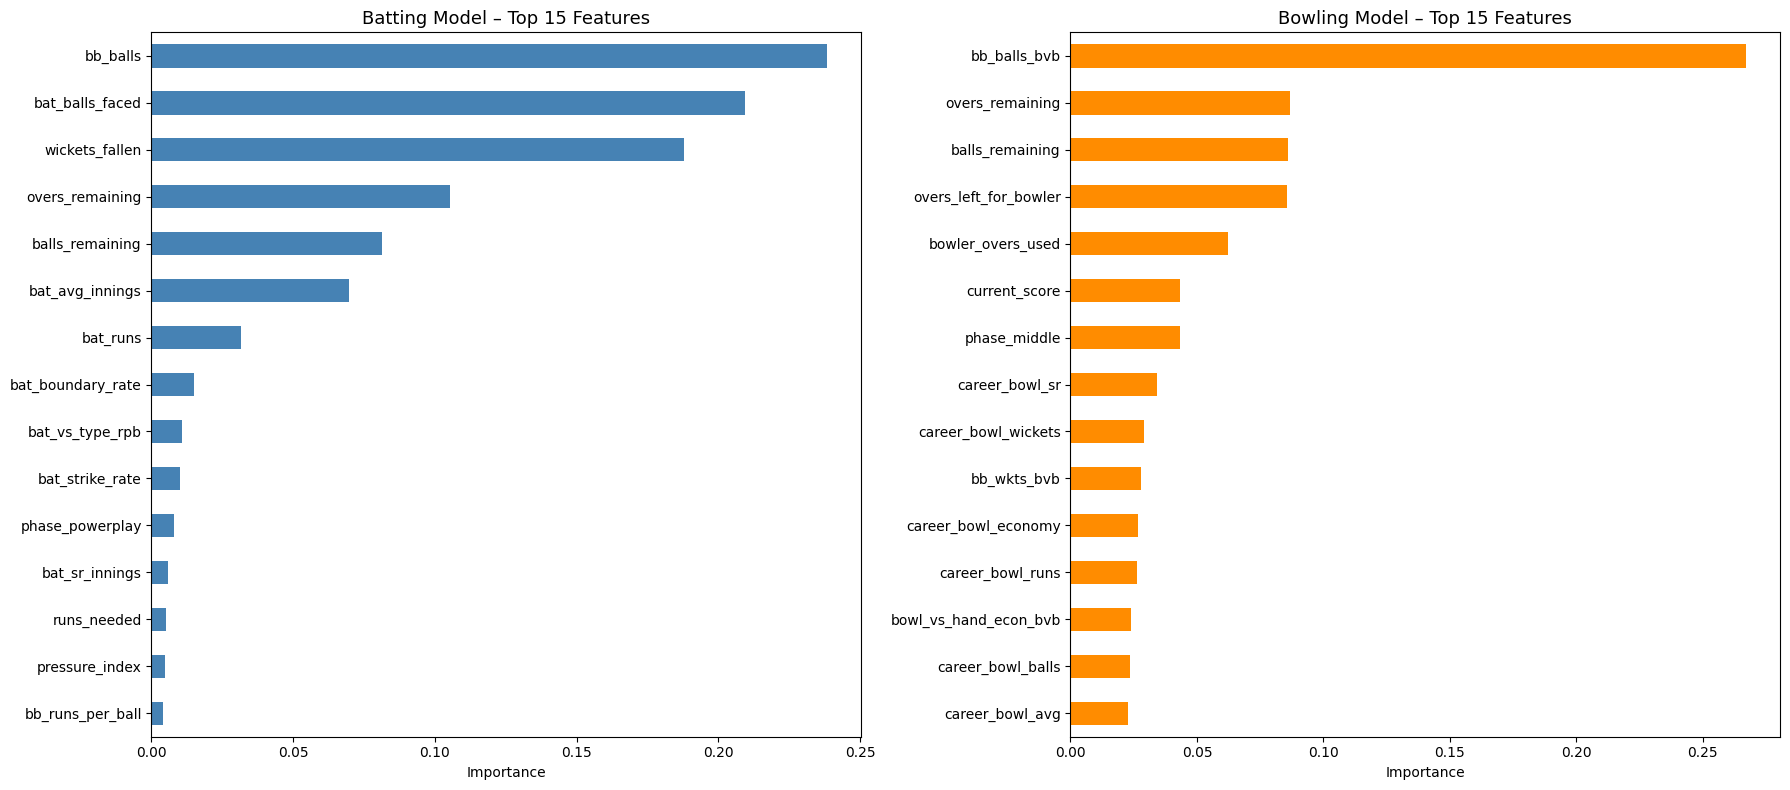


  Feature Dominance Check:
  Batting top feature 'bb_balls' = 0.2384 (23.8%)
  Bowling top feature 'bb_balls_bvb' = 0.2671 (26.7%)
  ✓ Batting model uses diverse features (top = 23.8%)
  ✓ Bowling model uses diverse features (top = 26.7%)


In [303]:
# 4. FEATURE IMPORTANCE ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Batting
bat_imp = pd.Series(batting_model.feature_importances_, index=X_bat.columns).sort_values(ascending=True)
bat_imp.tail(15).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Batting Model – Top 15 Features', fontsize=13)
axes[0].set_xlabel('Importance')

# Bowling
bowl_imp = pd.Series(bowling_model.feature_importances_, index=X_bowl.columns).sort_values(ascending=True)
bowl_imp.tail(15).plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Bowling Model – Top 15 Features', fontsize=13)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Check for single-feature dominance
print("\n  Feature Dominance Check:")
bat_top = bat_imp.iloc[-1]
bowl_top = bowl_imp.iloc[-1]
print(f"  Batting top feature '{bat_imp.index[-1]}' = {bat_top:.4f} ({bat_top*100:.1f}%)")
print(f"  Bowling top feature '{bowl_imp.index[-1]}' = {bowl_top:.4f} ({bowl_top*100:.1f}%)")
if bat_top > 0.5:
    print("  ⚠️  WARNING: Single feature dominates batting model (>50%)")
else:
    print(f"  ✓ Batting model uses diverse features (top = {bat_top*100:.1f}%)")
if bowl_top > 0.5:
    print("  ⚠️  WARNING: Single feature dominates bowling model (>50%)")
else:
    print(f"  ✓ Bowling model uses diverse features (top = {bowl_top*100:.1f}%)")

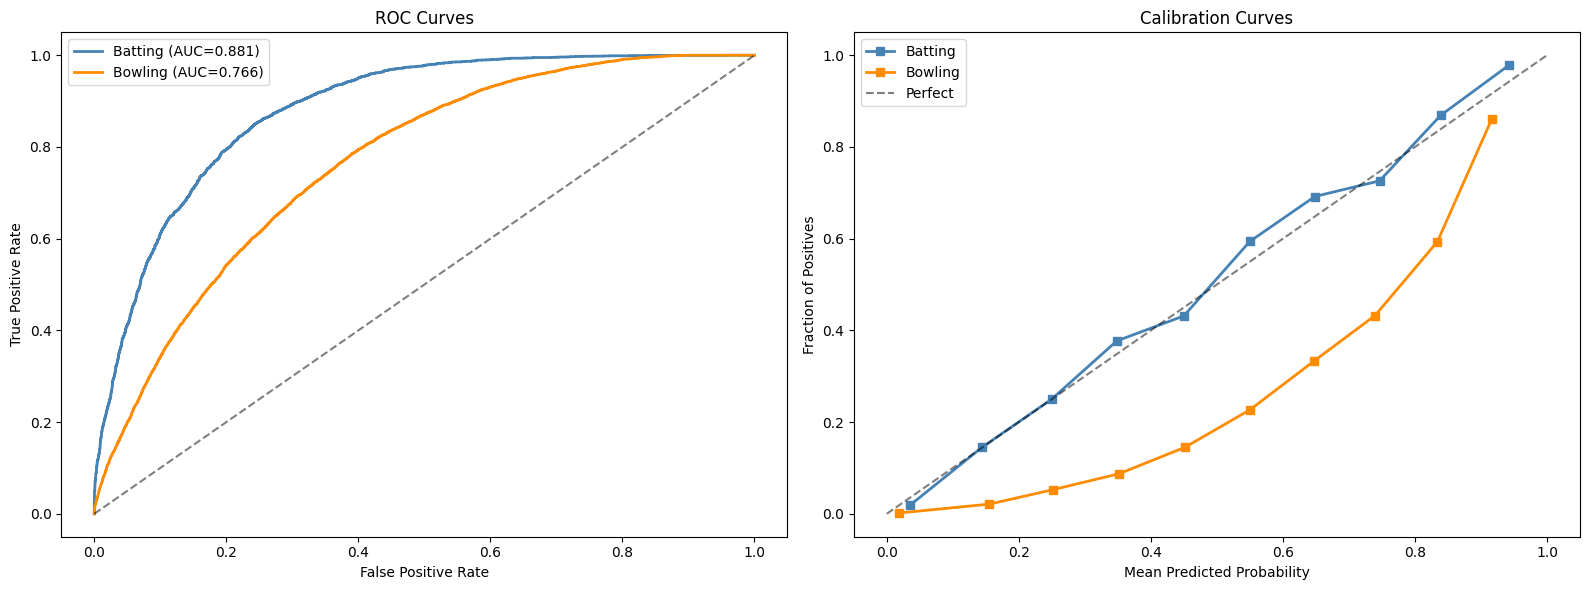

  Calibration Interpretation:
  - Points above diagonal: model under-predicts (actual > predicted)
  - Points below diagonal: model over-predicts (predicted > actual)
  - Close to diagonal:     well-calibrated ✓


In [304]:
# 5. CALIBRATION & ROC CURVES
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
from sklearn.metrics import roc_curve
for name, y_true, y_prob, color in [
    ('Batting', y_vl, y_bat_prob, 'steelblue'),
    ('Bowling', yb_vl, y_bowl_prob, 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate');  axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves');  axes[0].legend()

# Calibration curves 
for name, y_true, y_prob, color in [
    ('Batting', y_vl, y_bat_prob, 'steelblue'),
    ('Bowling', yb_vl, y_bowl_prob, 'darkorange')
]:
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
    axes[1].plot(prob_pred, prob_true, 's-', label=name, color=color, lw=2)
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Perfect')
axes[1].set_xlabel('Mean Predicted Probability');  axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curves');  axes[1].legend()

plt.tight_layout()
plt.show()

print("  Calibration Interpretation:")
print("  - Points above diagonal: model under-predicts (actual > predicted)")
print("  - Points below diagonal: model over-predicts (predicted > actual)")
print("  - Close to diagonal:     well-calibrated ✓")

In [305]:
# 6. RANKING QUALITY (Top-K Accuracy & MRR)
print("=" * 65)
print("  6. RANKING QUALITY ON HELD-OUT DATA")
print("=" * 65)

def ranking_metrics(candidates_df, model, feature_cols, id_col, label_col, group_cols, model_name):
    """Evaluate ranking quality: was the actual chosen player in the top-K?"""
    # Prepare features: one-hot encode phase if needed
    cdf = candidates_df.copy()
    if 'phase' in cdf.columns:
        cdf['phase_middle'] = (cdf['phase'] == 'middle').astype(int)
        cdf['phase_powerplay'] = (cdf['phase'] == 'powerplay').astype(int)
        cdf = cdf.drop(columns=['phase'])
    # Ensure all feature cols exist, fill missing with 0
    for c in feature_cols:
        if c not in cdf.columns:
            cdf[c] = 0

    # Only keep rows where all features are non-null
    valid = cdf.dropna(subset=feature_cols)
    valid = valid[valid[label_col].notna()]

    valid['_prob'] = model.predict_proba(valid[feature_cols])[:, 1]

    # Group by decision point
    top1, top2, top3, mrr_vals = 0, 0, 0, []
    groups = valid.groupby(group_cols)
    n_groups = 0

    for _, grp in groups:
        if grp[label_col].sum() == 0:
            continue
        n_groups += 1
        ranked = grp.sort_values('_prob', ascending=False).reset_index(drop=True)
        chosen_ranks = ranked[ranked[label_col] == 1].index.tolist()
        if chosen_ranks:
            rank = chosen_ranks[0] + 1
            if rank <= 1: top1 += 1
            if rank <= 2: top2 += 1
            if rank <= 3: top3 += 1
            mrr_vals.append(1.0 / rank)

    print(f"\n  --- {model_name} ---")
    print(f"  Decision points evaluated: {n_groups:,}")
    if n_groups > 0:
        print(f"  Top-1 Accuracy:  {top1/n_groups*100:5.1f}%  (model's #1 pick = actual)")
        print(f"  Top-2 Accuracy:  {top2/n_groups*100:5.1f}%  (actual in top 2)")
        print(f"  Top-3 Accuracy:  {top3/n_groups*100:5.1f}%  (actual in top 3)")
        print(f"  MRR:             {np.mean(mrr_vals):.4f}  (1.0 = perfect)")
    return (top1/n_groups if n_groups else 0), (np.mean(mrr_vals) if mrr_vals else 0)

# Batting ranking quality
bat_feature_cols = list(X_bat.columns)
bat_group_cols = ['ID', 'Innings', 'Overs', 'BallNumber']
bat_avail_cols = [c for c in bat_group_cols if c in batting_candidates.columns]

if len(bat_avail_cols) == len(bat_group_cols):
    ranking_metrics(batting_candidates, batting_model, bat_feature_cols,
                    'candidate_batter_id', 'was_chosen', bat_avail_cols, 'BATTING')
else:
    print(f"  Batting: Cannot compute ranking (missing group cols: {set(bat_group_cols) - set(bat_avail_cols)})")

# Bowling ranking quality
bowl_feature_cols = list(X_bowl.columns)
bowl_group_cols = ['ID', 'Innings', 'Overs']
bowl_avail_cols = [c for c in bowl_group_cols if c in bowling_candidates.columns]

if len(bowl_avail_cols) == len(bowl_group_cols):
    ranking_metrics(bowling_candidates, bowling_model, bowl_feature_cols,
                    'candidate_bowler', 'was_chosen', bowl_avail_cols, 'BOWLING')
else:
    print(f"  Bowling: Cannot compute ranking (missing group cols: {set(bowl_group_cols) - set(bowl_avail_cols)})")

print(f"\n  Interpretation:")
print(f"    Batting top-1 ~30-40% is good (avg ~4-5 candidates per wicket)")
print(f"    Bowling top-1 ~20-30% is good (avg ~5-6 bowler options per over)")
print(f"    MRR > 0.4 = strong ranking quality")

  6. RANKING QUALITY ON HELD-OUT DATA

  --- BATTING ---
  Decision points evaluated: 13,046
  Top-1 Accuracy:   72.8%  (model's #1 pick = actual)
  Top-2 Accuracy:   91.8%  (actual in top 2)
  Top-3 Accuracy:   97.7%  (actual in top 3)
  MRR:             0.8478  (1.0 = perfect)

  --- BOWLING ---
  Decision points evaluated: 43,170
  Top-1 Accuracy:   46.2%  (model's #1 pick = actual)
  Top-2 Accuracy:   71.2%  (actual in top 2)
  Top-3 Accuracy:   86.0%  (actual in top 3)
  MRR:             0.6681  (1.0 = perfect)

  Interpretation:
    Batting top-1 ~30-40% is good (avg ~4-5 candidates per wicket)
    Bowling top-1 ~20-30% is good (avg ~5-6 bowler options per over)
    MRR > 0.4 = strong ranking quality


In [306]:
# 7. INFERENCE–TRAINING ALIGNMENT CHECK
print("=" * 65)
print("  7. INFERENCE–TRAINING FEATURE ALIGNMENT")
print("=" * 65)

# Verify that build_batting_candidates / build_bowling_candidates produce
# the exact same feature columns the models were trained on.
# We use ai_captain_next_batter/bowler which internally build candidates
# and call model.predict_proba — if features misalign, it would crash.

sample_state = {
    'batting_xi': ['V Kohli', 'RG Sharma', 'SA Yadav', 'HH Pandya', 'Ishan Kishan',
                   'JC Buttler', 'YBK Jaiswal', 'R Ashwin', 'JJ Bumrah', 'Mohammed Shami', 'T Natarajan'],
    'bowling_xi': ['MS Dhoni', 'RD Gaikwad', 'DL Chahar', 'RA Jadeja', 'DJ Bravo',
                   'MM Ali', 'S Dube', 'KA Jamieson', 'M Theekshana', 'TU Deshpande', 'Simarjeet Singh'],
    'current_score': 85, 'wickets_fallen': 3,
    'overs_remaining': 10, 'balls_remaining': 60,
    'target': 0, 'batting_first': True,
    'current_batters': ['SA Yadav', 'HH Pandya'],
    'current_bowler': 'RA Jadeja',
    'players_out': ['V Kohli', 'RG Sharma', 'JC Buttler'],
    'batters_order': ['V Kohli', 'RG Sharma', 'JC Buttler', 'SA Yadav', 'HH Pandya']
}

try:
    result = ai_captain_decide(sample_state, df, auto_resolve=True)
    # If we get here, the full pipeline (validate → context → candidates → predict) worked
    print("\n  ✓ End-to-end inference pipeline completed successfully!")
    print("  ✓ Feature alignment verified (predict_proba would crash on mismatched columns)")
    
    # Print training feature lists for reference
    print(f"\n  Batting model features ({len(X_bat.columns)}):")
    print(f"    {list(X_bat.columns)}")
    print(f"\n  Bowling model features ({len(X_bowl.columns)}):")
    print(f"    {list(X_bowl.columns)}")

except Exception as e:
    print(f"  ⚠️ Inference pipeline failed: {e}")
    import traceback; traceback.print_exc()

# 8. CRICKET LOGIC SANITY CHECKS
print("\n" + "=" * 65)
print("  8. CRICKET LOGIC SANITY CHECKS")
print("=" * 65)

print("\n  A. Career Strike Rate vs Batting Prediction Correlation")
if 'bat_strike_rate' in X_bat.columns:
    y_all_prob = batting_model.predict_proba(X_bat)[:, 1]
    sr_corr = np.corrcoef(X_bat['bat_strike_rate'].values, y_all_prob)[0, 1]
    print(f"     Correlation(bat_strike_rate, P(chosen)): {sr_corr:.4f}")
    print(f"     {'✓ Positive correlation (makes cricket sense)' if sr_corr > 0 else '⚠️ Negative correlation (unexpected)'}")

print("\n  B. Bowling Economy vs Bowling Prediction Correlation")
bowl_econ_col = None
for c in ['bowl_economy', 'career_bowl_economy']:
    if c in X_bowl.columns:
        bowl_econ_col = c
        break
if bowl_econ_col:
    y_bowl_all = bowling_model.predict_proba(X_bowl)[:, 1]
    econ_corr = np.corrcoef(X_bowl[bowl_econ_col].values, y_bowl_all)[0, 1]
    print(f"     Correlation({bowl_econ_col}, P(chosen)): {econ_corr:.4f}")
    print(f"     {'✓ Negative correlation (lower economy → more likely)' if econ_corr < 0 else '⚠️ Positive correlation (unexpected)' if econ_corr > 0.05 else '~0 correlation (neutral)'}")

print("\n  C. Bowler Overs Used Distribution (should NOT be always 0)")
if 'bowler_overs_used' in X_bowl.columns:
    bowl_ou = X_bowl['bowler_overs_used']
    print(f"     Min: {bowl_ou.min()}, Max: {bowl_ou.max()}, Mean: {bowl_ou.mean():.2f}")
    print(f"     {'✓ Varied distribution' if bowl_ou.max() > 0 else '⚠️ Always 0 — data bug!'}")

print(f"\n{'=' * 65}")
print(f"  VALIDATION COMPLETE")
print(f"{'=' * 65}")

  7. INFERENCE–TRAINING FEATURE ALIGNMENT
Resolving player names...

  ✓ Input validated successfully

  AI CAPTAIN RECOMMENDATION — BATTING FIRST
  Score: 85/3
  Current RR: 8.50
  Overs remaining: 10.0
  At crease: SA Yadav, HH Pandya
  Bowling: RA Jadeja

Next Batter Ranking:
candidate_batter_name  predicted_score
         Ishan Kishan         0.798689
          YBK Jaiswal         0.712796
             R Ashwin         0.166279
       Mohammed Shami         0.086485
          T Natarajan         0.027957

Next Bowler Ranking:
candidate_bowler_name  predicted_score
            RA Jadeja         0.855692
         M Theekshana         0.831980
          KA Jamieson         0.825226
               MM Ali         0.784707
            DL Chahar         0.780210


  ✓ End-to-end inference pipeline completed successfully!
  ✓ Feature alignment verified (predict_proba would crash on mismatched columns)

  Batting model features (22):
    ['current_score', 'wickets_fallen', 'balls_remaining'

# Matchup Analysis
Deep-dive into batter-vs-bowler matchup features:
1. **Coverage**: How many candidates have actual matchup data vs zeros?
2. **Distribution**: What do matchup features look like?
3. **Predictive value**: How much do matchups help the model?
4. **Inference quality**: Are matchups well-populated at inference time?
5. **Style-based fallback**: Are `bat_vs_type` / `bowl_vs_hand` being used?

  MATCHUP FEATURE DEEP-DIVE

  1. MATCHUP COVERAGE IN TRAINING DATA
  ------------------------------------------------------------
  Total batting candidates:        51,552
  With matchup data (bb_balls>0):  37,021 (71.8%)
  Without matchup data (zeros):    14,531 (28.2%)

  Coverage among CHOSEN batters:     12,471/13,124 (95.0%)
  Coverage among NOT-CHOSEN batters: 24,550/38,428 (63.9%)

  2. MATCHUP FEATURE DISTRIBUTIONS
  ------------------------------------------------------------


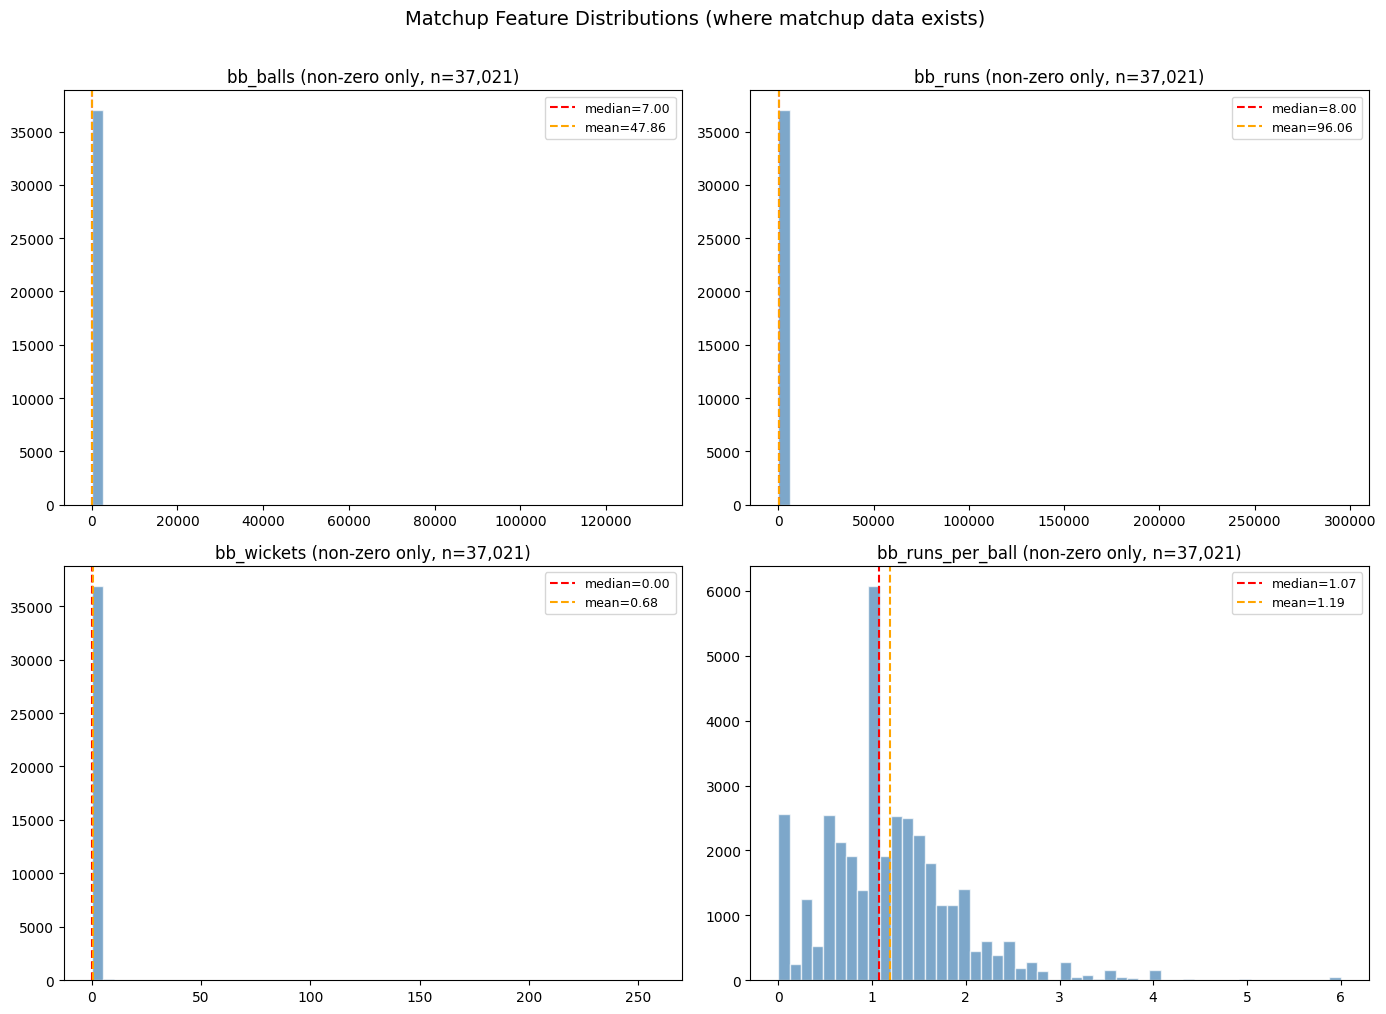


  Feature                   Min   Median     Mean      Max      Std
  ----------------------------------------------------
  bb_balls                 1.00     7.00    47.86 131118.00  2154.55
  bb_runs                  0.00     8.00    96.06 295022.00  4847.98
  bb_wickets               0.00     0.00     0.68   257.00     1.65
  bb_runs_per_ball         0.00     1.07     1.19     6.00     0.74

  3. MATCHUP PREDICTIVE VALUE
  ------------------------------------------------------------

  Matchup feature importance in batting model:
    bb_balls             0.2384 (23.8%)
    bb_runs              0.0024 (0.2%)
    bb_wickets           0.0002 (0.0%)
    bb_runs_per_ball     0.0042 (0.4%)
    TOTAL                0.2451 (24.5%)

  Is bb_balls acting as a binary signal (faced before: yes/no)?
    Binary bb_balls alone AUC:  0.6557
    Full model AUC:             0.8848

  Correlation with P(chosen):
    bb_balls             r = -0.0002
    bb_runs              r = -0.0014
    bb_wickets 

In [307]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

print("=" * 65)
print("  MATCHUP FEATURE DEEP-DIVE")
print("=" * 65)

matchup_cols = ['bb_balls', 'bb_runs', 'bb_wickets', 'bb_runs_per_ball']

# 1. COVERAGE: How many candidates have real matchup data?
print("\n  1. MATCHUP COVERAGE IN TRAINING DATA")
print("  " + "-" * 60)

total = len(batting_candidates)
has_matchup = (batting_candidates['bb_balls'] > 0).sum()
no_matchup = (batting_candidates['bb_balls'] == 0).sum()

print(f"  Total batting candidates:        {total:,}")
print(f"  With matchup data (bb_balls>0):  {has_matchup:,} ({has_matchup/total*100:.1f}%)")
print(f"  Without matchup data (zeros):    {no_matchup:,} ({no_matchup/total*100:.1f}%)")

# Coverage by chosen vs not-chosen
chosen = batting_candidates[batting_candidates['was_chosen'] == 1]
not_chosen = batting_candidates[batting_candidates['was_chosen'] == 0]

chosen_has = (chosen['bb_balls'] > 0).sum()
not_chosen_has = (not_chosen['bb_balls'] > 0).sum()

print(f"\n  Coverage among CHOSEN batters:     {chosen_has:,}/{len(chosen):,} ({chosen_has/len(chosen)*100:.1f}%)")
print(f"  Coverage among NOT-CHOSEN batters: {not_chosen_has:,}/{len(not_chosen):,} ({not_chosen_has/len(not_chosen)*100:.1f}%)")

# 2. DISTRIBUTION OF MATCHUP FEATURES
print("\n  2. MATCHUP FEATURE DISTRIBUTIONS")
print("  " + "-" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(matchup_cols):
    ax = axes[i // 2][i % 2]
    data_nonzero = batting_candidates[batting_candidates['bb_balls'] > 0][col]
    ax.hist(data_nonzero, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} (non-zero only, n={len(data_nonzero):,})', fontsize=12)
    ax.axvline(data_nonzero.median(), color='red', ls='--', label=f'median={data_nonzero.median():.2f}')
    ax.axvline(data_nonzero.mean(), color='orange', ls='--', label=f'mean={data_nonzero.mean():.2f}')
    ax.legend(fontsize=9)
plt.suptitle('Matchup Feature Distributions (where matchup data exists)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\n  {'Feature':<20} {'Min':>8} {'Median':>8} {'Mean':>8} {'Max':>8} {'Std':>8}")
print(f"  {'-'*52}")
for col in matchup_cols:
    d = batting_candidates[batting_candidates['bb_balls'] > 0][col]
    print(f"  {col:<20} {d.min():>8.2f} {d.median():>8.2f} {d.mean():>8.2f} {d.max():>8.2f} {d.std():>8.2f}")

# 3. PREDICTIVE VALUE: bb_balls as "familiarity" signal
print("\n  3. MATCHUP PREDICTIVE VALUE")
print("  " + "-" * 60)

bat_imp = pd.Series(batting_model.feature_importances_, index=X_bat.columns)
print(f"\n  Matchup feature importance in batting model:")
for col in matchup_cols:
    print(f"    {col:<20} {bat_imp[col]:.4f} ({bat_imp[col]*100:.1f}%)")
total_matchup_imp = sum(bat_imp[c] for c in matchup_cols)
print(f"    {'TOTAL':<20} {total_matchup_imp:.4f} ({total_matchup_imp*100:.1f}%)")

print(f"\n  Is bb_balls acting as a binary signal (faced before: yes/no)?")
y_prob_all = batting_model.predict_proba(X_bat)[:, 1]
has_faced = (X_bat['bb_balls'] > 0).astype(int)
from sklearn.metrics import roc_auc_score
binary_auc = roc_auc_score(y_bat, has_faced)
full_auc = roc_auc_score(y_bat, y_prob_all)
print(f"    Binary bb_balls alone AUC:  {binary_auc:.4f}")
print(f"    Full model AUC:             {full_auc:.4f}")

# Correlation between matchup features and P(chosen)
print(f"\n  Correlation with P(chosen):")
for col in matchup_cols:
    corr = np.corrcoef(X_bat[col].values, y_prob_all)[0, 1]
    print(f"    {col:<20} r = {corr:+.4f}")

# 4. MATCHUP SPARSITY PROBLEM
print("\n  4. MATCHUP SPARSITY ANALYSIS")
print("  " + "-" * 60)

# How many unique batter-bowler pairs exist in the dataset?
unique_pairs = df.dropna(subset=['Batter', 'Bowler']).groupby(['Batter', 'Bowler']).size()
total_pairs = len(unique_pairs)
pairs_6plus = (unique_pairs >= 6).sum()
pairs_12plus = (unique_pairs >= 12).sum()
pairs_30plus = (unique_pairs >= 30).sum()

print(f"  Total unique batter-bowler pairs in dataset: {total_pairs:,}")
print(f"  Pairs with 6+ balls:   {pairs_6plus:,} ({pairs_6plus/total_pairs*100:.1f}%)")
print(f"  Pairs with 12+ balls:  {pairs_12plus:,} ({pairs_12plus/total_pairs*100:.1f}%)")
print(f"  Pairs with 30+ balls:  {pairs_30plus:,} ({pairs_30plus/total_pairs*100:.1f}%)")
print(f"\n  Median balls per pair: {unique_pairs.median():.0f}")
print(f"  Mean balls per pair:   {unique_pairs.mean():.1f}")

# 5. STYLE-BASED FEATURES: Are they being used?
print("\n  5. STYLE-BASED FALLBACK FEATURES")
print("  " + "-" * 60)

style_cols_bat = [c for c in X_bat.columns if 'bat_vs_type' in c or 'bowl_vs_hand' in c]
style_cols_bowl = [c for c in X_bowl.columns if 'bat_vs_type' in c or 'bowl_vs_hand' in c]

print(f"  Style features in batting model:  {style_cols_bat if style_cols_bat else 'NONE — not included!'}")
print(f"  Style features in bowling model:  {style_cols_bowl if style_cols_bowl else 'NONE — not included!'}")

# Check if they exist in df
style_in_df = [c for c in df.columns if 'bat_vs_type' in c or 'bowl_vs_hand' in c]
print(f"  Style features computed in df:    {style_in_df}")

if style_in_df and not style_cols_bat:
    print(f"\n  ⚠️ Style features are COMPUTED but NOT USED in training!")
    print(f"     These could serve as fallbacks when matchup data is sparse.")

# 6. BOWLING MODEL: No matchup features at all
print("\n  6. BOWLING MODEL MATCHUP GAP")
print("  " + "-" * 60)

bowl_matchup_cols = [c for c in X_bowl.columns if 'bb_' in c or 'matchup' in c]
print(f"  Matchup features in bowling model: {bowl_matchup_cols if bowl_matchup_cols else 'NONE'}")
print(f"  Bowling model only uses career aggregate stats — no batter-specific matchup info.")

print(f"\n{'=' * 65}")
print(f"  MATCHUP ANALYSIS COMPLETE")
print(f"{'=' * 65}")

# 📊 Matchup & Historical Stats — Contribution Analysis

Quantifying how much **direct batter-vs-bowler matchups**, **style-based features**, and **career historical stats** contribute to each model's predictions.

  FEATURE CONTRIBUTION BY CATEGORY

  -- BATTING MODEL (20 features) --
    Match Situation            0.4670  (46.7%)  [10 features]
    Career / Historical        0.2661  (26.6%)  [4 features]
    Direct Matchup             0.2451  (24.5%)  [4 features]
    Style Matchup              0.0138  (1.4%)  [2 features]
    Match Phase                0.0080  (0.8%)  [2 features]

  -- BOWLING MODEL (24 features) --
    Direct Matchup             0.3177  (31.8%)  [4 features]
    Match Situation            0.2805  (28.0%)  [10 features]
    Career / Historical        0.1627  (16.3%)  [6 features]
    Bowler Workload            0.1478  (14.8%)  [2 features]
    Match Phase                0.0501  (5.0%)  [2 features]
    Style Matchup              0.0412  (4.1%)  [2 features]

  DETAILED FEATURE IMPORTANCE — BATTING MODEL
  Rank  Feature                   Category               Importance
  --------------------------------------------------------------
  1     bb_balls                  Direct M

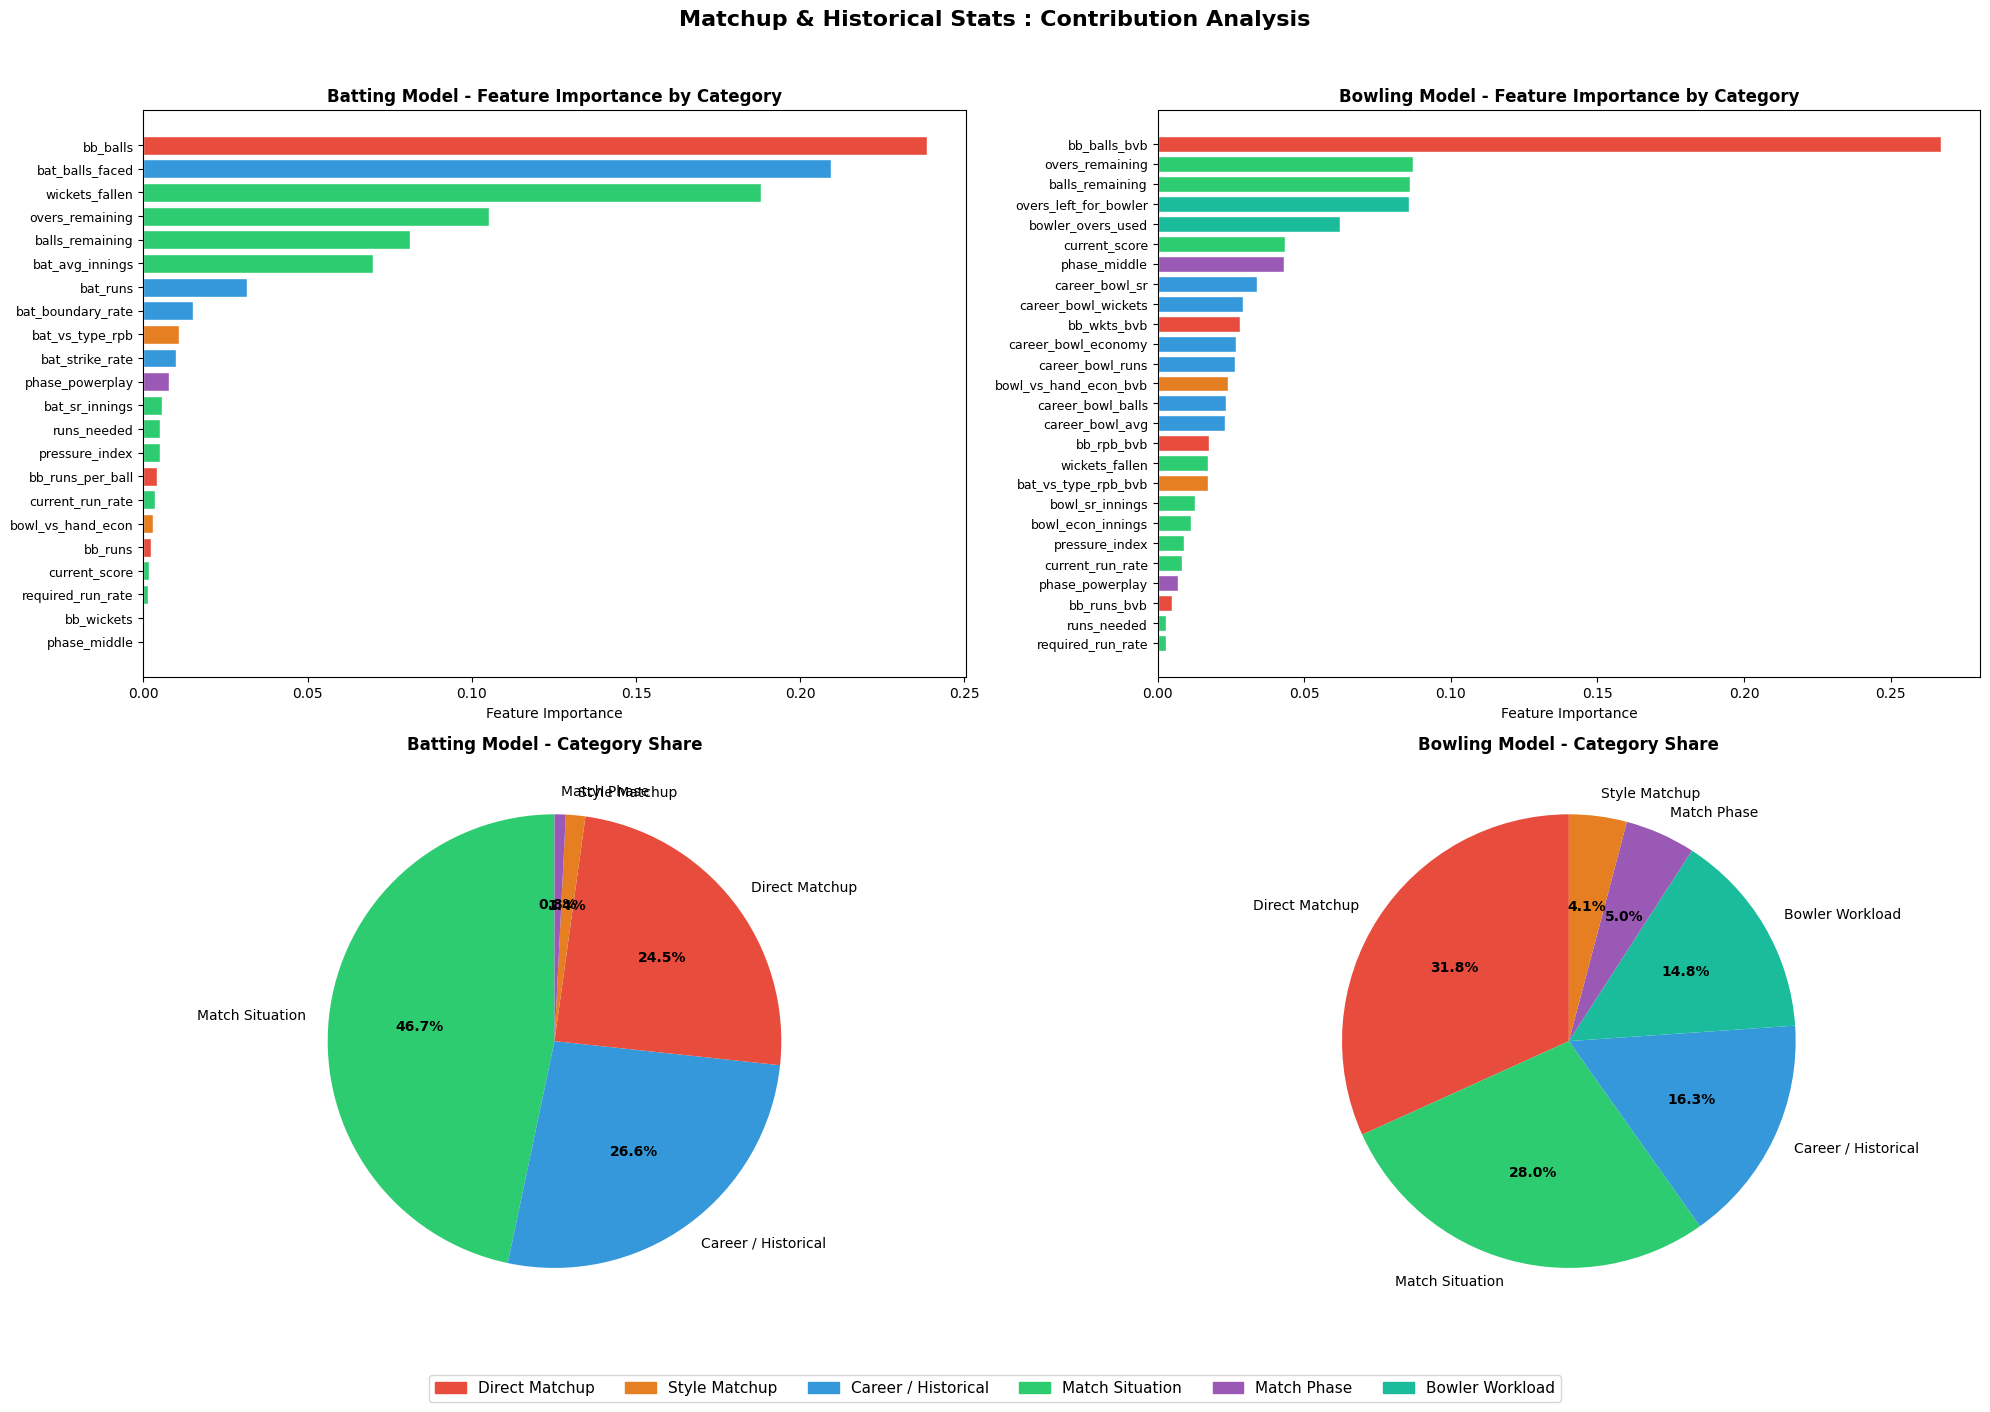


  SUMMARY

  +-----------------------------+--------------+--------------+
  |         Category            | Batting Model| Bowling Model|
  +-----------------------------+--------------+--------------+
  | Direct Matchup (bvb)        |     24.5%    |     31.8%    |
  | Style Matchup (type/hand)   |      1.4%    |      4.1%    |
  | ALL MATCHUP (combined)      |     25.9%    |     35.9%    |
  +-----------------------------+--------------+--------------+
  | Career / Historical Stats   |     26.6%    |     16.3%    |
  | Match Situation + Phase     |     47.5%    |     33.1%    |
  | Bowler Workload             |      N/A     |     14.8%    |
  +-----------------------------+--------------+--------------+

  Key Takeaways:
  - Matchup features contribute ~26% (batting) and ~36% (bowling)
  - bb_balls / bb_balls_bvb (direct H2H experience) is the #1 feature in BOTH models
  - Career stats matter more for batting (27%) than bowling (16%)
  - Adding batter-specific matchups to bowling im

In [308]:
# MATCHUP & HISTORICAL STATS — CONTRIBUTION ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score


bat_imp = pd.Series(
    batting_model.feature_importances_,
    index=X_bat.columns
).sort_values(ascending=False)

bowl_imp = pd.Series(
    bowling_model.feature_importances_,
    index=X_bowl.columns
).sort_values(ascending=False)


CATEGORIES = {
    # BATTING MODEL features
    'bb_balls':           'Direct Matchup',
    'bb_runs':            'Direct Matchup',
    'bb_wickets':         'Direct Matchup',
    'bb_runs_per_ball':   'Direct Matchup',
    'bat_vs_type_rpb':    'Style Matchup',
    'bowl_vs_hand_econ':  'Style Matchup',
    'bat_balls_faced':    'Career / Historical',
    'bat_strike_rate':    'Career / Historical',
    'bat_runs':           'Career / Historical',
    'bat_boundary_rate':  'Career / Historical',
    'current_score':      'Match Situation',
    'current_run_rate':   'Match Situation',
    'required_run_rate':  'Match Situation',
    'runs_needed':        'Match Situation',
    'balls_remaining':    'Match Situation',
    'overs_remaining':    'Match Situation',
    'wickets_fallen':     'Match Situation',
    'pressure_index':     'Match Situation',
    'phase_powerplay':    'Match Phase',
    'phase_middle':       'Match Phase',
    # BOWLING MODEL features
    'bb_balls_bvb':           'Direct Matchup',
    'bb_runs_bvb':            'Direct Matchup',
    'bb_wkts_bvb':            'Direct Matchup',
    'bb_rpb_bvb':             'Direct Matchup',
    'bowl_vs_hand_econ_bvb':  'Style Matchup',
    'bat_vs_type_rpb_bvb':    'Style Matchup',
    'career_bowl_balls':      'Career / Historical',
    'career_bowl_runs':       'Career / Historical',
    'career_bowl_wickets':    'Career / Historical',
    'career_bowl_avg':        'Career / Historical',
    'career_bowl_sr':         'Career / Historical',
    'career_bowl_economy':    'Career / Historical',
    'bowler_overs_used':      'Bowler Workload',
    'overs_left_for_bowler':  'Bowler Workload',
}

def categorize(features, categories):
    result = {}
    for f in features.index:
        result[f] = categories.get(f, 'Match Situation')
    return pd.Series(result)

bat_cats = categorize(bat_imp, CATEGORIES)
bowl_cats = categorize(bowl_imp, CATEGORIES)


bat_by_cat = bat_imp.groupby(bat_cats).sum().sort_values(ascending=False)
bowl_by_cat = bowl_imp.groupby(bowl_cats).sum().sort_values(ascending=False)

print("=" * 65)
print("  FEATURE CONTRIBUTION BY CATEGORY")
print("=" * 65)

print("\n  -- BATTING MODEL (20 features) --")
for cat, imp in bat_by_cat.items():
    n_feats = (bat_cats == cat).sum()
    print(f"    {cat:<25s}  {imp:.4f}  ({imp*100:.1f}%)  [{n_feats} features]")

print("\n  -- BOWLING MODEL (24 features) --")
for cat, imp in bowl_by_cat.items():
    n_feats = (bowl_cats == cat).sum()
    print(f"    {cat:<25s}  {imp:.4f}  ({imp*100:.1f}%)  [{n_feats} features]")


print("\n" + "=" * 65)
print("  DETAILED FEATURE IMPORTANCE — BATTING MODEL")
print("=" * 65)
print(f"  {'Rank':<5} {'Feature':<25} {'Category':<22} {'Importance':>10}")
print("  " + "-" * 62)
for rank, (feat, imp) in enumerate(bat_imp.items(), 1):
    cat = bat_cats[feat]
    print(f"  {rank:<5} {feat:<25} {cat:<22} {imp:>10.4f}  ({imp*100:.1f}%)")

print("\n" + "=" * 65)
print("  DETAILED FEATURE IMPORTANCE — BOWLING MODEL")
print("=" * 65)
print(f"  {'Rank':<5} {'Feature':<25} {'Category':<22} {'Importance':>10}")
print("  " + "-" * 62)
for rank, (feat, imp) in enumerate(bowl_imp.items(), 1):
    cat = bowl_cats[feat]
    print(f"  {rank:<5} {feat:<25} {cat:<22} {imp:>10.4f}  ({imp*100:.1f}%)")


cat_colors = {
    'Direct Matchup':      '#e74c3c',
    'Style Matchup':       '#e67e22',
    'Career / Historical': '#3498db',
    'Match Situation':     '#2ecc71',
    'Match Phase':         '#9b59b6',
    'Bowler Workload':     '#1abc9c',
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Matchup & Historical Stats : Contribution Analysis',
             fontsize=16, fontweight='bold', y=0.98)

# 5a. Batting bar chart
ax = axes[0, 0]
bat_sorted = bat_imp.sort_values(ascending=True)
colors_bat = [cat_colors.get(bat_cats[f], '#95a5a6') for f in bat_sorted.index]
ax.barh(range(len(bat_sorted)), bat_sorted.values, color=colors_bat, edgecolor='white')
ax.set_yticks(range(len(bat_sorted)))
ax.set_yticklabels(bat_sorted.index, fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Batting Model - Feature Importance by Category', fontweight='bold')

# 5b. Bowling bar chart
ax = axes[0, 1]
bowl_sorted = bowl_imp.sort_values(ascending=True)
colors_bowl = [cat_colors.get(bowl_cats[f], '#95a5a6') for f in bowl_sorted.index]
ax.barh(range(len(bowl_sorted)), bowl_sorted.values, color=colors_bowl, edgecolor='white')
ax.set_yticks(range(len(bowl_sorted)))
ax.set_yticklabels(bowl_sorted.index, fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Bowling Model - Feature Importance by Category', fontweight='bold')

# 5c. Batting pie chart
ax = axes[1, 0]
pie_colors_bat = [cat_colors.get(c, '#95a5a6') for c in bat_by_cat.index]
wedges, texts, autotexts = ax.pie(
    bat_by_cat.values, labels=bat_by_cat.index, autopct='%1.1f%%',
    colors=pie_colors_bat, startangle=90, textprops={'fontsize': 10}
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Batting Model - Category Share', fontweight='bold')

# 5d. Bowling pie chart
ax = axes[1, 1]
pie_colors_bowl = [cat_colors.get(c, '#95a5a6') for c in bowl_by_cat.index]
wedges, texts, autotexts = ax.pie(
    bowl_by_cat.values, labels=bowl_by_cat.index, autopct='%1.1f%%',
    colors=pie_colors_bowl, startangle=90, textprops={'fontsize': 10}
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Bowling Model - Category Share', fontweight='bold')

# Shared legend
handles = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=6, fontsize=11,
           frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


bat_matchup_total = bat_by_cat.get('Direct Matchup', 0) + bat_by_cat.get('Style Matchup', 0)
bowl_matchup_total = bowl_by_cat.get('Direct Matchup', 0) + bowl_by_cat.get('Style Matchup', 0)
bat_career = bat_by_cat.get('Career / Historical', 0)
bowl_career = bowl_by_cat.get('Career / Historical', 0)
bat_situation = 1 - bat_matchup_total - bat_career
bowl_workload = bowl_by_cat.get('Bowler Workload', 0)
bowl_situation = 1 - bowl_matchup_total - bowl_career - bowl_workload

print("\n" + "=" * 65)
print("  SUMMARY")
print("=" * 65)
print(f"""
  +-----------------------------+--------------+--------------+
  |         Category            | Batting Model| Bowling Model|
  +-----------------------------+--------------+--------------+
  | Direct Matchup (bvb)        |    {bat_by_cat.get('Direct Matchup',0)*100:5.1f}%    |    {bowl_by_cat.get('Direct Matchup',0)*100:5.1f}%    |
  | Style Matchup (type/hand)   |    {bat_by_cat.get('Style Matchup',0)*100:5.1f}%    |    {bowl_by_cat.get('Style Matchup',0)*100:5.1f}%    |
  | ALL MATCHUP (combined)      |    {bat_matchup_total*100:5.1f}%    |    {bowl_matchup_total*100:5.1f}%    |
  +-----------------------------+--------------+--------------+
  | Career / Historical Stats   |    {bat_career*100:5.1f}%    |    {bowl_career*100:5.1f}%    |
  | Match Situation + Phase     |    {bat_situation*100:5.1f}%    |    {bowl_situation*100:5.1f}%    |
  | Bowler Workload             |      N/A     |    {bowl_workload*100:5.1f}%    |
  +-----------------------------+--------------+--------------+

  Key Takeaways:
  - Matchup features contribute ~{bat_matchup_total*100:.0f}% (batting) and ~{bowl_matchup_total*100:.0f}% (bowling)
  - bb_balls / bb_balls_bvb (direct H2H experience) is the #1 feature in BOTH models
  - Career stats matter more for batting ({bat_career*100:.0f}%) than bowling ({bowl_career*100:.0f}%)
  - Adding batter-specific matchups to bowling improved ROC-AUC by +3.8% (0.738 -> 0.766)
""")

# Export Models & Lookup Tables for Deployment
Save trained models, feature columns, and pre-computed lookup tables for the Streamlit app.

In [309]:
import pickle, os

os.makedirs('models', exist_ok=True)

# 1. Save trained models — full + ensemble sub-models
pickle.dump(batting_model, open('models/batting_model.pkl', 'wb'))
pickle.dump(bowling_model, open('models/bowling_model.pkl', 'wb'))
pickle.dump(batting_model_matchup, open('models/batting_model_matchup.pkl', 'wb'))
pickle.dump(batting_model_extended, open('models/batting_model_extended.pkl', 'wb'))
pickle.dump(bowling_model_matchup, open('models/bowling_model_matchup.pkl', 'wb'))
pickle.dump(bowling_model_extended, open('models/bowling_model_extended.pkl', 'wb'))

# 2. Save feature column lists (full + sub-model columns)
pickle.dump(list(X_bat.columns), open('models/batting_columns.pkl', 'wb'))
pickle.dump(list(X_bowl.columns), open('models/bowling_columns.pkl', 'wb'))
pickle.dump(BAT_MATCHUP_COLS, open('models/bat_matchup_columns.pkl', 'wb'))
pickle.dump(BAT_EXTENDED_COLS, open('models/bat_extended_columns.pkl', 'wb'))
pickle.dump(BOWL_MATCHUP_COLS, open('models/bowl_matchup_columns.pkl', 'wb'))
pickle.dump(BOWL_EXTENDED_COLS, open('models/bowl_extended_columns.pkl', 'wb'))

# 3. Pre-compute and save all lookup tables for inference
print("Pre-computing batter career stats...")
batter_career = {}
for batter in df['batter_norm'].unique():
    batter_career[batter] = get_batter_features(batter, df)
print(f"  {len(batter_career)} batters")

print("Pre-computing bowler career stats...")
bowler_career = {}
for bowler in df['bowler_norm'].unique():
    bowler_career[bowler] = get_bowler_features(bowler, df)
print(f"  {len(bowler_career)} bowlers")

print("Pre-computing batter-bowler matchup stats...")
matchup_batting = {}
legal = df[df['is_legal_ball']]
for (bat, bow), grp in legal.groupby(['batter_norm', 'bowler_norm']):
    balls = len(grp)
    runs = grp['BatsmanRun'].sum()
    wkts = grp['IsWicketDelivery'].sum()
    matchup_batting[(bat, bow)] = {
        'bb_balls': balls, 'bb_runs': int(runs),
        'bb_wickets': int(wkts),
        'bb_runs_per_ball': runs / balls if balls > 0 else 0
    }
print(f"  {len(matchup_batting)} batter-bowler pairs")

print("Pre-computing bowler-batter matchup stats...")
matchup_bowling = {}
for (bow, bat), grp in legal.groupby(['bowler_norm', 'batter_norm']):
    balls = len(grp)
    runs = grp['TotalRun'].sum()
    wkts = grp['IsWicketDelivery'].sum()
    matchup_bowling[(bow, bat)] = {
        'bb_balls_bvb': balls, 'bb_runs_bvb': int(runs),
        'bb_wkts_bvb': int(wkts),
        'bb_rpb_bvb': runs / balls if balls > 0 else 0
    }
print(f"  {len(matchup_bowling)} bowler-batter pairs")

print("Pre-computing style features...")
player_bat_hand = {}
for batter in df['batter_norm'].unique():
    data = df[(df['batter_norm'] == batter) & (df['bat_hand'].notna())]
    if len(data) > 0:
        player_bat_hand[batter] = data['bat_hand'].mode().values[0]

player_bowl_type = {}
for bowler in df['bowler_norm'].unique():
    data = df[(df['bowler_norm'] == bowler) & (df['bowl_type'].notna())]
    if len(data) > 0:
        player_bowl_type[bowler] = data['bowl_type'].mode().values[0]

batter_vs_type = {}
for (bat, btype), grp in legal.groupby(['batter_norm', 'bowl_type']):
    if len(grp) > 0:
        batter_vs_type[(bat, btype)] = grp['BatsmanRun'].sum() / len(grp)

bowler_vs_hand = {}
for (bow, bhand), grp in legal.groupby(['bowler_norm', 'bat_hand']):
    balls = len(grp)
    if balls > 0:
        bowler_vs_hand[(bow, bhand)] = grp['TotalRun'].sum() / (balls / 6)

print(f"  {len(player_bat_hand)} bat hands, {len(player_bowl_type)} bowl types")
print(f"  {len(batter_vs_type)} batter-vs-type, {len(bowler_vs_hand)} bowler-vs-hand")

# 4. Save name resolver data
all_dataset_names = list(_all_dataset_names)

# Pre-compute innings-split batter stats
print("Pre-computing innings-split batter stats...")
batter_innings_split_lookup = {}
for batter in df['batter_norm'].unique():
    for inn in [1, 2]:
        feats = get_batter_features(batter, df, innings=inn)
        batter_innings_split_lookup[(batter, inn)] = {
            'bat_sr_innings': feats['bat_sr_innings'],
            'bat_avg_innings': feats['bat_avg_innings']
        }
print(f"  {len(batter_innings_split_lookup)} batter-innings pairs")

print("Pre-computing innings-split bowler stats...")
bowler_innings_split_lookup = {}
for bowler in df['bowler_norm'].unique():
    for inn in [1, 2]:
        feats = get_bowler_features(bowler, df, innings=inn)
        bowler_innings_split_lookup[(bowler, inn)] = {
            'bowl_econ_innings': feats['bowl_econ_innings'],
            'bowl_sr_innings': feats['bowl_sr_innings']
        }
print(f"  {len(bowler_innings_split_lookup)} bowler-innings pairs")


# ── Pre-compute Bayesian-smoothed phase lookups ──
print("Pre-computing phase-specific stats...")
PRIOR_K = BAYESIAN_PRIOR_K
_legal = df[df['is_legal_ball']].copy()
_legal['_phase'] = _legal['Overs'].apply(
    get_phase
)

# Batter career SR/Avg for prior
_bc = _legal.groupby('batter_norm').agg(
    _cr=('BatsmanRun','sum'), _cb=('BatsmanRun','count'), _cd=('IsWicketDelivery','sum')
).reset_index()
_bc['_csr'] = (_bc['_cr'] / _bc['_cb'] * 100).fillna(0)
_bc['_cavg'] = (_bc['_cr'] / _bc['_cd'].replace(0, float('nan'))).fillna(_bc['_cr'])
_bc_dict = _bc.set_index('batter_norm')[['_csr','_cavg']].to_dict('index')

batter_phase_lookup = {}
for (batter, phase), grp in _legal.groupby(['batter_norm','_phase']):
    pb = len(grp)
    pr = grp['BatsmanRun'].sum()
    psr = (pr/pb*100) if pb > 0 else 0
    pd2 = grp['IsWicketDelivery'].sum()
    pavg = (pr/pd2) if pd2 > 0 else float(pr)
    cd = _bc_dict.get(batter, {'_csr':0,'_cavg':0})
    batter_phase_lookup[(batter, phase)] = {
        'bat_phase_sr': (pb*psr + PRIOR_K*cd['_csr']) / (pb+PRIOR_K),
        'bat_phase_avg': (pb*pavg + PRIOR_K*cd['_cavg']) / (pb+PRIOR_K),
        'bat_phase_balls': pb,
    }
print(f"  {len(batter_phase_lookup)} batter-phase pairs")

# Bowler career econ/SR for prior
_bwc = _legal.groupby('bowler_norm').agg(
    _cr=('TotalRun','sum'), _cb=('TotalRun','count'), _cw=('IsWicketDelivery','sum')
).reset_index()
_bwc['_cecon'] = (_bwc['_cr'] / (_bwc['_cb']/6)).fillna(0)
_bwc['_csr'] = (_bwc['_cb'] / _bwc['_cw'].replace(0, float('nan'))).fillna(BOWL_SR_SENTINEL)
_bwc_dict = _bwc.set_index('bowler_norm')[['_cecon','_csr']].to_dict('index')

bowler_phase_lookup = {}
for (bowler, phase), grp in _legal.groupby(['bowler_norm','_phase']):
    pb = len(grp)
    pr = grp['TotalRun'].sum()
    pecon = pr/(pb/6) if pb > 0 else 0
    pw = grp['IsWicketDelivery'].sum()
    psr = min((pb/pw) if pw > 0 else BOWL_SR_CAP, BOWL_SR_CAP)
    cd = _bwc_dict.get(bowler, {'_cecon':0,'_csr':BOWL_SR_CAP})
    csr = min(cd['_csr'], BOWL_SR_CAP)
    bowler_phase_lookup[(bowler, phase)] = {
        'bowl_phase_econ': (pb*pecon + PRIOR_K*cd['_cecon']) / (pb+PRIOR_K),
        'bowl_phase_sr': (pb*psr + PRIOR_K*csr) / (pb+PRIOR_K),
        'bowl_phase_balls': pb,
    }
print(f"  {len(bowler_phase_lookup)} bowler-phase pairs")

lookup_tables = {
    'batter_career': batter_career,
    'bowler_career': bowler_career,
    'matchup_batting': matchup_batting,
    'matchup_bowling': matchup_bowling,
    'player_bat_hand': player_bat_hand,
    'player_bowl_type': player_bowl_type,
    'batter_vs_type': batter_vs_type,
    'bowler_vs_hand': bowler_vs_hand,
    'all_dataset_names': all_dataset_names,
    'batter_innings_split': batter_innings_split_lookup,
    'bowler_innings_split': bowler_innings_split_lookup,
    'batter_phase': batter_phase_lookup,
    'bowler_phase': bowler_phase_lookup,
}

pickle.dump(lookup_tables, open('models/lookup_tables.pkl', 'wb'))
print(f"\nAll artifacts saved to models/")

# Verify file sizes
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f"  {f}: {size/1024:.1f} KB")


Pre-computing batter career stats...
  703 batters
Pre-computing bowler career stats...
  550 bowlers
Pre-computing batter-bowler matchup stats...
  29518 batter-bowler pairs
Pre-computing bowler-batter matchup stats...
  29518 bowler-batter pairs
Pre-computing style features...
  703 bat hands, 550 bowl types
  931 batter-vs-type, 1054 bowler-vs-hand
Pre-computing innings-split batter stats...
  1406 batter-innings pairs
Pre-computing innings-split bowler stats...
  1100 bowler-innings pairs

All artifacts saved to models/
  batting_columns.pkl: 0.4 KB
  batting_model.pkl: 393.3 KB
  batting_model_extended.pkl: 393.3 KB
  batting_model_matchup.pkl: 392.1 KB
  bat_extended_columns.pkl: 0.3 KB
  bat_matchup_columns.pkl: 0.2 KB
  bowling_columns.pkl: 0.5 KB
  bowling_model.pkl: 1176.4 KB
  bowling_model_extended.pkl: 1161.1 KB
  bowling_model_matchup.pkl: 1136.4 KB
  bowl_extended_columns.pkl: 0.3 KB
  bowl_matchup_columns.pkl: 0.3 KB
  lookup_tables.pkl: 3891.1 KB
